# TableGuard 07C — Cup-orientation-aware transfer

**Keep Python (TableGuard). Save beside your other notebooks and choose Run All once.**
No installation, asset download, scene/force edits or rerunning of the old recording is needed.

## Why this change
Your 07B result reports a verified grasp and lift, then a stop: `cup tilted beyond engineering bound`.
It does **not** report a completed transfer, placement or release. `corrections_used: 0` means the
post-transfer position-correction loop was not used. The exact peak angle and failing phase are not
in the pasted summary; this notebook reads those values from the old CSV when it is available.

Inspecting 07B reveals a planning gap: it solves for the cup's origin but still constrains the
**gripper's** z-axis. That is not necessarily the **cup's** up-axis. It has an execution tilt guard,
but no equivalent cup-tilt check on the candidate carrying path. This is a code limitation consistent
with the failure, **not a measurement proving that it caused all observed tilt**. Contact slip and
tracking can also matter; the new trace separates cup-axis and relative-to-gripper changes.

## Targeted change
After the verified lift, capture the cup's measured up-direction. Plan the cup origin **and that cup
up-direction** through transfer, corrections and lowering; leave rotation about the cup axis free.
This uses three position constraints plus two orientation constraints—not an arbitrary six-DOF pose.
A sampled **25-degree planning ceiling** adds margin ahead of the unchanged **30-degree actual tilt stop**.
It rejects an already too-tilted carrying entry rather than pretending it is a valid start.

**Unchanged:** +25 mm world-X destination, 8 mm placement tolerance, 35 mm lateral envelope,
25 mm minimum carry elevation, jaw/contact/penetration guards, ±0.25 N·m gripper effort,
other-object movement limits, collision geometry, mass, friction, gravity and timestep.
There is no execution-position assignment, physical weld, external lift force or ignored tilt violation.

The correction is an engineering trial using simulator state. It is not a trained VLA, camera-derived
repair, robustness benchmark or complete bimanual table-setting task. A successful result is not assumed.

## Running and viewing
There are two code cells: **load tools**, then **run once or view**. The first use creates one fresh run
in `artifacts/cup_transfer_07c/`. Later Run All calls show the same result, including a failed attempt.
The old 06B, 07 and 07B folders are never overwritten. Full live progress stays in `transfer.log`;
stop reasons, tilt measurements and position measurements appear before images.


In [1]:
# Load modules and workflow; this cell does not start a robot trial.
SOURCE_TEXTS = {'base06b.py': '"""TableGuard 06B: carried-object scratch planning correction for the cup trial.\n\nThis is an engineering demonstration generator using simulator state, NOT a\ntrained policy, camera-based decision system, bimanual task, or challenge score.\nOnly SCRATCH planning state has positions assigned, including the predicted cup pose. EXECUTION advances via ctrl\nand mj_step. No equality weld, object teleportation, external lift force, or\ncollision disable is used. Source scene and prior evidence remain unchanged.\n"""\nfrom pathlib import Path\nimport csv\nimport hashlib\nimport json\nimport math\nimport os\nimport sys\nimport time\nimport traceback\nimport xml.etree.ElementTree as ET\n\nimport numpy as np\nfrom PIL import Image, ImageDraw\n\nJOINT_SUFFIXES = (\'shoulder_pan\',\'shoulder_lift\',\'elbow_flex\',\'wrist_flex\',\'wrist_roll\',\'gripper\')\nCOMMAND_SPEED = 0.35\nPOSITION_TOL = 0.0005\nAXIS_TOL_DEG = 2.0\nORIENTATION_WEIGHT = 0.08\nCONTACT_MIN_N = 0.02\nGRIPPER_TORQUE_CAP = 0.25\nPENETRATION_LIMIT = 0.003\nMAX_WALL_SECONDS = 240.0\n\n\ndef write_json(path, value):\n    path = Path(path)\n    tmp = path.with_suffix(path.suffix + \'.tmp\')\n    tmp.write_text(json.dumps(value, indent=2, allow_nan=False), encoding=\'utf-8\')\n    tmp.replace(path)\n\n\ndef digest(path):\n    return hashlib.sha256(Path(path).read_bytes()).hexdigest()\n\n\ndef normalize(vector):\n    vector = np.asarray(vector, dtype=float)\n    length = float(np.linalg.norm(vector))\n    if vector.shape != (3,) or not np.isfinite(vector).all() or length < 1e-10:\n        raise ValueError(\'A finite nonzero 3D vector is required\')\n    return vector / length\n\n\ndef skew(v):\n    x,y,z = v\n    return np.array([[0,-z,y],[z,0,-x],[-y,x,0]],dtype=float)\n\n\ndef smooth(s):\n    if not math.isfinite(float(s)):\n        raise ValueError(\'Non-finite interpolation parameter\')\n    x = float(np.clip(s,0,1))\n    return x*x*(3-2*x)\n\n\ndef solve_pose(evaluate, target, axis, seed, lo, hi, budget):\n    """Damped IK for a body-attached point and one tool axis; yaw is free."""\n    target, axis = np.asarray(target,dtype=float), normalize(axis)\n    q, lo, hi = [np.array(a,dtype=float,copy=True) for a in (seed,lo,hi)]\n    if (target.shape != (3,) or q.shape != lo.shape or q.shape != hi.shape or q.ndim != 1\n        or not all(np.isfinite(a).all() for a in (target,q,lo,hi)) or np.any(lo >= hi)\n        or np.any(q < lo) or np.any(q > hi)):\n        raise ValueError(\'Invalid pose IK inputs\')\n    reason = \'iteration_limit\'\n    for it in range(220):\n        budget()\n        p,a,jp,ja = evaluate(q)\n        if not all(np.isfinite(v).all() for v in (p,a,jp,ja)):\n            raise ValueError(\'Non-finite pose/Jacobian\')\n        pe = float(np.linalg.norm(target-p))\n        ae = math.degrees(math.acos(float(np.clip(np.dot(a,axis),-1,1))))\n        if pe <= POSITION_TOL and ae <= AXIS_TOL_DEG:\n            return q, dict(converged=True,position_error_m=pe,axis_error_deg=ae,iterations=it+1)\n        err = np.r_[target-p,ORIENTATION_WEIGHT*(axis-a)]\n        jac = np.vstack([jp,ORIENTATION_WEIGHT*ja])\n        dq = np.linalg.solve(jac.T@jac + 1e-6*np.eye(len(q)), jac.T@err)\n        dq *= min(1.,.055/max(float(np.max(np.abs(dq))),1e-12))\n        improved = False\n        for scale in (1.,.5,.25,.125,.0625):\n            candidate = np.clip(q+scale*dq,lo,hi)\n            pc,ac,_,_ = evaluate(candidate)\n            ec = np.r_[target-pc,ORIENTATION_WEIGHT*(axis-ac)]\n            if float(np.linalg.norm(ec)) < float(np.linalg.norm(err))-1e-11:\n                q,improved = candidate,True\n                break\n        if not improved:\n            reason = \'no_local_improvement\'\n            break\n    p,a,_,_ = evaluate(q)\n    return q,dict(converged=False,reason=reason,iterations=it+1,\n                  position_error_m=float(np.linalg.norm(target-p)),\n                  axis_error_deg=math.degrees(math.acos(float(np.clip(np.dot(a,axis),-1,1)))))\n\n\ndef parameterize(path, dt):\n    arr = np.asarray(path,dtype=float)\n    if arr.ndim != 2 or len(arr)<2 or not np.isfinite(arr).all() or not 0<dt<=.01:\n        raise ValueError(\'Invalid command path\')\n    keep = np.r_[True,np.max(np.abs(np.diff(arr,axis=0)),axis=1)>1e-10]\n    arr = arr[keep]\n    if len(arr)<2:\n        raise ValueError(\'Zero command path\')\n    lengths=np.max(np.abs(np.diff(arr,axis=0)),axis=1)\n    total=float(lengths.sum())\n    duration=math.ceil(max(1.,1.6*total/COMMAND_SPEED)/dt)*dt\n    if duration>18.:\n        raise RuntimeError(\'Local path exceeds 18 simulated seconds per leg\')\n    return dict(path=arr.tolist(),fractions=(np.r_[0,np.cumsum(lengths)]/total).tolist(),duration_s=duration)\n\n\ndef path_value(plan, s):\n    if not math.isfinite(float(s)) or not 0<=s<=1:\n        raise ValueError(\'Invalid path fraction\')\n    p=np.asarray(plan[\'path\']); f=np.asarray(plan[\'fractions\'])\n    return np.array([np.interp(s,f,p[:,j]) for j in range(p.shape[1])])\n\n\ndef prepare_scene(source, dest):\n    """Rebase a COPY and lower right gripper effort; do not edit object geometry."""\n    raw=Path(source).read_bytes()\n    if b\'<!DOCTYPE\' in raw.upper() or b\'<!ENTITY\' in raw.upper():\n        raise ValueError(\'XML entities are not accepted\')\n    tree=ET.fromstring(raw)\n    if tree.tag!=\'mujoco\' or tree.find(\'.//include\') is not None or tree.find(\'.//plugin\') is not None:\n        raise ValueError(\'Expected the self-contained, plugin-free development scene\')\n    if tree.find(\'equality\') is not None:\n        raise ValueError(\'Review scene constraints before running this contact-only test\')\n    compiler=tree.find(\'compiler\')\n    if compiler is None or compiler.get(\'angle\')!=\'radian\':\n        raise ValueError(\'Expected the reviewed radian model\')\n    for attr in (\'assetdir\',\'meshdir\',\'texturedir\'):\n        if compiler.get(attr):\n            absolute=(Path(source).parent/compiler.get(attr)).resolve()\n            if not absolute.is_dir():\n                raise FileNotFoundError(absolute)\n            compiler.set(attr,os.path.relpath(absolute,Path(dest).parent).replace(\'\\\\\',\'/\'))\n    servo=tree.find("actuator/position[@name=\'right_gripper\']")\n    if servo is None or servo.get(\'joint\')!=\'right_gripper\':\n        raise ValueError(\'Expected right_gripper position actuator\')\n    servo.set(\'forcerange\',f\'{-GRIPPER_TORQUE_CAP} {GRIPPER_TORQUE_CAP}\')\n    servo.set(\'forcelimited\',\'true\')\n    tree.set(\'model\',\'TableGuard_contact_cup_engineering_not_VLA\')\n    if Path(dest).exists():\n        raise FileExistsError(\'New output folder required; previous scene preserved\')\n    ET.indent(tree,space=\'  \')\n    ET.ElementTree(tree).write(dest,encoding=\'utf-8\',xml_declaration=True)\n    return {\'change\':\'right_gripper actuator effort reduced before execution\',\n            \'force_range_nm\':[-GRIPPER_TORQUE_CAP,GRIPPER_TORQUE_CAP],\n            \'geometry_mounts_friction_mass_gravity_timestep\':\'unchanged\'}\n\ndef validate_mapping(model, data, mj):\n    """Reject incompatible actuators rather than assume index/unit semantics."""\n    expected = {f"{side}_{joint}" for side in ("left", "right")\n                for joint in JOINT_SUFFIXES}\n    nactuator = len(model.actuator_trntype)\n    if nactuator != 12 or int(model.nu) != 12 or len(data.ctrl) != 12:\n        raise ValueError("This test requires the inspected 12 scalar actuators.")\n    items = []\n    used_controls, used_joints, names = set(), set(), set()\n    for aid in range(nactuator):\n        name = mj.mj_id2name(model, mj.mjtObj.mjOBJ_ACTUATOR, aid)\n        if name not in expected or name in names:\n            raise ValueError(f"Unexpected/duplicate actuator name: {name}")\n        names.add(name)\n        if int(model.actuator_trntype[aid]) != int(mj.mjtTrn.mjTRN_JOINT):\n            raise ValueError(f"Not a joint transmission: {name}")\n        jid = int(model.actuator_trnid[aid, 0])\n        if not 0 <= jid < int(model.njnt):\n            raise ValueError(f"Invalid joint ID: {name}")\n        jname = mj.mj_id2name(model, mj.mjtObj.mjOBJ_JOINT, jid)\n        if jname != name or jid in used_joints:\n            raise ValueError(f"Unexpected actuator-to-joint mapping: {name} -> {jname}")\n        used_joints.add(jid)\n        if int(model.jnt_type[jid]) != int(mj.mjtJoint.mjJNT_HINGE):\n            raise ValueError(f"Expected a hinge joint: {name}")\n        # Newer MuJoCo versions expose separate control addresses/counts.\n        cid = int(model.actuator_ctrladr[aid]) if hasattr(model, "actuator_ctrladr") else aid\n        num = int(model.actuator_ctrlnum[aid]) if hasattr(model, "actuator_ctrlnum") else 1\n        if num != 1 or not 0 <= cid < len(data.ctrl) or cid in used_controls:\n            raise ValueError(f"Non-scalar/duplicate control address: {name}")\n        used_controls.add(cid)\n        if not np.allclose(model.actuator_gear[aid], [1, 0, 0, 0, 0, 0], atol=1e-9, rtol=0):\n            raise ValueError(f"Non-unit gear requires a different control mapping: {name}")\n        if int(model.actuator_dyntype[aid]) != int(mj.mjtDyn.mjDYN_NONE):\n            raise ValueError(f"Filtered/dynamic actuators are outside this test: {name}")\n        if (int(model.actuator_gaintype[aid]) != int(mj.mjtGain.mjGAIN_FIXED)\n                or int(model.actuator_biastype[aid]) != int(mj.mjtBias.mjBIAS_AFFINE)):\n            raise ValueError(f"Not an unfiltered fixed-gain position servo: {name}")\n        kp = float(model.actuator_gainprm[aid, 0])\n        bp = np.asarray(model.actuator_biasprm[aid])\n        if (not math.isfinite(kp) or kp <= 0 or not np.isfinite(bp).all()\n                or not np.isclose(bp[0], 0, atol=1e-9)\n                or not np.isclose(bp[1], -kp, atol=1e-6)\n                or bp[2] > 1e-9 or not np.allclose(bp[3:], 0)):\n            raise ValueError(f"Unexpected position-servo coefficients: {name}")\n        if not np.allclose(model.actuator_gainprm[aid, 1:], 0):\n            raise ValueError(f"Unexpected gain parameters: {name}")\n        if not model.actuator_ctrllimited[aid] or not model.jnt_limited[jid]:\n            raise ValueError(f"Explicit joint and control ranges required: {name}")\n        cr = np.asarray(model.actuator_ctrlrange[cid], dtype=float)\n        jr = np.asarray(model.jnt_range[jid], dtype=float)\n        if not np.isfinite(cr).all() or not np.isfinite(jr).all():\n            raise ValueError(f"Non-finite limits: {name}")\n        lo, hi = max(float(cr[0]), float(jr[0])), min(float(cr[1]), float(jr[1]))\n        qadr = int(model.jnt_qposadr[jid])\n        vadr = int(model.jnt_dofadr[jid])\n        q0 = float(data.qpos[qadr])\n        if not math.isfinite(q0) or not lo + 0.01 < q0 < hi - 0.01:\n            raise ValueError(f"Initial position is too close to/outside limits: {name}")\n        items.append({"name": name, "aid": aid, "cid": cid, "jid": jid,\n                      "qadr": qadr, "vadr": vadr, "q0": q0,\n                      "low": lo, "high": hi, "kp": kp,\n                      "kv": float(-bp[2]), "control_range": cr.tolist(),\n                      "joint_range": jr.tolist()})\n    if names != expected or used_controls != set(range(12)):\n        raise ValueError("Incomplete actuator/control mapping.")\n    return items\n\n\ndef checked_pose(position, rotation):\n    """Validate an observed rigid transform; never alter the supplied arrays."""\n    p = np.array(position, dtype=float, copy=True)\n    R = np.array(rotation, dtype=float, copy=True)\n    if (p.shape != (3,) or R.shape != (3, 3)\n        or not np.isfinite(p).all() or not np.isfinite(R).all()\n        or not np.allclose(R.T @ R, np.eye(3), atol=1e-6, rtol=0)\n        or not np.isclose(np.linalg.det(R), 1.0, atol=1e-6, rtol=0)):\n        raise ValueError(\'Invalid position or proper rotation matrix\')\n    return p, R\n\n\ndef relative_pose(parent_position, parent_rotation, child_position, child_rotation):\n    """Observed child pose in parent coordinates, not a simulator attachment."""\n    p, R = checked_pose(parent_position, parent_rotation)\n    c, C = checked_pose(child_position, child_rotation)\n    return R.T @ (c - p), R.T @ C\n\n\ndef predicted_pose(parent_position, parent_rotation, local_position, local_rotation):\n    """Rigid-pose approximation for SCRATCH collision prediction only."""\n    p, R = checked_pose(parent_position, parent_rotation)\n    a, A = checked_pose(local_position, local_rotation)\n    return p + R @ a, R @ A\n\n\ndef primitive_plane_radius(kind, size, rotation, plane_normal):\n    """Exact support radius for the development cup\'s boxes/cylinders."""\n    _, R = checked_pose(np.zeros(3), rotation)\n    s = np.asarray(size, dtype=float)\n    if s.shape != (3,) or not np.isfinite(s).all() or np.any(s < 0):\n        raise ValueError(\'Invalid primitive size\')\n    n = normalize(plane_normal)\n    local_n = R.T @ n\n    if kind == \'box\':\n        if np.any(s <= 0): raise ValueError(\'Box half-sizes must be positive\')\n        return float(np.abs(local_n) @ s)\n    if kind == \'cylinder\':\n        if s[0] <= 0 or s[1] <= 0: raise ValueError(\'Cylinder size must be positive\')\n        return float(s[0] * np.linalg.norm(local_n[:2]) + s[1] * abs(local_n[2]))\n    raise ValueError(\'Only the reviewed box/cylinder cup geometry is supported\')\n\n\ndef measured_lowering_target(point, normal, clearance_m, compression_m=0.001):\n    """End 1 mm beyond measured first-touch height, with a bounded drop."""\n    p = np.asarray(point, dtype=float)\n    if p.shape != (3,) or not np.isfinite(p).all(): raise ValueError(\'Invalid tool point\')\n    n = normalize(normal)\n    if not math.isfinite(clearance_m) or not math.isfinite(compression_m):\n        raise ValueError(\'Non-finite set-down clearance\')\n    if not 0 <= clearance_m <= 0.080 or not 0 <= compression_m <= 0.001:\n        raise ValueError(\'Set-down drop/compression outside the diagnostic bounds\')\n    return p - (clearance_m + compression_m) * n\n\n\nclass CupTrial:\n    def __init__(self,config):\n        self.config=config; self.source=Path(config[\'scene\']).resolve(); self.out=Path(config[\'output\']).resolve()\n        self.out.mkdir(parents=True,exist_ok=True)\n        self.started=time.monotonic(); self.steps=0; self.rows=[]; self.events=[]; self.snapshots={}\n        self.phase=\'initialization\'; self.frames=[]; self.video_rows=[]; self.renderer=None\n        self.model=None; self.data=None; self.gripper_close_target=None; self.contact_history=[]\n        self.report=dict(kind=\'ENGINEERING_SINGLE_CUP_GRASP_NOT_LEARNED_POLICY\',\n            record_data_requested=bool(config.get(\'record_data\',False)),\n            completed=False,grasp_test_passed=False,grasp_verified=False,lift_verified=False,\n            release_verified=False,physics_steps=0,policy_calls=0,task_success=None,\n            observation_source=\'simulator state and known geometry: privileged engineering controller\',\n            evaluation_ground_truth_used=True,trained_policy=False,\n            source_scene_modified=False,execution_positions_assigned=False,\n            external_lifting_force=False,weld_or_attachment=False,collision_geometry_disabled=False,\n            stops=[],graphics_error=None,recording_mode=\'paired_camera_frames_for_development\',\n            training_dataset_ready=False,\n            planner_revision=\'06b-scratch-carried-cup-v1\',\n            planning_only_cup_pose_prediction=False,carry_plans={},\n            notes=[\n              \'Single nominal right-arm trial; left-arm targets held, not bimanual task success.\',\n              \'Data includes expert observations/actions and separate evaluator state. Not a LeRobot dataset yet.\',\n              \'Supplied tilt, contact/force/success bounds are engineering choices, not safety certification.\',\n              \'A failed local solve does not prove that the grasp is globally impossible.\'])\n\n    def event(self,name,**details):\n        e=dict(stage=name,elapsed_s=round(time.monotonic()-self.started,3),**details)\n        self.events.append(e);print(\'PROGRESS \'+json.dumps(e,allow_nan=False),flush=True)\n        write_json(self.out/\'grasp_progress.json\',e)\n\n    def budget(self):\n        if time.monotonic()-self.started>MAX_WALL_SECONDS:\n            raise RuntimeError(\'Engineering grasp worker time budget exceeded\')\n\n    def name(self,kind,i):\n        return self.mj.mj_id2name(self.model,kind,int(i)) or f\'unnamed_{i}\'\n\n    def needed(self,kind,name):\n        i=self.mj.mj_name2id(self.model,kind,name)\n        if i<0:raise ValueError(f\'Required model element missing: {name}\')\n        return i\n\n    def gripper_point(self,data):\n        return data.xpos[self.gripper_body]+data.xmat[self.gripper_body].reshape(3,3)@self.local_point\n\n    def load(self):\n        import mujoco as mj\n        self.mj=mj\n        self.event(\'load_scene\')\n        if digest(self.source)!=self.config[\'scene_sha256\']:\n            raise ValueError(\'Passed hover scene changed; keep source unchanged\')\n        # Verify the effort change only reduces an already finite scalar actuator limit.\n        original=mj.MjModel.from_xml_path(str(self.source)); check_data=mj.MjData(original)\n        mj.mj_forward(original,check_data); validate_mapping(original,check_data,mj)\n        aid=mj.mj_name2id(original,mj.mjtObj.mjOBJ_ACTUATOR,\'right_gripper\')\n        if not original.actuator_forcelimited[aid] or not (\n            original.actuator_forcerange[aid,0]<=-GRIPPER_TORQUE_CAP and\n            original.actuator_forcerange[aid,1]>=GRIPPER_TORQUE_CAP):\n            raise ValueError(\'Cannot verify that the proposed gripper effort cap only reduces effort\')\n        self.report[\'original_gripper_force_range_nm\']=original.actuator_forcerange[aid].tolist()\n        copied=self.out/\'grasp_development.xml\'\n        self.report[\'scene_adjustment\']=prepare_scene(self.source,copied)\n        self.model=mj.MjModel.from_xml_path(str(copied));self.data=mj.MjData(self.model)\n        m,d=self.model,self.data; mj.mj_forward(m,d)\n        self.mapping=validate_mapping(m,d,mj);self.byname={r[\'name\']:r for r in self.mapping}\n        self.arm=[self.byname[\'right_\'+j] for j in JOINT_SUFFIXES[:-1]]\n        self.g=self.byname[\'right_gripper\'];self.dt=float(m.opt.timestep)\n        if not 0<self.dt<=.01 or not math.isclose(round(.1/self.dt)*self.dt,.1,abs_tol=1e-9):\n            raise ValueError(\'Unexpected timestep\')\n        if np.any(np.asarray(m.body_gravcomp)>0):\n            raise ValueError(\'Unexpected gravity compensation in this engineering model\')\n        self.gripper_body=self.needed(mj.mjtObj.mjOBJ_BODY,\'right_gripper\')\n        self.moving_body=self.needed(mj.mjtObj.mjOBJ_BODY,\'right_moving_jaw_so101_v1\')\n        self.cup=self.needed(mj.mjtObj.mjOBJ_BODY,\'development_cup\')\n        self.table=self.needed(mj.mjtObj.mjOBJ_GEOM,\'development_table\')\n        self.fixed_tip=self.needed(mj.mjtObj.mjOBJ_GEOM,\'right_fixed_jaw_sph_tip1\')\n        self.moving_tip=self.needed(mj.mjtObj.mjOBJ_GEOM,\'right_moving_jaw_sph_tip1\')\n        if int(m.geom_bodyid[self.fixed_tip])!=self.gripper_body or int(m.geom_bodyid[self.moving_tip])!=self.moving_body:\n            raise ValueError(\'Unexpected fingertip ownership\')\n        if any(int(m.geom_type[t])!=int(mj.mjtGeom.mjGEOM_SPHERE) for t in (self.fixed_tip,self.moving_tip)):\n            raise ValueError(\'Expected named spherical tip markers/collision geoms\')\n        if int(m.body_jntnum[self.cup])!=1 or int(m.jnt_type[int(m.body_jntadr[self.cup])])!=int(mj.mjtJoint.mjJNT_FREE):\n            raise ValueError(\'Cup must be a freely moving rigid body\')\n        # Intentionally narrow to the known, upright faceted hollow development cup.\n        self.cup_geoms={int(g) for g in range(m.ngeom) if int(m.geom_bodyid[g])==self.cup}\n        walls=[g for g in self.cup_geoms if self.name(mj.mjtObj.mjOBJ_GEOM,g).startswith(\'cup_wall_\')]\n        if len(walls)!=16:\n            raise ValueError(\'This first grasp is configured for the existing 16-wall development cup\')\n        radius=0.\n        for g in walls:\n            if int(m.geom_type[g])!=int(mj.mjtGeom.mjGEOM_BOX):\n                raise ValueError(\'Expected primitive box walls\')\n            R=d.geom_xmat[g].reshape(3,3)\n            for sx in (-1,1):\n                for sy in (-1,1):\n                    v=d.geom_xpos[g]+R@np.array([sx*m.geom_size[g,0],sy*m.geom_size[g,1],0])\n                    radius=max(radius,float(np.linalg.norm((v-d.xpos[self.cup])[:2])))\n        if not .020<=radius<=.030:\n            raise ValueError(\'Cup radius outside the reviewed small-object range\')\n        self.radius=radius\n        # A body-attached control point near the nominal cup center at fingertip height.\n        fixed_local=m.geom_pos[self.fixed_tip].copy()\n        self.local_point=fixed_local+np.array([radius+float(m.geom_size[self.fixed_tip,0])+.0018,0,0])\n        self.open_q=.70; self.close_floor=.15\n        if not self.g[\'low\']+.01<self.close_floor<self.open_q<self.g[\'high\']-.01:\n            raise ValueError(\'Proposed jaw commands outside validated bounds\')\n        for item in self.mapping:d.ctrl[item[\'cid\']]=item[\'q0\']\n        self.warnings0=np.array(d.warning.number,copy=True)\n        self.scratch=mj.MjData(m);self.scratch.qpos[:]=d.qpos\n        distances={}\n        for q in (self.g[\'q0\'],self.open_q):\n            self.scratch.qpos[self.g[\'qadr\']]=q;mj.mj_forward(m,self.scratch)\n            distance=np.linalg.norm(self.scratch.geom_xpos[self.fixed_tip]-self.scratch.geom_xpos[self.moving_tip])\n            distance-=float(m.geom_size[self.fixed_tip,0]+m.geom_size[self.moving_tip,0])\n            distances[str(q)]=float(distance)\n        if distances[str(self.open_q)]<=2*radius+.006:\n            raise RuntimeError(\'Proposed open-tip gap is not wide enough for the nominal cup\')\n        self.geom_group={};self.robot_geoms=set()\n        for gid in range(m.ngeom):\n            bid=int(m.geom_bodyid[gid]);cur=bid;side=None\n            while cur:\n                n=self.name(mj.mjtObj.mjOBJ_BODY,cur)\n                if n.startswith((\'left_\',\'right_\')):side=n.split(\'_\')[0];break\n                cur=int(m.body_parentid[cur])\n            if side:self.robot_geoms.add(gid)\n            n=self.name(mj.mjtObj.mjOBJ_GEOM,gid)\n            mesh=\'\'\n            if int(m.geom_type[gid])==int(mj.mjtGeom.mjGEOM_MESH):\n                mesh=self.name(mj.mjtObj.mjOBJ_MESH,int(m.geom_dataid[gid]))\n            if bid==self.gripper_body and (n.startswith(\'right_fixed_jaw_sph_\') or n in\n                {\'right_fixed_jaw_box3\',\'right_fixed_jaw_box4\',\'right_fixed_jaw_box5\',\'right_fixed_jaw_box6\',\'right_fixed_jaw_box7\'}\n                or mesh==\'wrist_roll_follower_so101_gripper_part0_v1\'):\n                self.geom_group[gid]=\'fixed\'\n            elif bid==self.moving_body:\n                self.geom_group[gid]=\'moving\'\n        self.arm_indices=[r[\'qadr\'] for r in self.arm];self.arm_dofs=[r[\'vadr\'] for r in self.arm]\n        self.low=np.array([r[\'low\']+.02 for r in self.arm]);self.high=np.array([r[\'high\']-.02 for r in self.arm])\n        self.prop_reference={n:d.xpos[self.needed(mj.mjtObj.mjOBJ_BODY,\'development_\'+n)].copy() for n in (\'plate\',\'fork\')}\n        self.report.update(scene=str(copied),scene_sha256=digest(copied),source_scene=str(self.source),\n            mujoco_version=mj.__version__,python=sys.executable,timestep_s=self.dt,\n            native_actuator_mapping=self.mapping,grasp_reference_local_m=self.local_point.tolist(),\n            cup_outer_radius_m=radius,tip_gap_diagnostic_m=distances,\n            requested_jaw_open_rad=self.open_q,maximum_closure_floor_rad=self.close_floor,\n            thresholds=dict(lift_required_m=.025,lift_command_m=.040,release_position_m=.015,\n              allowed_cup_tilt_deg=30,contact_fraction=.80,gripper_force_limit_nm=GRIPPER_TORQUE_CAP,\n              penetration_limit_m=PENETRATION_LIMIT,contact_min_normal_n=CONTACT_MIN_N))\n        self.event(\'scene_ready\',cup_diameter_mm=round(2000*radius,3),jaw_open_rad=self.open_q)\n\n    def contacts(self,data,allow_cup,planning=False):\n        m,mj=self.model,self.mj\n        f={\'fixed\':0.,\'moving\':0.};table=0.;issues=[]\n        for i in range(data.ncon):\n            c=data.contact[i]; a,b=int(c.geom1),int(c.geom2);dist=float(c.dist)\n            if a<0 or b<0 or not math.isfinite(dist):raise RuntimeError(\'Unsupported contact\')\n            ca,cb=a in self.cup_geoms,b in self.cup_geoms\n            other=b if ca else a\n            jaw=self.geom_group.get(other) if ca or cb else None\n            robot=a in self.robot_geoms or b in self.robot_geoms\n            intended=bool(allow_cup and jaw and (ca or cb))\n            if planning and intended:\n                # Intended finger contacts are force-checked in execution, not scored from scratch forces.\n                # Carrying plans also check their predicted penetration in extra_carry_contact_issues().\n                continue\n            force=np.zeros(6)\n            if c.efc_address>=0:mj.mj_contactForce(m,data,i,force)\n            normal=max(0.,float(force[0]))\n            if jaw and (ca or cb) and dist<=.0005:f[jaw]+=normal\n            if (ca or cb) and other==self.table:table+=normal\n            if dist < -PENETRATION_LIMIT:issues.append(\'excess penetration\')\n            if robot and dist<=0 and not intended:\n                issues.append(f\'unexpected robot contact: {self.name(mj.mjtObj.mjOBJ_GEOM,a)} / {self.name(mj.mjtObj.mjOBJ_GEOM,b)}\')\n            if intended and normal>25:issues.append(\'jaw contact normal force exceeds engineering bound\')\n        return f,table,issues\n\n    def verify_scratch_separation(self):\n        if self.scratch is self.data or np.shares_memory(self.scratch.qpos, self.data.qpos):\n            raise RuntimeError(\'Planning state must be separate from execution state\')\n\n    def make_carry_reference(self, label, allow_cup):\n        """Capture current cup-to-gripper relation only after measured grasp gates."""\n        self.verify_scratch_separation()\n        if label not in (\'lift\', \'set_down\') or not allow_cup:\n            raise ValueError(\'Carry prediction is only permitted for verified lift/set_down plans\')\n        if not self.report.get(\'grasp_verified\') or self.gripper_close_target is None:\n            raise RuntimeError(\'Cannot predict a carried cup before a verified grasp\')\n        if label == \'set_down\' and not self.report.get(\'lift_verified\'):\n            raise RuntimeError(\'Set-down carrying plan requires a verified lift\')\n        f, _, issues = self.contacts(self.data, True)\n        if issues or min(f[\'fixed\'], f[\'moving\']) < CONTACT_MIN_N:\n            raise RuntimeError(\'Two-jaw contact must still be valid at carry-plan entry: \' + repr(issues))\n        m, d, mj = self.model, self.data, self.mj\n        jid = int(m.body_jntadr[self.cup])\n        if (int(m.body_parentid[self.cup]) != 0 or int(m.body_jntnum[self.cup]) != 1\n            or int(m.jnt_type[jid]) != int(mj.mjtJoint.mjJNT_FREE)):\n            raise ValueError(\'Carry prediction requires the reviewed free cup body\')\n        qadr = int(m.jnt_qposadr[jid])\n        if qadr < 0 or qadr + 7 > len(self.scratch.qpos):\n            raise ValueError(\'Invalid free-cup position/quaternion address\')\n        local_p, local_R = relative_pose(\n            d.xpos[self.gripper_body], d.xmat[self.gripper_body].reshape(3, 3),\n            d.xpos[self.cup], d.xmat[self.cup].reshape(3, 3))\n        record = dict(\n            mode=\'measured rigid relative pose in SCRATCH ONLY; no execution attachment\',\n            label=label, cup_qpos_address=qadr, entry_sim_time_s=float(d.time),\n            relative_position_m=local_p.tolist(), relative_rotation=local_R.tolist(),\n            entry_jaw_normal_n=f, candidate_evaluations=0,\n            minimum_sampled_contact_distance_m=None)\n        self.report[\'carry_plans\'][label] = record\n        self.event(\'carry_plan_reference\', phase=label, mode=record[\'mode\'])\n        return dict(qadr=qadr, position=local_p, rotation=local_R, record=record)\n\n    def update_scratch_cup(self, reference):\n        """Move only the predictive copy with the candidate gripper pose."""\n        self.verify_scratch_separation()\n        m, s, mj = self.model, self.scratch, self.mj\n        # Refresh gripper transforms after candidate arm qpos was assigned.\n        # This does not step either simulation and does not update execution.\n        mj.mj_kinematics(m, s)\n        p, R = predicted_pose(s.xpos[self.gripper_body],\n                              s.xmat[self.gripper_body].reshape(3, 3),\n                              reference[\'position\'], reference[\'rotation\'])\n        quat = np.empty(4, dtype=float)\n        mj.mju_mat2Quat(quat, np.ascontiguousarray(R).reshape(9))\n        length = float(np.linalg.norm(quat))\n        if not np.isfinite(quat).all() or length < 1e-10:\n            raise RuntimeError(\'Invalid predicted cup quaternion\')\n        quat /= length\n        address = reference[\'qadr\']\n        s.qpos[address:address + 3] = p\n        s.qpos[address + 3:address + 7] = quat\n        self.report[\'planning_only_cup_pose_prediction\'] = True\n        reference[\'record\'][\'candidate_evaluations\'] += 1\n\n    def extra_carry_contact_issues(self, reference):\n        """Keep a geometric penetration bound even for intended scratch contacts."""\n        issues = []\n        for i in range(self.scratch.ncon):\n            c = self.scratch.contact[i]\n            distance = float(c.dist)\n            if not math.isfinite(distance): raise RuntimeError(\'Non-finite predicted contact\')\n            old = reference[\'record\'][\'minimum_sampled_contact_distance_m\']\n            reference[\'record\'][\'minimum_sampled_contact_distance_m\'] = distance if old is None else min(old, distance)\n            if distance < -PENETRATION_LIMIT:\n                issues.append(\'carried-pose sampled penetration exceeds existing bound\')\n        return issues\n\n    def set_down_target(self, original_nominal_target):\n        """Use current cup/table geometry instead of assuming zero slip after lift."""\n        if not self.report.get(\'lift_verified\'):\n            raise RuntimeError(\'A measured lift is required before choosing set-down height\')\n        m, d, mj = self.model, self.data, self.mj\n        if int(m.geom_type[self.table]) != int(mj.mjtGeom.mjGEOM_BOX):\n            raise ValueError(\'Expected the unchanged box tabletop\')\n        table_R = d.geom_xmat[self.table].reshape(3, 3)\n        normal = table_R[:, 2]\n        if not np.allclose(normal, [0, 0, 1], atol=1e-6, rtol=0):\n            raise ValueError(\'This bounded lowering diagnostic requires the horizontal tabletop\')\n        top = d.geom_xpos[self.table] + normal * float(m.geom_size[self.table, 2])\n        gaps = []\n        for gid in self.cup_geoms:\n            typ = int(m.geom_type[gid])\n            if typ == int(mj.mjtGeom.mjGEOM_BOX): kind = \'box\'\n            elif typ == int(mj.mjtGeom.mjGEOM_CYLINDER): kind = \'cylinder\'\n            else: raise ValueError(\'Changed cup geometry needs a new support-plane calculation\')\n            support = primitive_plane_radius(kind, m.geom_size[gid],\n                                             d.geom_xmat[gid].reshape(3, 3), normal)\n            gaps.append(float(np.dot(d.geom_xpos[gid] - top, normal) - support))\n        if not gaps: raise ValueError(\'No cup geometry for set-down measurement\')\n        gap = min(gaps)\n        target = measured_lowering_target(self.gripper_point(d), normal, gap)\n        self.report[\'set_down_height\'] = dict(\n            source=\'current simulator cup geometry; privileged engineering measurement, not camera perception\',\n            measured_bottom_clearance_m=gap, downward_contact_allowance_m=0.001,\n            original_nominal_target_m=np.asarray(original_nominal_target).tolist(),\n            adjusted_target_m=target.tolist(),\n            meaning=\'same 1 mm contact allowance, referenced to measured bottom clearance after lifting\')\n        self.event(\'set_down_height_measured\', clearance_mm=round(1000 * gap, 3))\n        return target\n\n    def plan(self,target,axis,label,allow_cup=False,carry_cup=False):\n        m,mj,d=self.model,self.mj,self.data;self.event(\'plan_start\',phase=label)\n        self.verify_scratch_separation()\n        carry = self.make_carry_reference(label, allow_cup) if carry_cup else None\n        scratch=self.scratch; scratch.qpos[:]=d.qpos  # Planning copy only.\n        seed=np.array([d.ctrl[r[\'cid\']] for r in self.arm])\n        jacp,jacr=np.zeros((3,m.nv)),np.zeros((3,m.nv))\n        def evaluate(q):\n            self.budget();scratch.qpos[self.arm_indices]=q\n            if carry is not None:\n                self.update_scratch_cup(carry)\n            mj.mj_forward(m,scratch)\n            R=scratch.xmat[self.gripper_body].reshape(3,3);a=R[:,2].copy()\n            p=self.gripper_point(scratch)\n            mj.mj_jac(m,scratch,jacp,jacr,p,self.gripper_body)\n            return p.copy(),a,jacp[:,self.arm_dofs].copy(),(-skew(a)@jacr[:,self.arm_dofs]).copy()\n        p0,a0,_,_=evaluate(seed);target=np.asarray(target,dtype=float);axis=normalize(axis)\n        path=[seed.copy()];diags=[]\n        for k in range(1,41):\n            t=k/40;p=p0+t*(target-p0);a=normalize((1-t)*a0+t*axis)\n            q,diag=solve_pose(evaluate,p,a,seed,self.low,self.high,self.budget)\n            diags.append(diag)\n            if not diag[\'converged\']:raise RuntimeError(f\'{label}: IK waypoint {k} failed: {diag}\')\n            count=max(1,math.ceil(float(np.max(np.abs(q-seed)))/.02))\n            for alpha in np.linspace(0,1,count+1)[1:]:\n                evaluate(seed+alpha*(q-seed));_,_,issues=self.contacts(scratch,allow_cup,planning=True)\n                if carry is not None:\n                    issues += self.extra_carry_contact_issues(carry)\n                if issues:raise RuntimeError(f\'{label}: sampled path rejected: {issues[:2]}\')\n            path.append(q.copy());seed=q\n            if k%10==0:self.event(\'plan_progress\',phase=label,waypoint=k,error_mm=round(1000*diag[\'position_error_m\'],3))\n        plan=parameterize(path,self.dt)\n        plan.update(target_m=target.tolist(),target_axis=axis.tolist(),diagnostics=diags,\n                    carried_object_prediction=carry[\'record\'] if carry is not None else None)\n        write_json(self.out/f\'plan_{label}.json\',plan)\n        self.event(\'plan_complete\',phase=label,duration_s=plan[\'duration_s\'])\n        return plan\n\n    def setup_render(self):\n        mj=self.mj\n        self.event(\'renderer_start\')\n        try:\n            self.renderer=mj.Renderer(self.model,height=480,width=640)\n            self.view=mj.MjvCamera();self.view.type=mj.mjtCamera.mjCAMERA_FREE\n            self.view.lookat[:]=[.12,.04,.11];self.view.distance=1.3;self.view.azimuth=115;self.view.elevation=-35\n            self.options=mj.MjvOption();self.options.geomgroup[3:5]=0;self.options.sitegroup[:]=0\n        except Exception as exc:self.report[\'graphics_error\']=f\'{type(exc).__name__}: {exc}\'\n\n    def snapshot(self,label):\n        if self.renderer is None:return\n        try:\n            self.renderer.update_scene(self.data,camera=self.view,scene_option=self.options)\n            im=Image.fromarray(self.renderer.render().copy())\n            draw=ImageDraw.Draw(im);draw.rectangle((0,0,640,45),fill=\'black\')\n            draw.text((8,4),\'CONTACT-GRASP ENGINEERING TEST | not trained VLA / not table-setting\',fill=\'white\')\n            draw.text((8,23),f\'{label} | simulated t={self.data.time:.2f}s\',fill=\'white\')\n            p=self.out/f\'{label}.png\';im.save(p);self.snapshots[label]=str(p)\n        except Exception as exc:self.report[\'graphics_error\']=f\'{type(exc).__name__}: {exc}\'\n\n    def tick(self,command,label,allow_cup=False):\n        m,d,mj=self.model,self.data,self.mj;self.phase=label;self.budget()\n        command=np.asarray(command,dtype=float)\n        if command.shape!=(12,) or not np.isfinite(command).all():raise ValueError(\'Invalid 12-control command\')\n        if np.any(np.abs(command-d.ctrl)>COMMAND_SPEED*self.dt*1.06+1e-8):\n            raise RuntimeError(\'Command slew guard\')\n        for r in self.mapping:\n            if not r[\'low\']<=command[r[\'cid\']]<=r[\'high\']:raise ValueError(\'Command outside joint/control limits\')\n        # BEFORE-action observation and the exact command applied in the following step.\n        if (self.config.get(\'record_data\',False) and self.renderer is not None\n            and self.steps%round(.1/self.dt)==0):\n            try:\n                obs_dir=self.out/\'observations\';obs_dir.mkdir(exist_ok=True)\n                frame_id=len(self.video_rows);image_paths={}\n                for cam in (\'top\',\'right_wrist_cam\'):\n                    if mj.mj_name2id(m,mj.mjtObj.mjOBJ_CAMERA,cam)<0:raise ValueError(f\'Camera missing: {cam}\')\n                    self.renderer.update_scene(d,camera=cam,scene_option=self.options)\n                    pix=self.renderer.render().copy();file=obs_dir/f\'{frame_id:05d}_{cam}.jpg\'\n                    Image.fromarray(pix).save(file,quality=85)\n                    image_paths[cam]=str(file.relative_to(self.out))\n                self.video_rows.append(dict(frame_id=frame_id,step=self.steps,time_s=float(d.time),images=image_paths,\n                    instruction=\'Lift the cup, hold it, and set it back on the table.\',\n                    state=[float(d.qpos[r[\'qadr\']]) for r in self.mapping],\n                    action=[float(command[r[\'cid\']]) for r in self.mapping],action_order=[r[\'name\'] for r in self.mapping],\n                    action_semantics=\'native absolute joint position targets, radians; applied immediately after observation\',\n                    expert_source=\'privileged simulator-state engineering controller; not learned-policy output\'))\n            except Exception as exc:\n                self.report[\'graphics_error\']=f\'recording: {type(exc).__name__}: {exc}\'\n                self.config[\'record_data\']=False\n        d.ctrl[:]=command\n        previous=float(d.time);mj.mj_step(m,d);self.steps+=1;mj.mj_forward(m,d)\n        if not math.isclose(float(d.time),previous+self.dt,abs_tol=1e-8):raise RuntimeError(\'Unexpected simulation time/reset\')\n        if not np.isfinite(d.qpos).all() or not np.isfinite(d.qvel).all():raise RuntimeError(\'Non-finite simulation\')\n        if np.any(np.asarray(d.warning.number)>self.warnings0):raise RuntimeError(\'MuJoCo numerical/capacity warning\')\n        f,support,issues=self.contacts(d,allow_cup)\n        xyz=d.xpos[self.cup].copy();tilt=math.degrees(math.acos(float(np.clip(d.xmat[self.cup].reshape(3,3)[2,2],-1,1))))\n        row=dict(step=self.steps,time_s=float(d.time),phase=label,cup_x=xyz[0],cup_y=xyz[1],cup_z=xyz[2],\n            cup_tilt_deg=tilt,fixed_normal_n=f[\'fixed\'],moving_normal_n=f[\'moving\'],table_normal_n=support,\n            two_jaw_contact=f[\'fixed\']>=CONTACT_MIN_N and f[\'moving\']>=CONTACT_MIN_N)\n        for r in self.mapping:\n            q,v=float(d.qpos[r[\'qadr\']]),float(d.qvel[r[\'vadr\']])\n            row[r[\'name\']+\'_position_rad\']=q;row[r[\'name\']+\'_command_rad\']=float(command[r[\'cid\']])\n            if not r[\'low\']-.03<=q<=r[\'high\']+.03:issues.append(\'joint range: \'+r[\'name\'])\n            if abs(v)>3.:issues.append(\'joint speed: \'+r[\'name\'])\n            # Contact blocks the jaw, so ordinary free-motion tracking does not apply to that one joint.\n            limit=.65 if allow_cup and r[\'name\']==\'right_gripper\' else .12\n            if abs(q-command[r[\'cid\']])>limit:issues.append(\'tracking: \'+r[\'name\'])\n            if r[\'name\'].startswith(\'left_\') and abs(q-r[\'q0\'])>.15:issues.append(\'inactive arm drift\')\n        for name,p0 in self.prop_reference.items():\n            b=self.needed(mj.mjtObj.mjOBJ_BODY,\'development_\'+name)\n            dist=float(np.linalg.norm(d.xpos[b]-p0));row[name+\'_displacement_m\']=dist\n            if dist>.010:issues.append(\'other object moved: \'+name)\n        if tilt>30.:issues.append(\'cup tilted beyond engineering bound\')\n        if hasattr(self,\'cup_initial\') and np.linalg.norm(xyz[:2]-self.cup_initial[:2])>.035:\n            issues.append(\'cup lateral displacement too large for set-back trial\')\n        self.rows.append(row)\n        if issues:raise RuntimeError(\'; \'.join(issues[:3]))\n        return row\n\n    def move_jaw(self,target,label,allow_cup=False):\n        start=self.data.ctrl.copy();end=start.copy();end[self.g[\'cid\']]=target\n        seconds=math.ceil(max(.6,1.6*abs(target-start[self.g[\'cid\']])/COMMAND_SPEED)/self.dt)*self.dt\n        n=round(seconds/self.dt);self.event(\'segment_start\',phase=label,simulated_seconds=seconds)\n        for k in range(1,n+1):self.tick(start+smooth(k/n)*(end-start),label,allow_cup)\n        self.event(\'segment_complete\',phase=label)\n\n    def hold(self,seconds,label,allow_cup=False):\n        self.event(\'segment_start\',phase=label,simulated_seconds=seconds)\n        for _ in range(round(seconds/self.dt)):self.tick(self.data.ctrl.copy(),label,allow_cup)\n        self.event(\'segment_complete\',phase=label)\n\n    def execute_plan(self,plan,label,allow_cup=False):\n        n=round(plan[\'duration_s\']/self.dt);base=self.data.ctrl.copy()\n        self.event(\'segment_start\',phase=label,simulated_seconds=plan[\'duration_s\'])\n        for k in range(1,n+1):\n            cmd=base.copy();q=path_value(plan,smooth(k/n))\n            for r,value in zip(self.arm,q):cmd[r[\'cid\']]=value\n            self.tick(cmd,label,allow_cup)\n        self.event(\'segment_complete\',phase=label)\n\n    def stable_rows(self,label,seconds=.25):\n        rows=[r for r in self.rows if r[\'phase\']==label]\n        if not rows:raise RuntimeError(\'No measured samples for \'+label)\n        end=rows[-1][\'time_s\'];return [r for r in rows if r[\'time_s\']>=end-seconds-1e-9]\n\n    def close_on_cup(self):\n        self.event(\'segment_start\',phase=\'close_gripper\')\n        start=float(self.data.ctrl[self.g[\'cid\']]);n=round(4./self.dt);consecutive=0\n        for k in range(1,n+1):\n            cmd=self.data.ctrl.copy();cmd[self.g[\'cid\']]=start+smooth(k/n)*(self.close_floor-start)\n            row=self.tick(cmd,\'close_gripper\',True)\n            consecutive=consecutive+1 if row[\'two_jaw_contact\'] else 0\n            if consecutive>=max(1,round(.10/self.dt)):\n                self.gripper_close_target=float(cmd[self.g[\'cid\']]);break\n        if self.gripper_close_target is None:\n            raise RuntimeError(\'No sustained two-jaw contact; the cup will not be lifted\')\n        self.hold(.4,\'grasp_hold\',True);rows=self.stable_rows(\'grasp_hold\')\n        fraction=sum(bool(r[\'two_jaw_contact\']) for r in rows)/len(rows)\n        self.report[\'grasp_contact_fraction\']=fraction\n        if fraction<.80:raise RuntimeError(\'Two-jaw contact did not remain stable before lift\')\n        self.report[\'grasp_verified\']=True;self.snapshot(\'grasped\')\n        self.event(\'grasp_contact_verified\',fraction=fraction,command_rad=self.gripper_close_target)\n\n    def execute(self):\n        self.load();self.setup_render();self.snapshot(\'start\')\n        self.hold(.75,\'initial_settle\')\n        # This is an explicitly privileged expert/controller measurement, not a camera estimate.\n        self.cup_initial=self.data.xpos[self.cup].copy()\n        self.prop_reference={n:self.data.xpos[self.needed(self.mj.mjtObj.mjOBJ_BODY,\'development_\'+n)].copy() for n in (\'plate\',\'fork\')}\n        self.report[\'initial_cup_position_m\']=self.cup_initial.tolist()\n        self.move_jaw(self.open_q,\'open_gripper\');self.snapshot(\'gripper_open\')\n        delta=self.data.xpos[self.needed(self.mj.mjtObj.mjOBJ_BODY,\'right_mount\')]-self.cup_initial\n        delta[2]=0;direction=normalize(delta)\n        axis=normalize(direction*math.sin(math.radians(25))+np.array([0,0,math.cos(math.radians(25))]))\n        pre=self.cup_initial.copy();pre[2]=.15\n        grip=self.cup_initial.copy();grip[2]=float(self.cup_initial[2]+.032)\n        raised=grip+np.array([0,0,.040])\n        self.report.update(tool_axis=axis.tolist(),tool_tilt_command_deg=25,\n            pregrasp_target_m=pre.tolist(),grasp_target_m=grip.tolist(),lift_target_m=raised.tolist())\n        p=self.plan(pre,axis,\'pregrasp\');self.execute_plan(p,\'pregrasp\');self.hold(.25,\'pregrasp_hold\');self.snapshot(\'pregrasp\')\n        p=self.plan(grip,axis,\'lower_to_grasp\',True);self.execute_plan(p,\'lower_to_grasp\',True)\n        self.hold(.25,\'grasp_approach_hold\',True)\n        if np.linalg.norm((self.data.xpos[self.cup]-self.cup_initial)[:2])>.010:\n            raise RuntimeError(\'Cup shifted too far before closure\')\n        self.close_on_cup()\n        p=self.plan(raised,axis,\'lift\',True,carry_cup=True);self.execute_plan(p,\'lift\',True);self.hold(.75,\'lift_hold\',True)\n        rows=self.stable_rows(\'lift_hold\',.5)\n        rise=min(float(r[\'cup_z\']-self.cup_initial[2]) for r in rows)\n        contact_fraction=sum(bool(r[\'two_jaw_contact\']) for r in rows)/len(rows)\n        max_support=max(r[\'table_normal_n\'] for r in rows)\n        self.report[\'lift_measurements\']=dict(minimum_cup_rise_m=rise,two_jaw_contact_fraction=contact_fraction,max_table_normal_n=max_support)\n        if rise<.025 or contact_fraction<.80 or max_support>=CONTACT_MIN_N:\n            raise RuntimeError(\'Lift not verified: require elevation, two jaws, and no table support\')\n        self.report[\'lift_verified\']=True;self.snapshot(\'lifted\')\n        # Set it back, rather than claiming a new table-setting arrangement.\n        nominal_put=grip-np.array([0,0,.001])\n        put=self.set_down_target(nominal_put)\n        p=self.plan(put,axis,\'set_down\',True,carry_cup=True);self.execute_plan(p,\'set_down\',True);self.hold(.5,\'support_hold\',True)\n        rows=self.stable_rows(\'support_hold\')\n        support_fraction=sum(r[\'table_normal_n\']>=CONTACT_MIN_N for r in rows)/len(rows)\n        self.report[\'set_down_measurements\'] = dict(table_support_fraction=support_fraction)\n        if support_fraction<.8:raise RuntimeError(\'Table support not established before opening\')\n        self.snapshot(\'supported\')\n        self.move_jaw(self.open_q,\'release_gripper\',True);self.snapshot(\'released\')\n        p=self.plan(pre,axis,\'retreat\',True);self.execute_plan(p,\'retreat\',True);self.hold(.75,\'final_settle\')\n        rows=self.stable_rows(\'final_settle\',.5)\n        err=max(float(np.linalg.norm(np.array([r[\'cup_x\'],r[\'cup_y\'],r[\'cup_z\']])-self.cup_initial)) for r in rows)\n        fraction=sum(r[\'table_normal_n\']>=CONTACT_MIN_N and r[\'fixed_normal_n\']<CONTACT_MIN_N and r[\'moving_normal_n\']<CONTACT_MIN_N for r in rows)/len(rows)\n        self.report[\'release_measurements\']=dict(maximum_position_error_m=err,supported_and_released_fraction=fraction)\n        if err>.015 or fraction<.8:raise RuntimeError(\'Release not verified on table near initial position\')\n        self.report[\'release_verified\']=True;self.report[\'completed\']=True;self.snapshot(\'final\')\n        self.report[\'grasp_test_passed\']=True\n\n    def finish(self):\n        if self.renderer is not None:\n            try:self.renderer.close()\n            except Exception as exc:self.report[\'graphics_error\']=self.report[\'graphics_error\'] or str(exc)\n        self.report.update(physics_steps=self.steps,simulation_time_s=float(self.data.time) if self.data is not None else 0,\n            snapshots=self.snapshots,rendered_snapshots=len(self.snapshots),timing_events=self.events,\n            source_scene_modified=self.source.is_file() and digest(self.source)!=self.config[\'scene_sha256\'])\n        if self.report[\'source_scene_modified\']:\n            self.report[\'grasp_test_passed\']=False;self.report[\'stops\'].append(\'Source scene changed\')\n        if self.rows:\n            fields=list(self.rows[0]);file=self.out/\'grasp_trace.csv\'\n            with file.open(\'w\',newline=\'\',encoding=\'utf-8\') as f:\n                writer=csv.DictWriter(f,fieldnames=fields);writer.writeheader();writer.writerows(self.rows)\n            self.report[\'trace_file\']=str(file)\n        if self.video_rows:\n            stride=round(.1/self.dt)\n            for obs in self.video_rows:\n                selected=self.rows[obs[\'step\']:obs[\'step\']+stride]\n                obs[\'action_chunk\']=[\n                    [float(row[r[\'name\']+\'_command_rad\']) for r in self.mapping]\n                    for row in selected]\n                obs[\'action_chunk_dt_s\']=self.dt\n                obs[\'action_chunk_valid_length\']=len(selected)\n                obs[\'episode_outcome\']=(\'passed_engineering_trial\' if self.report[\'grasp_test_passed\'] else \'failed_or_partial_engineering_trial\')\n            file=self.out/\'expert_observations.jsonl\'\n            with file.open(\'w\',encoding=\'utf-8\') as f:\n                for row in self.video_rows:f.write(json.dumps(row,allow_nan=False)+\'\\n\')\n            self.report[\'observation_manifest\']=str(file)\n        self.report[\'recorded_observation_action_pairs\']=len(self.video_rows)\n        self.report[\'wall_time_s_before_report\']=time.monotonic()-self.started\n        self.report[\'report_file\']=str(self.out/\'grasp_report.json\')\n        write_json(self.out/\'grasp_report.json\',self.report)\n\n\ndef main(config):\n    trial=CupTrial(config)\n    try:trial.execute()\n    except Exception as exc:\n        trial.report[\'stops\'].append(f\'{type(exc).__name__}: {exc}\')\n        trial.event(\'stopped\',reason=trial.report[\'stops\'][-1])\n        (trial.out/\'failure_traceback.txt\').write_text(traceback.format_exc(),encoding=\'utf-8\')\n        if trial.renderer is not None:trial.snapshot(\'stopped\')\n    finally:trial.finish()\n    print(\'GRASP RESULT \'+json.dumps({k:trial.report.get(k) for k in\n        (\'completed\',\'grasp_test_passed\',\'grasp_verified\',\'lift_verified\',\'release_verified\',\n         \'physics_steps\',\'simulation_time_s\',\'graphics_error\',\'stops\',\'report_file\')},allow_nan=False),flush=True)\n    return 0 if trial.report[\'grasp_test_passed\'] else 2\n\n\nif __name__==\'__main__\':\n    raise SystemExit(main(json.loads(Path(sys.argv[1]).read_text(encoding=\'utf-8\'))))\n', 'transfer_worker.py': '"""Small single-cup transfer built on the unchanged, passed 06B worker.\n\nEngineering controller using privileged simulator state, not learned VLA behavior.\nThe new task is a 25 mm +world-X transfer. Runtime guards in the base are retained.\nOnly the inherited scratch planner predicts carried-object poses; physics execution\nuses actual actuator commands and contact, without state teleportation or welding.\n"""\nfrom pathlib import Path\nimport json\nimport math\nimport sys\nimport traceback\n\nimport numpy as np\nfrom PIL import Image, ImageDraw\nimport base06b as base\n\nOFFSET_M = np.array([0.025, 0.0, 0.0])\nPLACEMENT_TOL_M = 0.008\nTABLE_MARGIN_M = 0.005\nINSTRUCTION = (\n    "Lift the cup, move it 25 mm in the table\'s positive X direction, "\n    "place it on the table, and release it."\n)\n\n\ndef target_from_initial(initial, offset):\n    """Narrow this first transfer to the reviewed offset; do not grow the workspace."""\n    p, v = np.asarray(initial, dtype=float), np.asarray(offset, dtype=float)\n    if p.shape != (3,) or v.shape != (3,) or not np.isfinite(p).all() or not np.isfinite(v).all():\n        raise ValueError("Finite 3D initial position and offset required")\n    if not np.allclose(v, OFFSET_M, atol=1e-12, rtol=0):\n        raise ValueError("This first transfer is configured only for +25 mm world X")\n    return p + v\n\n\ndef placement_metrics(rows, initial, target):\n    """Independent measurements from executed samples; the old position cannot pass."""\n    if not rows:\n        raise ValueError("Final hold has no measured samples")\n    initial, target = np.asarray(initial, dtype=float), np.asarray(target, dtype=float)\n    if initial.shape != (3,) or target.shape != (3,) or not np.isfinite([initial, target]).all():\n        raise ValueError("Invalid placement references")\n    if not np.allclose(target - initial, OFFSET_M, atol=1e-10, rtol=0):\n        raise ValueError("Placement reference must be the new destination")\n    positions = np.array([[r[\'cup_x\'], r[\'cup_y\'], r[\'cup_z\']] for r in rows], dtype=float)\n    forces = np.array([[r[\'table_normal_n\'], r[\'fixed_normal_n\'], r[\'moving_normal_n\']]\n                       for r in rows], dtype=float)\n    if not np.isfinite(positions).all() or not np.isfinite(forces).all():\n        raise ValueError("Non-finite final measurements")\n    max_error = float(np.linalg.norm(positions - target, axis=1).max())\n    progress = float((positions[:, 0] - initial[0]).min())\n    supported = (forces[:, 0] >= base.CONTACT_MIN_N) & (forces[:, 1] < base.CONTACT_MIN_N) & (forces[:, 2] < base.CONTACT_MIN_N)\n    fraction = float(np.mean(supported))\n    return dict(\n        destination_position_m=target.tolist(),\n        maximum_destination_error_m=max_error,\n        minimum_x_displacement_m=progress,\n        supported_and_released_fraction=fraction,\n        placement_verified=bool(max_error <= PLACEMENT_TOL_M\n                                and progress >= OFFSET_M[0] - PLACEMENT_TOL_M\n                                and fraction >= 0.80),\n    )\n\n\ndef transfer_hold_metrics(rows, initial, target):\n    if not rows:\n        raise ValueError("No transfer-hold samples")\n    pos = np.array([[r[\'cup_x\'], r[\'cup_y\'], r[\'cup_z\']] for r in rows], dtype=float)\n    support = np.array([r[\'table_normal_n\'] for r in rows], dtype=float)\n    if not np.isfinite(pos).all() or not np.isfinite(support).all():\n        raise ValueError("Non-finite transfer measurements")\n    rise = float((pos[:, 2] - initial[2]).min())\n    error = float(np.linalg.norm(pos[:, :2] - target[:2], axis=1).max())\n    fraction = sum(bool(r[\'two_jaw_contact\']) for r in rows) / len(rows)\n    max_support = float(support.max())\n    return dict(minimum_cup_rise_m=rise, maximum_horizontal_target_error_m=error,\n                two_jaw_contact_fraction=fraction, max_table_normal_n=max_support,\n                transfer_verified=bool(rise >= .025 and error <= PLACEMENT_TOL_M\n                    and fraction >= .80 and max_support < base.CONTACT_MIN_N))\n\n\nclass TransferTrial(base.CupTrial):\n    def __init__(self, config):\n        super().__init__(config)\n        self.target = None\n        self.loss_steps = 0\n        self.report.update(\n            kind="ENGINEERING_RIGHT_CUP_TRANSFER_NOT_BIMANUAL_VLA",\n            task_revision="07-small-cup-transfer-v1",\n            transfer_test_passed=False, transfer_verified=False, placement_verified=False,\n            destination_offset_m=OFFSET_M.tolist(), placement_tolerance_m=PLACEMENT_TOL_M,\n            instruction_label=INSTRUCTION, instruction_interpreted=False,\n            lateral_runtime_limit_m=.035,\n            original_contact_force_joint_speed_and_drift_guards="retained via base06b",\n            recording_mode="paired_camera_frames" if config.get("record_data") else "snapshots_only",\n        )\n        self.report[\'notes\'] = [\n            "A new destination 25 mm along world X, not set-back to the original position.",\n            "One right-arm nominal engineering trial. Left-arm targets remain at home.",\n            "Simulator geometry and contact state are privileged controller inputs.",\n            "Instruction is a demonstration label, not evidence of language understanding.",\n            "No trained policy, camera-guided decisions, OpenVINO benchmark, or official score.",\n            "Success is measured against the destination; original 06B records are preserved.",\n        ]\n\n    def make_carry_reference(self, label, allow_cup):\n        """Extend the carry phases to transfer, retaining grasp/contact preconditions."""\n        self.verify_scratch_separation()\n        if label not in (\'lift\', \'transfer\', \'set_down\') or not allow_cup:\n            raise ValueError(\'Carry prediction allowed only for lift/transfer/set_down\')\n        if not self.report.get(\'grasp_verified\') or self.gripper_close_target is None:\n            raise RuntimeError(\'A verified grasp is required for carried-cup planning\')\n        if label in (\'transfer\', \'set_down\') and not self.report.get(\'lift_verified\'):\n            raise RuntimeError(\'Transfer/set-down requires a verified lift\')\n        f, _, issues = self.contacts(self.data, True)\n        if issues or min(f[\'fixed\'], f[\'moving\']) < base.CONTACT_MIN_N:\n            raise RuntimeError(\'Valid two-jaw contact required at carry-plan entry: \' + repr(issues))\n        m, d, mj = self.model, self.data, self.mj\n        jid = int(m.body_jntadr[self.cup])\n        if (int(m.body_parentid[self.cup]) != 0 or int(m.body_jntnum[self.cup]) != 1\n                or int(m.jnt_type[jid]) != int(mj.mjtJoint.mjJNT_FREE)):\n            raise ValueError(\'Expected the reviewed free cup body\')\n        qadr = int(m.jnt_qposadr[jid])\n        if qadr < 0 or qadr + 7 > len(self.scratch.qpos):\n            raise ValueError(\'Invalid free-cup address\')\n        local_p, local_R = base.relative_pose(\n            d.xpos[self.gripper_body], d.xmat[self.gripper_body].reshape(3, 3),\n            d.xpos[self.cup], d.xmat[self.cup].reshape(3, 3))\n        record = dict(mode=\'measured relative pose in SCRATCH ONLY; no physical attachment\',\n            label=label, cup_qpos_address=qadr, entry_sim_time_s=float(d.time),\n            relative_position_m=local_p.tolist(), relative_rotation=local_R.tolist(),\n            entry_jaw_normal_n=f, candidate_evaluations=0, minimum_sampled_contact_distance_m=None)\n        self.report[\'carry_plans\'][label] = record\n        self.event(\'carry_plan_reference\', phase=label, mode=record[\'mode\'])\n        return dict(qadr=qadr, position=local_p, rotation=local_R, record=record)\n\n    def check_destination(self):\n        """Static workspace precheck; actual path/contact checks still run separately."""\n        m, d, mj = self.model, self.data, self.mj\n        R = d.geom_xmat[self.table].reshape(3, 3)\n        if int(m.geom_type[self.table]) != int(mj.mjtGeom.mjGEOM_BOX) or not np.allclose(R[:, 2], [0, 0, 1], atol=1e-6):\n            raise ValueError(\'Expected unchanged horizontal box tabletop\')\n        local = R.T @ (self.target - d.geom_xpos[self.table])\n        remaining = m.geom_size[self.table, :2] - np.abs(local[:2]) - self.radius\n        if np.any(remaining < TABLE_MARGIN_M):\n            raise RuntimeError(\'Destination is too close to the table edge\')\n        prop_gaps = {}\n        for name in (\'plate\', \'fork\'):\n            bid = self.needed(mj.mjtObj.mjOBJ_BODY, \'development_\' + name)\n            ids = [g for g in range(m.ngeom) if int(m.geom_bodyid[g]) == bid]\n            if not ids:\n                raise ValueError(\'No geometry found for \' + name)\n            gaps = [float(np.linalg.norm(self.target[:2] - d.geom_xpos[g, :2])\n                          - self.radius - m.geom_rbound[g]) for g in ids]\n            prop_gaps[name] = min(gaps)\n            if min(gaps) < .005:\n                raise RuntimeError(\'Destination is too close to \' + name)\n        self.report[\'destination_precheck\'] = dict(\n            minimum_edge_clearance_m=float(remaining.min()),\n            conservative_prop_clearance_m=prop_gaps,\n            scope=\'initial workspace check; not continuous collision proof\')\n\n    def snapshot(self, label):\n        """Actual top-camera results improve visibility of the cup and destination."""\n        if self.renderer is None:\n            return\n        try:\n            self.renderer.update_scene(self.data, camera=\'top\', scene_option=self.options)\n            im = Image.fromarray(self.renderer.render().copy())\n            draw = ImageDraw.Draw(im)\n            draw.rectangle((0, 0, im.width, 42), fill=\'black\')\n            draw.text((8, 4), \'CUP TRANSFER | scripted engineering trial, not learned-policy output\', fill=\'white\')\n            draw.text((8, 23), f\'{label} | simulated t={self.data.time:.2f}s | target: +25 mm world X\', fill=\'white\')\n            p = self.out / f\'{label}.png\'\n            im.save(p)\n            self.snapshots[label] = str(p)\n        except Exception as exc:\n            self.report[\'graphics_error\'] = f\'{type(exc).__name__}: {exc}\'\n\n    def tick(self, command, label, allow_cup=False):\n        # The base call performs every original actuator/contact/force/drift check.\n        nobs = len(self.video_rows)\n        try:\n            row = super().tick(command, label, allow_cup)\n        finally:\n            # Label even a recorded step that the base subsequently rejects.\n            for obs in self.video_rows[nobs:]:\n                obs[\'instruction\'] = INSTRUCTION\n                obs[\'demonstration_task\'] = \'cup_transfer_positive_world_x_25mm\'\n        if label in (\'transfer\', \'transfer_hold\'):\n            if row[\'cup_z\'] - self.cup_initial[2] < .025:\n                raise RuntimeError(\'Cup lost required elevation during transfer\')\n            if row[\'table_normal_n\'] >= base.CONTACT_MIN_N:\n                raise RuntimeError(\'Cup was table-supported during transfer\')\n            self.loss_steps = 0 if row[\'two_jaw_contact\'] else self.loss_steps + 1\n            if self.loss_steps >= max(1, round(.10 / self.dt)):\n                raise RuntimeError(\'Two-jaw contact lost during transfer\')\n        return row\n\n    def execute(self):\n        self.load()\n        self.setup_render()\n        self.hold(.75, \'initial_settle\')\n        self.cup_initial = self.data.xpos[self.cup].copy()\n        self.target = target_from_initial(self.cup_initial, self.config[\'offset_m\'])\n        self.prop_reference = {n: self.data.xpos[self.needed(self.mj.mjtObj.mjOBJ_BODY, \'development_\' + n)].copy()\n                               for n in (\'plate\', \'fork\')}\n        self.report[\'initial_cup_position_m\'] = self.cup_initial.tolist()\n        self.report[\'destination_position_m\'] = self.target.tolist()\n        self.check_destination()\n        self.snapshot(\'start\')\n        self.move_jaw(self.open_q, \'open_gripper\')\n        delta = self.data.xpos[self.needed(self.mj.mjtObj.mjOBJ_BODY, \'right_mount\')] - self.cup_initial\n        delta[2] = 0\n        direction = base.normalize(delta)\n        axis = base.normalize(direction * math.sin(math.radians(25)) + [0, 0, math.cos(math.radians(25))])\n        pre = self.cup_initial.copy(); pre[2] = .15\n        grip = self.cup_initial.copy(); grip[2] = self.cup_initial[2] + .032\n        raised = grip + [0, 0, .040]\n        self.report.update(tool_axis=axis.tolist(), tool_tilt_command_deg=25,\n                           pregrasp_target_m=pre.tolist(), grasp_target_m=grip.tolist(), lift_target_m=raised.tolist())\n        p = self.plan(pre, axis, \'pregrasp\')\n        self.execute_plan(p, \'pregrasp\'); self.hold(.25, \'pregrasp_hold\')\n        p = self.plan(grip, axis, \'lower_to_grasp\', True)\n        self.execute_plan(p, \'lower_to_grasp\', True); self.hold(.25, \'grasp_approach_hold\', True)\n        if np.linalg.norm((self.data.xpos[self.cup] - self.cup_initial)[:2]) > .010:\n            raise RuntimeError(\'Cup shifted too far before closure\')\n        self.close_on_cup()\n        p = self.plan(raised, axis, \'lift\', True, carry_cup=True)\n        self.execute_plan(p, \'lift\', True); self.hold(.75, \'lift_hold\', True)\n        rows = self.stable_rows(\'lift_hold\', .5)\n        rise = min(float(r[\'cup_z\'] - self.cup_initial[2]) for r in rows)\n        fraction = sum(bool(r[\'two_jaw_contact\']) for r in rows) / len(rows)\n        support = max(r[\'table_normal_n\'] for r in rows)\n        self.report[\'lift_measurements\'] = dict(minimum_cup_rise_m=rise,\n            two_jaw_contact_fraction=fraction, max_table_normal_n=support)\n        if rise < .025 or fraction < .80 or support >= base.CONTACT_MIN_N:\n            raise RuntimeError(\'Lift not verified\')\n        self.report[\'lift_verified\'] = True; self.snapshot(\'lifted\')\n\n        # This is the new movement: carry to a destination, not back to the start.\n        transfer_target = self.gripper_point(self.data).copy()\n        transfer_target[:2] += self.target[:2] - self.data.xpos[self.cup, :2]\n        self.report[\'transfer_tool_target_m\'] = transfer_target.tolist()\n        p = self.plan(transfer_target, axis, \'transfer\', True, carry_cup=True)\n        self.execute_plan(p, \'transfer\', True); self.hold(.5, \'transfer_hold\', True)\n        transfer = transfer_hold_metrics(self.stable_rows(\'transfer_hold\'), self.cup_initial, self.target)\n        self.report[\'transfer_measurements\'] = transfer\n        if not transfer[\'transfer_verified\']:\n            raise RuntimeError(\'Destination hover or maintained lift/contact failed\')\n        self.report[\'transfer_verified\'] = True; self.snapshot(\'transferred\')\n\n        nominal_put = grip + OFFSET_M - [0, 0, .001]\n        put = self.set_down_target(nominal_put)\n        p = self.plan(put, axis, \'set_down\', True, carry_cup=True)\n        self.execute_plan(p, \'set_down\', True); self.hold(.5, \'support_hold\', True)\n        rows = self.stable_rows(\'support_hold\')\n        support_fraction = sum(r[\'table_normal_n\'] >= base.CONTACT_MIN_N for r in rows) / len(rows)\n        self.report[\'set_down_measurements\'] = dict(table_support_fraction=support_fraction)\n        if support_fraction < .8:\n            raise RuntimeError(\'Table support not established before opening\')\n        self.snapshot(\'supported\')\n        self.move_jaw(self.open_q, \'release_gripper\', True); self.snapshot(\'released\')\n        retreat = self.gripper_point(self.data).copy(); retreat[2] = .15\n        p = self.plan(retreat, axis, \'retreat\', True)\n        self.execute_plan(p, \'retreat\', True); self.hold(.75, \'final_settle\')\n        placement = placement_metrics(self.stable_rows(\'final_settle\', .5), self.cup_initial, self.target)\n        self.report[\'placement_measurements\'] = placement\n        self.report[\'release_measurements\'] = placement\n        if not placement[\'placement_verified\']:\n            raise RuntimeError(\'Supported release at NEW destination did not meet tolerance\')\n        self.report.update(placement_verified=True, release_verified=True, completed=True,\n                           grasp_test_passed=True, transfer_test_passed=True)\n        self.snapshot(\'final\')\n\n    def finish(self):\n        self.report[\'preservation_measurements\'] = {\n            name + \'_maximum_displacement_m\': max((float(r.get(name + \'_displacement_m\', 0.0)) for r in self.rows), default=None)\n            for name in (\'plate\', \'fork\')\n        }\n        super().finish()\n        # Parent writes complete traces/manifests using the same proven recorder.\n        self.report[\'transfer_test_passed\'] = bool(\n            self.report.get(\'completed\') and self.report.get(\'grasp_test_passed\')\n            and self.report.get(\'transfer_verified\') and self.report.get(\'placement_verified\')\n            and self.report.get(\'release_verified\') and not self.report.get(\'stops\')\n            and not self.report.get(\'source_scene_modified\'))\n        self.report[\'report_file\'] = str(self.out / \'transfer_report.json\')\n        base.write_json(self.out / \'transfer_report.json\', self.report)\n        # This compatibility report belongs to the NEW run, never the old checkpoint.\n        base.write_json(self.out / \'grasp_report.json\', self.report)\n\n\ndef main(config):\n    target_from_initial([0, 0, 0], config[\'offset_m\'])\n    if not isinstance(config.get(\'record_data\'), bool):\n        raise ValueError(\'record_data must be boolean\')\n    trial = TransferTrial(config)\n    try:\n        trial.execute()\n    except Exception as exc:\n        trial.report[\'stops\'].append(f\'{type(exc).__name__}: {exc}\')\n        trial.event(\'stopped\', reason=trial.report[\'stops\'][-1])\n        (trial.out / \'failure_traceback.txt\').write_text(traceback.format_exc(), encoding=\'utf-8\')\n        if trial.renderer is not None:\n            trial.snapshot(\'stopped\')\n    finally:\n        trial.finish()\n    print(\'TRANSFER RESULT \' + json.dumps({k: trial.report.get(k) for k in (\n        \'completed\', \'transfer_test_passed\', \'grasp_verified\', \'lift_verified\',\n        \'transfer_verified\', \'release_verified\', \'physics_steps\', \'simulation_time_s\',\n        \'recorded_observation_action_pairs\', \'graphics_error\', \'stops\', \'report_file\')}, allow_nan=False), flush=True)\n    return 0 if trial.report[\'transfer_test_passed\'] else 2\n\n\nif __name__ == \'__main__\':\n    raise SystemExit(main(json.loads(Path(sys.argv[1]).read_text(encoding=\'utf-8\'))))\n', 'test_base.py': '"""Offline regression checks: synthetic kinematics/contact data, NOT SO-101 physics."""\nfrom pathlib import Path\nfrom types import SimpleNamespace\nimport ast, hashlib, importlib.util, json, math, sys, tempfile, unittest\nimport numpy as np\n\nWORKER = Path(sys.argv[1] if len(sys.argv) > 1 else Path(__file__).with_name(\'grasp_worker.py\')).resolve()\n\nEXPECTED_WORKER_TEXT_SHA256 = \'027f2a91e66be817776dc36d4f2c434e1f2f1e16fdfee6ed01ad58f86134463e\'\n\n\ndef checked_worker_text(path):\n    """Accept platform line endings, but reject any other worker source change."""\n    raw = Path(path).read_bytes()\n    # Windows text-file writes convert LF to CRLF; normalize only that conversion.\n    normalized = raw.replace(b"\\r\\n", b"\\n")\n    if hashlib.sha256(normalized).hexdigest() != EXPECTED_WORKER_TEXT_SHA256:\n        raise ValueError("Worker source differs from the reviewed 06B implementation; no trial allowed")\n    return normalized.decode("utf-8")\n\n\nWORKER_TEXT = checked_worker_text(WORKER)\nspec=importlib.util.spec_from_file_location(\'grasp06b\',WORKER)\nmod=importlib.util.module_from_spec(spec);spec.loader.exec_module(mod)\n\n# Reference extracted from original notebook 06, worker SHA-256\n# ac7aae0914728c8605114e8be7726cd39cf2ea814355360dc681598d031b7035.\n# This reference is fixed, independent of the worker under test, and never executed.\n# Compare both parsed sources using the SAME interpreter, not persisted ast.dump hashes.\nBASELINE_METHODS_SOURCE = "class CupTrial:\\n    def load(self):\\n        import mujoco as mj\\n        self.mj=mj\\n        self.event(\'load_scene\')\\n        if digest(self.source)!=self.config[\'scene_sha256\']:\\n            raise ValueError(\'Passed hover scene changed; keep source unchanged\')\\n        # Verify the effort change only reduces an already finite scalar actuator limit.\\n        original=mj.MjModel.from_xml_path(str(self.source)); check_data=mj.MjData(original)\\n        mj.mj_forward(original,check_data); validate_mapping(original,check_data,mj)\\n        aid=mj.mj_name2id(original,mj.mjtObj.mjOBJ_ACTUATOR,\'right_gripper\')\\n        if not original.actuator_forcelimited[aid] or not (\\n            original.actuator_forcerange[aid,0]<=-GRIPPER_TORQUE_CAP and\\n            original.actuator_forcerange[aid,1]>=GRIPPER_TORQUE_CAP):\\n            raise ValueError(\'Cannot verify that the proposed gripper effort cap only reduces effort\')\\n        self.report[\'original_gripper_force_range_nm\']=original.actuator_forcerange[aid].tolist()\\n        copied=self.out/\'grasp_development.xml\'\\n        self.report[\'scene_adjustment\']=prepare_scene(self.source,copied)\\n        self.model=mj.MjModel.from_xml_path(str(copied));self.data=mj.MjData(self.model)\\n        m,d=self.model,self.data; mj.mj_forward(m,d)\\n        self.mapping=validate_mapping(m,d,mj);self.byname={r[\'name\']:r for r in self.mapping}\\n        self.arm=[self.byname[\'right_\'+j] for j in JOINT_SUFFIXES[:-1]]\\n        self.g=self.byname[\'right_gripper\'];self.dt=float(m.opt.timestep)\\n        if not 0<self.dt<=.01 or not math.isclose(round(.1/self.dt)*self.dt,.1,abs_tol=1e-9):\\n            raise ValueError(\'Unexpected timestep\')\\n        if np.any(np.asarray(m.body_gravcomp)>0):\\n            raise ValueError(\'Unexpected gravity compensation in this engineering model\')\\n        self.gripper_body=self.needed(mj.mjtObj.mjOBJ_BODY,\'right_gripper\')\\n        self.moving_body=self.needed(mj.mjtObj.mjOBJ_BODY,\'right_moving_jaw_so101_v1\')\\n        self.cup=self.needed(mj.mjtObj.mjOBJ_BODY,\'development_cup\')\\n        self.table=self.needed(mj.mjtObj.mjOBJ_GEOM,\'development_table\')\\n        self.fixed_tip=self.needed(mj.mjtObj.mjOBJ_GEOM,\'right_fixed_jaw_sph_tip1\')\\n        self.moving_tip=self.needed(mj.mjtObj.mjOBJ_GEOM,\'right_moving_jaw_sph_tip1\')\\n        if int(m.geom_bodyid[self.fixed_tip])!=self.gripper_body or int(m.geom_bodyid[self.moving_tip])!=self.moving_body:\\n            raise ValueError(\'Unexpected fingertip ownership\')\\n        if any(int(m.geom_type[t])!=int(mj.mjtGeom.mjGEOM_SPHERE) for t in (self.fixed_tip,self.moving_tip)):\\n            raise ValueError(\'Expected named spherical tip markers/collision geoms\')\\n        if int(m.body_jntnum[self.cup])!=1 or int(m.jnt_type[int(m.body_jntadr[self.cup])])!=int(mj.mjtJoint.mjJNT_FREE):\\n            raise ValueError(\'Cup must be a freely moving rigid body\')\\n        # Intentionally narrow to the known, upright faceted hollow development cup.\\n        self.cup_geoms={int(g) for g in range(m.ngeom) if int(m.geom_bodyid[g])==self.cup}\\n        walls=[g for g in self.cup_geoms if self.name(mj.mjtObj.mjOBJ_GEOM,g).startswith(\'cup_wall_\')]\\n        if len(walls)!=16:\\n            raise ValueError(\'This first grasp is configured for the existing 16-wall development cup\')\\n        radius=0.\\n        for g in walls:\\n            if int(m.geom_type[g])!=int(mj.mjtGeom.mjGEOM_BOX):\\n                raise ValueError(\'Expected primitive box walls\')\\n            R=d.geom_xmat[g].reshape(3,3)\\n            for sx in (-1,1):\\n                for sy in (-1,1):\\n                    v=d.geom_xpos[g]+R@np.array([sx*m.geom_size[g,0],sy*m.geom_size[g,1],0])\\n                    radius=max(radius,float(np.linalg.norm((v-d.xpos[self.cup])[:2])))\\n        if not .020<=radius<=.030:\\n            raise ValueError(\'Cup radius outside the reviewed small-object range\')\\n        self.radius=radius\\n        # A body-attached control point near the nominal cup center at fingertip height.\\n        fixed_local=m.geom_pos[self.fixed_tip].copy()\\n        self.local_point=fixed_local+np.array([radius+float(m.geom_size[self.fixed_tip,0])+.0018,0,0])\\n        self.open_q=.70; self.close_floor=.15\\n        if not self.g[\'low\']+.01<self.close_floor<self.open_q<self.g[\'high\']-.01:\\n            raise ValueError(\'Proposed jaw commands outside validated bounds\')\\n        for item in self.mapping:d.ctrl[item[\'cid\']]=item[\'q0\']\\n        self.warnings0=np.array(d.warning.number,copy=True)\\n        self.scratch=mj.MjData(m);self.scratch.qpos[:]=d.qpos\\n        distances={}\\n        for q in (self.g[\'q0\'],self.open_q):\\n            self.scratch.qpos[self.g[\'qadr\']]=q;mj.mj_forward(m,self.scratch)\\n            distance=np.linalg.norm(self.scratch.geom_xpos[self.fixed_tip]-self.scratch.geom_xpos[self.moving_tip])\\n            distance-=float(m.geom_size[self.fixed_tip,0]+m.geom_size[self.moving_tip,0])\\n            distances[str(q)]=float(distance)\\n        if distances[str(self.open_q)]<=2*radius+.006:\\n            raise RuntimeError(\'Proposed open-tip gap is not wide enough for the nominal cup\')\\n        self.geom_group={};self.robot_geoms=set()\\n        for gid in range(m.ngeom):\\n            bid=int(m.geom_bodyid[gid]);cur=bid;side=None\\n            while cur:\\n                n=self.name(mj.mjtObj.mjOBJ_BODY,cur)\\n                if n.startswith((\'left_\',\'right_\')):side=n.split(\'_\')[0];break\\n                cur=int(m.body_parentid[cur])\\n            if side:self.robot_geoms.add(gid)\\n            n=self.name(mj.mjtObj.mjOBJ_GEOM,gid)\\n            mesh=\'\'\\n            if int(m.geom_type[gid])==int(mj.mjtGeom.mjGEOM_MESH):\\n                mesh=self.name(mj.mjtObj.mjOBJ_MESH,int(m.geom_dataid[gid]))\\n            if bid==self.gripper_body and (n.startswith(\'right_fixed_jaw_sph_\') or n in\\n                {\'right_fixed_jaw_box3\',\'right_fixed_jaw_box4\',\'right_fixed_jaw_box5\',\'right_fixed_jaw_box6\',\'right_fixed_jaw_box7\'}\\n                or mesh==\'wrist_roll_follower_so101_gripper_part0_v1\'):\\n                self.geom_group[gid]=\'fixed\'\\n            elif bid==self.moving_body:\\n                self.geom_group[gid]=\'moving\'\\n        self.arm_indices=[r[\'qadr\'] for r in self.arm];self.arm_dofs=[r[\'vadr\'] for r in self.arm]\\n        self.low=np.array([r[\'low\']+.02 for r in self.arm]);self.high=np.array([r[\'high\']-.02 for r in self.arm])\\n        self.prop_reference={n:d.xpos[self.needed(mj.mjtObj.mjOBJ_BODY,\'development_\'+n)].copy() for n in (\'plate\',\'fork\')}\\n        self.report.update(scene=str(copied),scene_sha256=digest(copied),source_scene=str(self.source),\\n            mujoco_version=mj.__version__,python=sys.executable,timestep_s=self.dt,\\n            native_actuator_mapping=self.mapping,grasp_reference_local_m=self.local_point.tolist(),\\n            cup_outer_radius_m=radius,tip_gap_diagnostic_m=distances,\\n            requested_jaw_open_rad=self.open_q,maximum_closure_floor_rad=self.close_floor,\\n            thresholds=dict(lift_required_m=.025,lift_command_m=.040,release_position_m=.015,\\n              allowed_cup_tilt_deg=30,contact_fraction=.80,gripper_force_limit_nm=GRIPPER_TORQUE_CAP,\\n              penetration_limit_m=PENETRATION_LIMIT,contact_min_normal_n=CONTACT_MIN_N))\\n        self.event(\'scene_ready\',cup_diameter_mm=round(2000*radius,3),jaw_open_rad=self.open_q)\\n\\n    def contacts(self,data,allow_cup,planning=False):\\n        m,mj=self.model,self.mj\\n        f={\'fixed\':0.,\'moving\':0.};table=0.;issues=[]\\n        for i in range(data.ncon):\\n            c=data.contact[i]; a,b=int(c.geom1),int(c.geom2);dist=float(c.dist)\\n            if a<0 or b<0 or not math.isfinite(dist):raise RuntimeError(\'Unsupported contact\')\\n            ca,cb=a in self.cup_geoms,b in self.cup_geoms\\n            other=b if ca else a\\n            jaw=self.geom_group.get(other) if ca or cb else None\\n            robot=a in self.robot_geoms or b in self.robot_geoms\\n            intended=bool(allow_cup and jaw and (ca or cb))\\n            if planning and intended:\\n                # The planning cup is not attached or moved. Real cup contacts are checked at every executed step.\\n                continue\\n            force=np.zeros(6)\\n            if c.efc_address>=0:mj.mj_contactForce(m,data,i,force)\\n            normal=max(0.,float(force[0]))\\n            if jaw and (ca or cb) and dist<=.0005:f[jaw]+=normal\\n            if (ca or cb) and other==self.table:table+=normal\\n            if dist < -PENETRATION_LIMIT:issues.append(\'excess penetration\')\\n            if robot and dist<=0 and not intended:\\n                issues.append(f\'unexpected robot contact: {self.name(mj.mjtObj.mjOBJ_GEOM,a)} / {self.name(mj.mjtObj.mjOBJ_GEOM,b)}\')\\n            if intended and normal>25:issues.append(\'jaw contact normal force exceeds engineering bound\')\\n        return f,table,issues\\n\\n    def snapshot(self,label):\\n        if self.renderer is None:return\\n        try:\\n            self.renderer.update_scene(self.data,camera=self.view,scene_option=self.options)\\n            im=Image.fromarray(self.renderer.render().copy())\\n            draw=ImageDraw.Draw(im);draw.rectangle((0,0,640,45),fill=\'black\')\\n            draw.text((8,4),\'CONTACT-GRASP ENGINEERING TEST | not trained VLA / not table-setting\',fill=\'white\')\\n            draw.text((8,23),f\'{label} | simulated t={self.data.time:.2f}s\',fill=\'white\')\\n            p=self.out/f\'{label}.png\';im.save(p);self.snapshots[label]=str(p)\\n        except Exception as exc:self.report[\'graphics_error\']=f\'{type(exc).__name__}: {exc}\'\\n\\n    def tick(self,command,label,allow_cup=False):\\n        m,d,mj=self.model,self.data,self.mj;self.phase=label;self.budget()\\n        command=np.asarray(command,dtype=float)\\n        if command.shape!=(12,) or not np.isfinite(command).all():raise ValueError(\'Invalid 12-control command\')\\n        if np.any(np.abs(command-d.ctrl)>COMMAND_SPEED*self.dt*1.06+1e-8):\\n            raise RuntimeError(\'Command slew guard\')\\n        for r in self.mapping:\\n            if not r[\'low\']<=command[r[\'cid\']]<=r[\'high\']:raise ValueError(\'Command outside joint/control limits\')\\n        # BEFORE-action observation and the exact command applied in the following step.\\n        if (self.config.get(\'record_data\',False) and self.renderer is not None\\n            and self.steps%round(.1/self.dt)==0):\\n            try:\\n                obs_dir=self.out/\'observations\';obs_dir.mkdir(exist_ok=True)\\n                frame_id=len(self.video_rows);image_paths={}\\n                for cam in (\'top\',\'right_wrist_cam\'):\\n                    if mj.mj_name2id(m,mj.mjtObj.mjOBJ_CAMERA,cam)<0:raise ValueError(f\'Camera missing: {cam}\')\\n                    self.renderer.update_scene(d,camera=cam,scene_option=self.options)\\n                    pix=self.renderer.render().copy();file=obs_dir/f\'{frame_id:05d}_{cam}.jpg\'\\n                    Image.fromarray(pix).save(file,quality=85)\\n                    image_paths[cam]=str(file.relative_to(self.out))\\n                self.video_rows.append(dict(frame_id=frame_id,step=self.steps,time_s=float(d.time),images=image_paths,\\n                    instruction=\'Lift the cup, hold it, and set it back on the table.\',\\n                    state=[float(d.qpos[r[\'qadr\']]) for r in self.mapping],\\n                    action=[float(command[r[\'cid\']]) for r in self.mapping],action_order=[r[\'name\'] for r in self.mapping],\\n                    action_semantics=\'native absolute joint position targets, radians; applied immediately after observation\',\\n                    expert_source=\'privileged simulator-state engineering controller; not learned-policy output\'))\\n            except Exception as exc:\\n                self.report[\'graphics_error\']=f\'recording: {type(exc).__name__}: {exc}\'\\n                self.config[\'record_data\']=False\\n        d.ctrl[:]=command\\n        previous=float(d.time);mj.mj_step(m,d);self.steps+=1;mj.mj_forward(m,d)\\n        if not math.isclose(float(d.time),previous+self.dt,abs_tol=1e-8):raise RuntimeError(\'Unexpected simulation time/reset\')\\n        if not np.isfinite(d.qpos).all() or not np.isfinite(d.qvel).all():raise RuntimeError(\'Non-finite simulation\')\\n        if np.any(np.asarray(d.warning.number)>self.warnings0):raise RuntimeError(\'MuJoCo numerical/capacity warning\')\\n        f,support,issues=self.contacts(d,allow_cup)\\n        xyz=d.xpos[self.cup].copy();tilt=math.degrees(math.acos(float(np.clip(d.xmat[self.cup].reshape(3,3)[2,2],-1,1))))\\n        row=dict(step=self.steps,time_s=float(d.time),phase=label,cup_x=xyz[0],cup_y=xyz[1],cup_z=xyz[2],\\n            cup_tilt_deg=tilt,fixed_normal_n=f[\'fixed\'],moving_normal_n=f[\'moving\'],table_normal_n=support,\\n            two_jaw_contact=f[\'fixed\']>=CONTACT_MIN_N and f[\'moving\']>=CONTACT_MIN_N)\\n        for r in self.mapping:\\n            q,v=float(d.qpos[r[\'qadr\']]),float(d.qvel[r[\'vadr\']])\\n            row[r[\'name\']+\'_position_rad\']=q;row[r[\'name\']+\'_command_rad\']=float(command[r[\'cid\']])\\n            if not r[\'low\']-.03<=q<=r[\'high\']+.03:issues.append(\'joint range: \'+r[\'name\'])\\n            if abs(v)>3.:issues.append(\'joint speed: \'+r[\'name\'])\\n            # Contact blocks the jaw, so ordinary free-motion tracking does not apply to that one joint.\\n            limit=.65 if allow_cup and r[\'name\']==\'right_gripper\' else .12\\n            if abs(q-command[r[\'cid\']])>limit:issues.append(\'tracking: \'+r[\'name\'])\\n            if r[\'name\'].startswith(\'left_\') and abs(q-r[\'q0\'])>.15:issues.append(\'inactive arm drift\')\\n        for name,p0 in self.prop_reference.items():\\n            b=self.needed(mj.mjtObj.mjOBJ_BODY,\'development_\'+name)\\n            dist=float(np.linalg.norm(d.xpos[b]-p0));row[name+\'_displacement_m\']=dist\\n            if dist>.010:issues.append(\'other object moved: \'+name)\\n        if tilt>30.:issues.append(\'cup tilted beyond engineering bound\')\\n        if hasattr(self,\'cup_initial\') and np.linalg.norm(xyz[:2]-self.cup_initial[:2])>.035:\\n            issues.append(\'cup lateral displacement too large for set-back trial\')\\n        self.rows.append(row)\\n        if issues:raise RuntimeError(\'; \'.join(issues[:3]))\\n        return row\\n\\n    def move_jaw(self,target,label,allow_cup=False):\\n        start=self.data.ctrl.copy();end=start.copy();end[self.g[\'cid\']]=target\\n        seconds=math.ceil(max(.6,1.6*abs(target-start[self.g[\'cid\']])/COMMAND_SPEED)/self.dt)*self.dt\\n        n=round(seconds/self.dt);self.event(\'segment_start\',phase=label,simulated_seconds=seconds)\\n        for k in range(1,n+1):self.tick(start+smooth(k/n)*(end-start),label,allow_cup)\\n        self.event(\'segment_complete\',phase=label)\\n\\n    def hold(self,seconds,label,allow_cup=False):\\n        self.event(\'segment_start\',phase=label,simulated_seconds=seconds)\\n        for _ in range(round(seconds/self.dt)):self.tick(self.data.ctrl.copy(),label,allow_cup)\\n        self.event(\'segment_complete\',phase=label)\\n\\n    def execute_plan(self,plan,label,allow_cup=False):\\n        n=round(plan[\'duration_s\']/self.dt);base=self.data.ctrl.copy()\\n        self.event(\'segment_start\',phase=label,simulated_seconds=plan[\'duration_s\'])\\n        for k in range(1,n+1):\\n            cmd=base.copy();q=path_value(plan,smooth(k/n))\\n            for r,value in zip(self.arm,q):cmd[r[\'cid\']]=value\\n            self.tick(cmd,label,allow_cup)\\n        self.event(\'segment_complete\',phase=label)\\n\\n    def stable_rows(self,label,seconds=.25):\\n        rows=[r for r in self.rows if r[\'phase\']==label]\\n        if not rows:raise RuntimeError(\'No measured samples for \'+label)\\n        end=rows[-1][\'time_s\'];return [r for r in rows if r[\'time_s\']>=end-seconds-1e-9]\\n\\n    def close_on_cup(self):\\n        self.event(\'segment_start\',phase=\'close_gripper\')\\n        start=float(self.data.ctrl[self.g[\'cid\']]);n=round(4./self.dt);consecutive=0\\n        for k in range(1,n+1):\\n            cmd=self.data.ctrl.copy();cmd[self.g[\'cid\']]=start+smooth(k/n)*(self.close_floor-start)\\n            row=self.tick(cmd,\'close_gripper\',True)\\n            consecutive=consecutive+1 if row[\'two_jaw_contact\'] else 0\\n            if consecutive>=max(1,round(.10/self.dt)):\\n                self.gripper_close_target=float(cmd[self.g[\'cid\']]);break\\n        if self.gripper_close_target is None:\\n            raise RuntimeError(\'No sustained two-jaw contact; the cup will not be lifted\')\\n        self.hold(.4,\'grasp_hold\',True);rows=self.stable_rows(\'grasp_hold\')\\n        fraction=sum(bool(r[\'two_jaw_contact\']) for r in rows)/len(rows)\\n        self.report[\'grasp_contact_fraction\']=fraction\\n        if fraction<.80:raise RuntimeError(\'Two-jaw contact did not remain stable before lift\')\\n        self.report[\'grasp_verified\']=True;self.snapshot(\'grasped\')\\n        self.event(\'grasp_contact_verified\',fraction=fraction,command_rad=self.gripper_close_target)\\n"\nBASELINE_METHODS_SHA256 = \'149ed9d58b32f2a9ebb0dd762ecc10d107c33b6d140651d0aa6e177040acc577\'\nPRESERVED_METHOD_NAMES = (\'load\', \'contacts\', \'snapshot\', \'tick\', \'move_jaw\', \'hold\', \'execute_plan\', \'stable_rows\', \'close_on_cup\')\n\nBASE_CONSTANTS = {\'JOINT_SUFFIXES\': (\'shoulder_pan\', \'shoulder_lift\', \'elbow_flex\', \'wrist_flex\', \'wrist_roll\', \'gripper\'), \'COMMAND_SPEED\': 0.35, \'POSITION_TOL\': 0.0005, \'AXIS_TOL_DEG\': 2.0, \'ORIENTATION_WEIGHT\': 0.08, \'CONTACT_MIN_N\': 0.02, \'GRIPPER_TORQUE_CAP\': 0.25, \'PENETRATION_LIMIT\': 0.003, \'MAX_WALL_SECONDS\': 240.0}\n\n\ndef runtime_method_nodes(source):\n    """Parse exactly one reference class; reject ambiguous/duplicate methods."""\n    tree = ast.parse(source)\n    classes = [n for n in tree.body if isinstance(n, ast.ClassDef) and n.name == "CupTrial"]\n    if len(classes) != 1:\n        raise ValueError("Exactly one CupTrial class is required")\n    result = {}\n    for node in classes[0].body:\n        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):\n            if node.name in result:\n                raise ValueError("Duplicate method: " + node.name)\n            result[node.name] = node\n    return result\n\n\ndef changed_runtime_methods(source, reference=BASELINE_METHODS_SOURCE):\n    """Return changed/missing reviewed methods, with no cross-version dump hashes."""\n    actual = runtime_method_nodes(source)\n    baseline = runtime_method_nodes(reference)\n    if set(baseline) != set(PRESERVED_METHOD_NAMES):\n        raise ValueError("The independent reference method set changed")\n    return [name for name in PRESERVED_METHOD_NAMES\n            if name not in actual or\n            ast.dump(actual[name], include_attributes=False) !=\n            ast.dump(baseline[name], include_attributes=False)]\n\ndef rz(a):\n    c,s=math.cos(a),math.sin(a)\n    return np.array([[c,-s,0],[s,c,0],[0,0,1.]])\n\ndef rx(a):\n    c,s=math.cos(a),math.sin(a)\n    return np.array([[1,0,0],[0,c,-s],[0,s,c]])\n\nclass FakeMJ:\n    mjtJoint=SimpleNamespace(mjJNT_FREE=0)\n    mjtObj=SimpleNamespace(mjOBJ_GEOM=1)\n    mjtGeom=SimpleNamespace(mjGEOM_BOX=6,mjGEOM_CYLINDER=5)\n    @staticmethod\n    def mj_kinematics(m,d):\n        d.xpos[1]=[0,0,d.qpos[0]]\n        d.xmat[1]=rz(d.qpos[1]).ravel()\n        d.xpos[2]=d.qpos[6:9]\n        w,x,y,z=d.qpos[9:13]\n        d.xmat[2]=np.array([[1-2*(y*y+z*z),2*(x*y-z*w),2*(x*z+y*w)],\n                          [2*(x*y+z*w),1-2*(x*x+z*z),2*(y*z-x*w)],\n                          [2*(x*z-y*w),2*(y*z+x*w),1-2*(x*x+y*y)]]).ravel()\n    @classmethod\n    def mj_forward(cls,m,d):\n        cls.mj_kinematics(m,d)\n        contacts=[]\n        # Two intended contacts for a cup held at a 25 mm body-frame offset.\n        if abs(d.xpos[2,2]-(d.xpos[1,2]-.025)) < .003:\n            contacts += [SimpleNamespace(geom1=0,geom2=2,dist=-.0001,efc_address=0),\n                         SimpleNamespace(geom1=1,geom2=2,dist=-.0001,efc_address=0)]\n        # Synthetic proxy reproduces the stale-object false collision; it is not a mesh test.\n        dist=abs((d.xpos[1,2]+.015)-d.xpos[2,2])-.012\n        if dist<=0:\n            contacts += [SimpleNamespace(geom1=3,geom2=2,dist=dist,efc_address=0)]\n        d.contact=contacts;d.ncon=len(contacts)\n    @staticmethod\n    def mj_jac(m,d,jp,jr,p,body):\n        jp[:]=0;jr[:]=0;jp[2,0]=1;jr[2,1]=1\n    @staticmethod\n    def mju_mat2Quat(out,flat):\n        # All synthetic carrier poses in these tests rotate only about Z.\n        R=np.asarray(flat).reshape(3,3);angle=math.atan2(R[1,0],R[0,0])\n        out[:]=[math.cos(angle/2),0,0,math.sin(angle/2)]\n    @staticmethod\n    def mj_contactForce(m,d,index,force):\n        force[:]=0;force[0]=1.\n    @staticmethod\n    def mj_id2name(m,kind,gid):\n        return {0:\'right_fixed_jaw_sph_tip1\',1:\'right_moving_jaw_sph_tip1\',\n                2:\'cup_wall_12\',3:\'right_fixed_jaw_box1\',4:\'development_table\'}[int(gid)]\n\n\ndef data():\n    q=np.zeros(13);q[0]=.14;q[5]=.3;q[6:9]=[0,0,.115];q[9]=1\n    d=SimpleNamespace(qpos=q,qvel=np.zeros(12),ctrl=np.array([.14,0,0,0,0,.28]),\n                      xpos=np.zeros((3,3)),xmat=np.tile(np.eye(3).ravel(),(3,1)),\n                      time=1.,contact=[],ncon=0)\n    return d\n\n\ndef trial(out):\n    t=mod.CupTrial.__new__(mod.CupTrial)\n    t.mj=FakeMJ\n    t.model=SimpleNamespace(nv=12,body_jntadr=np.array([-1,0,6]),\n        body_parentid=np.array([0,0,0]),body_jntnum=np.array([0,1,1]),\n        jnt_type=np.array([3]*6+[0]),jnt_qposadr=np.array([0,1,2,3,4,5,6]))\n    t.data=data();t.scratch=data();FakeMJ.mj_forward(t.model,t.data)\n    t.gripper_body=1;t.cup=2;t.table=4;t.local_point=np.zeros(3)\n    t.arm_indices=list(range(5));t.arm_dofs=list(range(5))\n    t.arm=[{\'cid\':i,\'qadr\':i} for i in range(5)]\n    t.low=np.full(5,-.5);t.high=np.full(5,.5);t.dt=.005\n    t.gripper_close_target=.28;t.cup_geoms={2};t.geom_group={0:\'fixed\',1:\'moving\'}\n    t.robot_geoms={0,1,3}\n    t.report={\'grasp_verified\':True,\'lift_verified\':True,\'carry_plans\':{},\n              \'planning_only_cup_pose_prediction\':False}\n    t.budget=lambda:None;t.event=lambda *a,**k:None;t.out=Path(out)\n    return t\n\nclass PoseTests(unittest.TestCase):\n    def test_relative_identity(self):\n        p,R=mod.relative_pose([1,2,3],np.eye(3),[1.1,2.2,3.3],np.eye(3))\n        np.testing.assert_allclose(p,[.1,.2,.3]);np.testing.assert_allclose(R,np.eye(3))\n    def test_translation_follows(self):\n        p,R=mod.predicted_pose([0,0,.1],np.eye(3),[0,0,-.025],np.eye(3))\n        np.testing.assert_allclose(p,[0,0,.075])\n    def test_rotation_follows(self):\n        p,R=mod.predicted_pose([1,0,0],rz(math.pi/2),[1,0,0],rx(.2))\n        np.testing.assert_allclose(p,[1,1,0],atol=1e-12)\n        np.testing.assert_allclose(R,rz(math.pi/2)@rx(.2))\n    def test_roundtrip_observed_pose(self):\n        p=np.array([.2,-.1,.4]);R=rz(.8)@rx(.4);c=np.array([.23,-.16,.38]);C=rx(-.3)\n        a,A=mod.relative_pose(p,R,c,C);cc,CC=mod.predicted_pose(p,R,a,A)\n        np.testing.assert_allclose(cc,c);np.testing.assert_allclose(CC,C,atol=1e-12)\n    def test_bad_shape(self):\n        with self.assertRaises(ValueError):mod.checked_pose([1,2],np.eye(3))\n    def test_nan_rejected(self):\n        with self.assertRaises(ValueError):mod.checked_pose([1,np.nan,0],np.eye(3))\n    def test_reflection_rejected(self):\n        with self.assertRaises(ValueError):mod.checked_pose([0,0,0],np.diag([1,1,-1]))\n    def test_non_rotation_rejected(self):\n        with self.assertRaises(ValueError):mod.checked_pose([0,0,0],2*np.eye(3))\n    def test_no_argument_mutation(self):\n        p=np.ones(3);R=rz(.2);c=np.array([1,2,3.]);C=rx(.1)\n        original=[x.copy() for x in (p,R,c,C)]\n        mod.relative_pose(p,R,c,C)\n        for got,expected in zip((p,R,c,C),original):np.testing.assert_array_equal(got,expected)\n\nclass SurfaceTests(unittest.TestCase):\n    def test_box_horizontal(self):\n        self.assertAlmostEqual(mod.primitive_plane_radius(\'box\',[.02,.03,.04],np.eye(3),[0,0,1]),.04)\n    def test_box_rotated(self):\n        self.assertAlmostEqual(mod.primitive_plane_radius(\'box\',[.02,.03,.04],rx(math.pi/2),[0,0,1]),.03)\n    def test_cylinder_upright(self):\n        self.assertAlmostEqual(mod.primitive_plane_radius(\'cylinder\',[.025,.003,0],np.eye(3),[0,0,1]),.003)\n    def test_cylinder_tilted(self):\n        a=.3;want=.025*math.sin(a)+.003*math.cos(a)\n        self.assertAlmostEqual(mod.primitive_plane_radius(\'cylinder\',[.025,.003,0],rx(a),[0,0,1]),want)\n    def test_unknown_primitive_rejected(self):\n        with self.assertRaises(ValueError):mod.primitive_plane_radius(\'mesh\',[1,1,1],np.eye(3),[0,0,1])\n    def test_negative_size_rejected(self):\n        with self.assertRaises(ValueError):mod.primitive_plane_radius(\'box\',[1,-1,1],np.eye(3),[0,0,1])\n    def test_zero_normal_rejected(self):\n        with self.assertRaises(ValueError):mod.primitive_plane_radius(\'box\',[1,1,1],np.eye(3),[0,0,0])\n    def test_drop_uses_measured_clearance(self):\n        np.testing.assert_allclose(mod.measured_lowering_target([.1,.1,.1],[0,0,1],.0378),[.1,.1,.0612])\n    def test_drop_has_unchanged_one_mm_allowance(self):\n        self.assertAlmostEqual(mod.measured_lowering_target([0,0,.1],[0,0,1],0)[2],.099)\n    def test_negative_clearance_rejected(self):\n        with self.assertRaises(ValueError):mod.measured_lowering_target([0,0,.1],[0,0,1],-.002)\n    def test_excess_drop_rejected(self):\n        with self.assertRaises(ValueError):mod.measured_lowering_target([0,0,.1],[0,0,1],.081)\n    def test_excess_compression_rejected(self):\n        with self.assertRaises(ValueError):mod.measured_lowering_target([0,0,.1],[0,0,1],.04,.003)\n    def test_nonfinite_drop_rejected(self):\n        with self.assertRaises(ValueError):mod.measured_lowering_target([0,0,.1],[0,0,1],float(\'nan\'))\n\nclass CarryTests(unittest.TestCase):\n    def setUp(self):\n        self.temp=tempfile.TemporaryDirectory();self.addCleanup(self.temp.cleanup)\n        self.t=trial(self.temp.name)\n    def test_capture_measured_reference(self):\n        ref=self.t.make_carry_reference(\'set_down\',True)\n        np.testing.assert_allclose(ref[\'position\'],[0,0,-.025])\n    def test_before_grasp_rejected(self):\n        self.t.report[\'grasp_verified\']=False\n        with self.assertRaises(RuntimeError):self.t.make_carry_reference(\'lift\',True)\n    def test_set_down_before_lift_rejected(self):\n        self.t.report[\'lift_verified\']=False\n        with self.assertRaises(RuntimeError):self.t.make_carry_reference(\'set_down\',True)\n    def test_wrong_stage_rejected(self):\n        with self.assertRaises(ValueError):self.t.make_carry_reference(\'retreat\',True)\n    def test_contacts_not_allowed_rejected(self):\n        with self.assertRaises(ValueError):self.t.make_carry_reference(\'lift\',False)\n    def test_lost_jaw_contact_rejected(self):\n        self.t.data.qpos[8]=.3;FakeMJ.mj_forward(self.t.model,self.t.data)\n        with self.assertRaises(RuntimeError):self.t.make_carry_reference(\'lift\',True)\n    def test_alias_object_rejected(self):\n        self.t.scratch=self.t.data\n        with self.assertRaises(RuntimeError):self.t.verify_scratch_separation()\n    def test_alias_array_rejected(self):\n        self.t.scratch.qpos=self.t.data.qpos.view()\n        with self.assertRaises(RuntimeError):self.t.verify_scratch_separation()\n    def test_nonfree_cup_rejected(self):\n        self.t.model.jnt_type[6]=3\n        with self.assertRaises(ValueError):self.t.make_carry_reference(\'lift\',True)\n    def test_copy_moves_execution_unchanged(self):\n        ref=self.t.make_carry_reference(\'set_down\',True)\n        before=self.t.data.qpos.copy();self.t.scratch.qpos[0]=.10\n        self.t.update_scratch_cup(ref);FakeMJ.mj_forward(self.t.model,self.t.scratch)\n        self.assertAlmostEqual(self.t.scratch.xpos[2,2],.075)\n        np.testing.assert_array_equal(self.t.data.qpos,before)\n    def test_prediction_not_incrementally_accumulated(self):\n        ref=self.t.make_carry_reference(\'lift\',True)\n        for z in [.2,.1,.14,.1]:\n            self.t.scratch.qpos[0]=z;self.t.update_scratch_cup(ref)\n            self.assertAlmostEqual(self.t.scratch.qpos[8],z-.025)\n    def test_proximal_contact_is_still_rejected(self):\n        d=self.t.data\n        d.contact=[SimpleNamespace(geom1=3,geom2=2,dist=-.001,efc_address=0)];d.ncon=1\n        _,_,issues=self.t.contacts(d,True,planning=True)\n        self.assertTrue(any(\'right_fixed_jaw_box1\' in x for x in issues))\n    def test_excess_intended_penetration_still_rejected(self):\n        ref=self.t.make_carry_reference(\'set_down\',True)\n        self.t.scratch.contact=[SimpleNamespace(geom1=0,geom2=2,dist=-.004,efc_address=0)];self.t.scratch.ncon=1\n        self.assertTrue(self.t.extra_carry_contact_issues(ref))\n    def test_stationary_cup_reproduces_false_collision(self):\n        with self.assertRaisesRegex(RuntimeError,\'sampled path rejected\'):\n            self.t.plan(np.array([0,0,.10]),np.array([0,0,1]),\'set_down\',True,carry_cup=False)\n    def test_carried_prediction_passes_same_synthetic_path(self):\n        before=self.t.data.qpos.copy()\n        p=self.t.plan(np.array([0,0,.10]),np.array([0,0,1]),\'set_down\',True,carry_cup=True)\n        self.assertTrue(p[\'carried_object_prediction\'][\'candidate_evaluations\']>0)\n        np.testing.assert_array_equal(self.t.data.qpos,before)\n    def test_noncarrying_plan_has_no_object_prediction(self):\n        self.t.data.qpos[8] = -.1  # A free, distant cup for the approach case.\n        FakeMJ.mj_forward(self.t.model, self.t.data)\n        p=self.t.plan(np.array([0,0,.15]),np.array([0,0,1]),\'pregrasp\',False)\n        self.assertIsNone(p[\'carried_object_prediction\'])\n        self.assertFalse(self.t.report[\'planning_only_cup_pose_prediction\'])\n\n    def configure_table_geometry(self):\n        t=self.t\n        t.model.geom_type=np.zeros(5,dtype=int);t.model.geom_type[2]=5;t.model.geom_type[4]=6\n        t.model.geom_size=np.zeros((5,3));t.model.geom_size[2]=[.025,.003,0];t.model.geom_size[4]=[.48,.38,.03]\n        t.data.geom_xmat=np.tile(np.eye(3).ravel(),(5,1))\n        t.data.geom_xpos=np.zeros((5,3));t.data.geom_xpos[2]=[0,0,.073]\n    def test_set_down_height_reads_actual_table_and_cup(self):\n        self.configure_table_geometry()\n        p=self.t.set_down_target(np.array([0,0,.09]))\n        np.testing.assert_allclose(p,[0,0,.099])\n        self.assertAlmostEqual(self.t.report[\'set_down_height\'][\'measured_bottom_clearance_m\'],.04)\n    def test_set_down_height_rejects_sloped_table(self):\n        self.configure_table_geometry();self.t.data.geom_xmat[4]=rx(.2).ravel()\n        with self.assertRaises(ValueError):self.t.set_down_target(np.array([0,0,.09]))\n    def test_set_down_height_does_not_change_execution(self):\n        self.configure_table_geometry();before=self.t.data.qpos.copy()\n        self.t.set_down_target(np.array([0,0,.09]))\n        np.testing.assert_array_equal(before,self.t.data.qpos)\n\nclass PreservationTests(unittest.TestCase):\n    def test_runtime_methods_unchanged(self):\n        actual = runtime_method_nodes(WORKER_TEXT)\n        reference = runtime_method_nodes(BASELINE_METHODS_SOURCE)\n        self.assertEqual(set(reference), set(PRESERVED_METHOD_NAMES))\n        for name in PRESERVED_METHOD_NAMES:\n            with self.subTest(method=name):\n                self.assertIn(name, actual)\n                self.assertTrue(\n                    ast.dump(actual[name], include_attributes=False) ==\n                    ast.dump(reference[name], include_attributes=False),\n                    "Reviewed runtime method changed: " + name,\n                )\n    def test_thresholds_unchanged(self):\n        for name,expected in BASE_CONSTANTS.items():\n            with self.subTest(constant=name):self.assertEqual(getattr(mod,name),expected)\n    def test_carry_enabled_only_for_lift_and_set_down(self):\n        tree=ast.parse(WORKER.read_text(encoding="utf-8"))\n        calls=[n for n in ast.walk(tree) if isinstance(n,ast.Call)\n               and isinstance(n.func,ast.Attribute) and n.func.attr==\'plan\'\n               and any(k.arg==\'carry_cup\' and isinstance(k.value,ast.Constant) and k.value.value is True for k in n.keywords)]\n        self.assertEqual([ast.literal_eval(n.args[2]) for n in calls],[\'lift\',\'set_down\'])\n    def test_no_execution_position_assignments_in_patch(self):\n        tree=ast.parse(WORKER.read_text(encoding="utf-8"))\n        cls=next(n for n in tree.body if isinstance(n,ast.ClassDef) and n.name==\'CupTrial\')\n        patched={\'verify_scratch_separation\',\'make_carry_reference\',\'update_scratch_cup\',\n                 \'extra_carry_contact_issues\',\'set_down_target\',\'plan\'}\n        for f in cls.body:\n            if not isinstance(f,ast.FunctionDef) or f.name not in patched:continue\n            for node in ast.walk(f):\n                if isinstance(node,(ast.Assign,ast.AugAssign,ast.AnnAssign)):\n                    targets=node.targets if isinstance(node,ast.Assign) else [node.target]\n                    for target in targets:\n                        text=ast.unparse(target)\n                        self.assertNotIn(\'self.data.qpos\',text)\n                        self.assertFalse(text.startswith(\'d.qpos\'))\n    def test_fixed_jaw_box1_not_whitelisted(self):\n        loadsrc=ast.get_source_segment(WORKER.read_text(encoding="utf-8"),next(n for n in ast.walk(ast.parse(WORKER.read_text(encoding="utf-8"))) if isinstance(n,ast.FunctionDef) and n.name==\'load\'))\n        self.assertNotIn("\'right_fixed_jaw_box1\'",loadsrc)\n\n\nclass PortablePreservationTests(unittest.TestCase):\n    def test_reference_snapshot_is_independent_and_intact(self):\n        self.assertEqual(hashlib.sha256(BASELINE_METHODS_SOURCE.encode("utf-8")).hexdigest(),\n                         BASELINE_METHODS_SHA256)\n        self.assertEqual(set(runtime_method_nodes(BASELINE_METHODS_SOURCE)), set(PRESERVED_METHOD_NAMES))\n\n    def test_all_reviewed_methods_match_the_original_source(self):\n        self.assertEqual(changed_runtime_methods(WORKER_TEXT), [])\n\n    def test_blank_lines_and_comments_do_not_change_structure(self):\n        altered = "# harmless formatting comment\\n\\n" + BASELINE_METHODS_SOURCE\n        self.assertEqual(changed_runtime_methods(altered), [])\n\n    def test_crlf_line_endings_do_not_change_structure(self):\n        self.assertEqual(changed_runtime_methods(BASELINE_METHODS_SOURCE.replace("\\n", "\\r\\n")), [])\n\n    def test_changed_contact_force_guard_is_detected(self):\n        old = "normal>25"\n        self.assertIn(old, BASELINE_METHODS_SOURCE)\n        altered = BASELINE_METHODS_SOURCE.replace(old, "normal>2500", 1)\n        self.assertIn("contacts", changed_runtime_methods(altered))\n\n    def test_changed_collision_predicate_is_detected(self):\n        old = "if robot and dist<=0 and not intended:"\n        self.assertIn(old, BASELINE_METHODS_SOURCE)\n        altered = BASELINE_METHODS_SOURCE.replace(old, "if False:", 1)\n        self.assertIn("contacts", changed_runtime_methods(altered))\n\n    def test_missing_runtime_method_is_detected(self):\n        altered = BASELINE_METHODS_SOURCE.replace("def hold(", "def hold_removed(", 1)\n        self.assertIn("hold", changed_runtime_methods(altered))\n\n    def test_duplicate_method_is_rejected(self):\n        altered = BASELINE_METHODS_SOURCE + "\\n    def contacts(self):\\n        return []\\n"\n        with self.assertRaises(ValueError):\n            runtime_method_nodes(altered)\n\n    def test_source_integrity_accepts_lf_and_crlf(self):\n        with tempfile.TemporaryDirectory() as tmp:\n            for endings in ("\\n", "\\r\\n"):\n                path = Path(tmp) / "worker.py"\n                path.write_bytes(WORKER_TEXT.replace("\\n", endings).encode("utf-8"))\n                self.assertEqual(checked_worker_text(path), WORKER_TEXT)\n\n    def test_source_integrity_rejects_a_real_code_change(self):\n        with tempfile.TemporaryDirectory() as tmp:\n            path = Path(tmp) / "worker.py"\n            self.assertIn("COMMAND_SPEED = 0.35", WORKER_TEXT)\n            altered = WORKER_TEXT.replace("COMMAND_SPEED = 0.35", "COMMAND_SPEED = 3.5", 1)\n            path.write_bytes(altered.encode("utf-8"))\n            with self.assertRaises(ValueError):\n                checked_worker_text(path)\n\nif __name__==\'__main__\':\n    suite=unittest.defaultTestLoader.loadTestsFromModule(sys.modules[__name__])\n    result=unittest.TextTestRunner(verbosity=1).run(suite)\n    report={\'kind\':\'OFFLINE_SYNTHETIC_REGRESSION_NOT_MUJOCO_PHYSICS\',\'tests_run\':result.testsRun,\n            \'failures\':len(result.failures),\'errors\':len(result.errors),\'skipped\':len(result.skipped),\n            \'passed\':result.wasSuccessful(),\'worker_sha256\':hashlib.sha256(WORKER.read_bytes()).hexdigest(),\n            \'worker_text_sha256_lf\':hashlib.sha256(WORKER_TEXT.encode(\'utf-8\')).hexdigest(),\n            \'python_version\':sys.version.split()[0],\n            \'preservation_check\':\'independent original-06 reference parsed by same interpreter\',\n            \'reference_source_sha256\':BASELINE_METHODS_SHA256,\n            \'preserved_runtime_methods\':list(PRESERVED_METHOD_NAMES),\n            \'robot_physics_executed\':False}\n    (WORKER.parent/\'regression_summary.json\').write_text(json.dumps(report,indent=2), encoding=\'utf-8\')\n    print(json.dumps(report,indent=2))\n    raise SystemExit(0 if result.wasSuccessful() else 1)\n', 'test_transfer.py': '"""Offline checks only: synthetic numbers and objects, not MuJoCo execution."""\nfrom pathlib import Path\nfrom types import SimpleNamespace as NS\nfrom unittest.mock import patch\nimport ast\nimport hashlib\nimport json\nimport sys\nimport tempfile\nimport unittest\n\nimport numpy as np\nimport base06b as base\nimport transfer_worker as t\n\n\ndef row(position=(.155, .1, .034), table=1., fixed=0., moving=0., two=False):\n    return dict(zip((\'cup_x\',\'cup_y\',\'cup_z\'),position), table_normal_n=table,\n                fixed_normal_n=fixed,moving_normal_n=moving,two_jaw_contact=two)\n\n\nclass TargetTests(unittest.TestCase):\n    def test_target_offset(self):\n        np.testing.assert_allclose(t.target_from_initial([.13,.1,.034],[.025,0,0]),[.155,.1,.034])\n    def test_initial_is_not_mutated(self):\n        a=np.array([.13,.1,.034]);copy=a.copy();t.target_from_initial(a,[.025,0,0]);np.testing.assert_array_equal(a,copy)\n    def test_no_larger_workspace(self):\n        with self.assertRaises(ValueError):t.target_from_initial([0,0,0],[.1,0,0])\n    def test_no_zero_transfer(self):\n        with self.assertRaises(ValueError):t.target_from_initial([0,0,0],[0,0,0])\n    def test_invalid_target_shape(self):\n        with self.assertRaises(ValueError):t.target_from_initial([0,0],[.025,0,0])\n    def test_nan_target(self):\n        with self.assertRaises(ValueError):t.target_from_initial([float(\'nan\'),0,0],[.025,0,0])\n\n\nclass MetricTests(unittest.TestCase):\n    def setUp(self):self.initial=np.array([.13,.1,.034]);self.target=self.initial+[.025,0,0]\n    def check(self,rows):return t.placement_metrics(rows,self.initial,self.target)\n    def test_new_destination_passes(self):self.assertTrue(self.check([row()])[\'placement_verified\'])\n    def test_old_position_cannot_pass(self):self.assertFalse(self.check([row(self.initial)])[\'placement_verified\'])\n    def test_no_table_support_fails(self):self.assertFalse(self.check([row(table=0)])[\'placement_verified\'])\n    def test_still_held_fails(self):self.assertFalse(self.check([row(fixed=1,moving=1)])[\'placement_verified\'])\n    def test_wrong_y_fails(self):self.assertFalse(self.check([row((.155,.112,.034))])[\'placement_verified\'])\n    def test_airborne_fails(self):self.assertFalse(self.check([row((.155,.1,.074))])[\'placement_verified\'])\n    def test_one_good_frame_is_not_enough(self):\n        rows=[row()]+[row(self.initial) for _ in range(5)];self.assertFalse(self.check(rows)[\'placement_verified\'])\n    def test_empty_rows_rejected(self):\n        with self.assertRaises(ValueError):self.check([])\n    def test_nan_measurement_rejected(self):\n        with self.assertRaises(ValueError):self.check([row((float(\'nan\'),.1,.034))])\n    def test_wrong_reference_rejected(self):\n        with self.assertRaises(ValueError):t.placement_metrics([row()],self.initial,self.initial)\n    def test_transfer_hold_good(self):\n        r=t.transfer_hold_metrics([row((.155,.1,.074),0,1,1,True)],self.initial,self.target);self.assertTrue(r[\'transfer_verified\'])\n    def test_transfer_low_cup_fails(self):\n        r=t.transfer_hold_metrics([row((.155,.1,.040),0,1,1,True)],self.initial,self.target);self.assertFalse(r[\'transfer_verified\'])\n    def test_transfer_no_jaw_contact_fails(self):\n        r=t.transfer_hold_metrics([row((.155,.1,.074),0,0,0,False)],self.initial,self.target);self.assertFalse(r[\'transfer_verified\'])\n    def test_transfer_table_supported_fails(self):\n        r=t.transfer_hold_metrics([row((.155,.1,.074),1,1,1,True)],self.initial,self.target);self.assertFalse(r[\'transfer_verified\'])\n\n\nclass GuardTests(unittest.TestCase):\n    def test_original_base_integrity(self):\n        raw=Path(base.__file__).read_bytes().replace(b\'\\r\\n\',b\'\\n\')\n        self.assertEqual(hashlib.sha256(raw).hexdigest(),\'027f2a91e66be817776dc36d4f2c434e1f2f1e16fdfee6ed01ad58f86134463e\')\n    def test_unmodified_inherited_methods(self):\n        for method in (\'load\',\'contacts\',\'move_jaw\',\'hold\',\'execute_plan\',\'stable_rows\',\'close_on_cup\',\'update_scratch_cup\',\'extra_carry_contact_issues\',\'set_down_target\',\'plan\'):\n            with self.subTest(method=method):self.assertIs(getattr(t.TransferTrial,method),getattr(base.CupTrial,method))\n    def trial(self):\n        obj=object.__new__(t.TransferTrial);obj.video_rows=[];obj.loss_steps=0;obj.dt=.005;obj.cup_initial=np.array([.13,.1,.034]);return obj\n    def test_tick_calls_original_guard(self):\n        obj=self.trial()\n        with patch.object(base.CupTrial,\'tick\',side_effect=RuntimeError(\'original guard\')):\n            with self.assertRaisesRegex(RuntimeError,\'original guard\'):obj.tick(np.zeros(12),\'transfer\',True)\n    def test_new_instruction_even_after_failure(self):\n        obj=self.trial()\n        def fail(*args,**kwargs):obj.video_rows.append({\'instruction\':\'old\'});raise RuntimeError(\'stopped\')\n        with patch.object(base.CupTrial,\'tick\',side_effect=fail):\n            with self.assertRaises(RuntimeError):obj.tick(np.zeros(12),\'transfer\',True)\n        self.assertEqual(obj.video_rows[0][\'instruction\'],t.INSTRUCTION)\n    def test_carry_requires_grasp(self):\n        obj=self.trial();obj.verify_scratch_separation=lambda:None;obj.report={};obj.gripper_close_target=None\n        with self.assertRaisesRegex(RuntimeError,\'grasp\'):obj.make_carry_reference(\'transfer\',True)\n    def test_carry_requires_lift(self):\n        obj=self.trial();obj.verify_scratch_separation=lambda:None;obj.report={\'grasp_verified\':True};obj.gripper_close_target=.49\n        with self.assertRaisesRegex(RuntimeError,\'lift\'):obj.make_carry_reference(\'transfer\',True)\n    def test_carry_forbidden_phase(self):\n        obj=self.trial();obj.verify_scratch_separation=lambda:None\n        with self.assertRaises(ValueError):obj.make_carry_reference(\'retreat\',True)\n    def test_no_execution_position_assignment(self):\n        source=Path(t.__file__).read_text();tree=ast.parse(source)\n        for node in ast.walk(tree):\n            if isinstance(node,(ast.Assign,ast.AugAssign,ast.AnnAssign)):\n                targets=node.targets if isinstance(node,ast.Assign) else [node.target]\n                for target in targets:\n                    txt=ast.unparse(target)\n                    self.assertFalse(any(k in txt for k in (\'self.data.qpos\',\'self.data.qvel\',\'xfrc_applied\',\'qfrc_applied\')))\n    def test_transfer_checks_loss(self):\n        obj=self.trial();obj.loss_steps=19\n        with patch.object(base.CupTrial,\'tick\',return_value=row((.155,.1,.074),0,0,0,False)):\n            with self.assertRaisesRegex(RuntimeError,\'contact lost\'):obj.tick(np.zeros(12),\'transfer\',True)\n    def test_transfer_keeps_elevation_check(self):\n        obj=self.trial()\n        with patch.object(base.CupTrial,\'tick\',return_value=row((.155,.1,.04),0,1,1,True)):\n            with self.assertRaisesRegex(RuntimeError,\'elevation\'):obj.tick(np.zeros(12),\'transfer\',True)\n\n\nif __name__==\'__main__\':\n    suite=unittest.defaultTestLoader.loadTestsFromModule(sys.modules[__name__])\n    r=unittest.TextTestRunner(verbosity=1).run(suite)\n    summary=dict(kind=\'OFFLINE_TRANSFER_HELPERS_NOT_ROBOT_PHYSICS\',tests_run=r.testsRun,\n                 failures=len(r.failures),errors=len(r.errors),skipped=len(r.skipped),passed=r.wasSuccessful())\n    Path(__file__).with_name(\'transfer_test_summary.json\').write_text(json.dumps(summary,indent=2),encoding=\'utf-8\')\n    print(json.dumps(summary,indent=2))\n    raise SystemExit(0 if r.wasSuccessful() else 1)\n', 'object_target_worker.py': '"""07B: cup-origin targeting for the 25 mm transfer, with bounded feedback.\n\nEngineering controller: reads privileged MuJoCo state, not camera perception/VLA.\nBase 06B and original 07 remain separate, unmodified modules. Physical motion uses\ninherited actuator execution. Only scratch state predicts carried-cup geometry.\n"""\nfrom pathlib import Path\nimport json\nimport math\nimport sys\nimport traceback\nimport numpy as np\nimport base06b as base\nimport transfer_worker as original\n\nMAX_CORRECTIONS = 2\nMAX_CORRECTION_STEP_M = 0.010\nMAX_CUMULATIVE_CORRECTION_M = 0.020\nREVISION = \'07b-cup-origin-target-v1\'\n\n\ndef checked_vector(value):\n    a = np.array(value, dtype=float, copy=True)\n    if a.shape != (3,) or not np.isfinite(a).all():\n        raise ValueError(\'Expected a finite 3D point\')\n    return a\n\n\ndef tool_to_cup_target(tool_goal, tool_now, cup_now, destination):\n    """Convert a requested lowering displacement to a cup-origin objective.\n\nHorizontal destination is not updated to wherever the cup happens to be.\n"""\n    goal, tool, cup, dest = map(checked_vector, (tool_goal, tool_now, cup_now, destination))\n    target = cup + (goal - tool)\n    target[:2] = dest[:2]\n    return target\n\n\ndef bounded_correction_target(cup_now, destination, height, used_distance):\n    cup, dest = map(checked_vector, (cup_now, destination))\n    if (not math.isfinite(float(height)) or not math.isfinite(float(used_distance))\n            or not 0.0 <= used_distance <= MAX_CUMULATIVE_CORRECTION_M + 1e-12):\n        raise ValueError(\'Invalid correction height/distance budget\')\n    error = dest[:2] - cup[:2]\n    norm = float(np.linalg.norm(error))\n    available = max(0.0, MAX_CUMULATIVE_CORRECTION_M - used_distance)\n    step = min(norm, MAX_CORRECTION_STEP_M, available)\n    if step <= 1e-9:\n        raise RuntimeError(\'No remaining useful correction distance\')\n    result = cup.copy()\n    result[:2] += error * (step / norm)\n    result[2] = height\n    return result, step\n\n\ndef maintaining_carry(metrics):\n    """A position-only retry is forbidden if grasp/elevation/support gates fail."""\n    values = [float(metrics[k]) for k in\n              (\'minimum_cup_rise_m\', \'two_jaw_contact_fraction\', \'max_table_normal_n\')]\n    if not all(math.isfinite(v) for v in values):\n        raise ValueError(\'Non-finite carry measurements\')\n    return (values[0] >= .025 and .80 <= values[1] <= 1.0\n            and 0 <= values[2] < base.CONTACT_MIN_N)\n\n\nclass ObjectTargetTransferTrial(original.TransferTrial):\n    def __init__(self, config):\n        super().__init__(config)\n        self.object_plans = []\n        self.corrections_used = 0\n        self.correction_distance = 0.0\n        self.transfer_height = None\n        self.transfer_axis = None\n        self.report.update(\n            task_revision=REVISION,\n            carry_position_objective=\'predicted cup body origin, not fixed gripper point\',\n            correction_source=\'current simulator body pose; NOT camera perception\',\n            maximum_position_corrections=MAX_CORRECTIONS,\n            maximum_correction_step_m=MAX_CORRECTION_STEP_M,\n            maximum_cumulative_correction_m=MAX_CUMULATIVE_CORRECTION_M,\n            correction_history=[], object_target_plans=self.object_plans,\n            acceptance_thresholds_changed=False,\n        )\n        self.report[\'notes\'].append(\n            \'07B directly targets the predicted cup origin for transfer/set-down. \'\n            \'At most two bounded position-only corrections are permitted while carry gates hold. \'\n            \'These corrections are engineering feedback, not the camera-based TableGuard feature.\')\n\n    def plan(self, target, axis, label, allow_cup=False, carry_cup=False):\n        # Retain the original checked approach, lift and retreat behaviors.\n        if label not in (\'transfer\', \'set_down\'):\n            return super().plan(target, axis, label, allow_cup, carry_cup)\n        if not allow_cup or not carry_cup:\n            raise ValueError(\'Object-target plans require verified carrying mode\')\n        cup = self.data.xpos[self.cup].copy()\n        if label == \'transfer\':\n            cup_goal = cup.copy()\n            cup_goal[:2] = self.target[:2]\n            self.transfer_height = float(cup_goal[2])\n            self.transfer_axis = base.normalize(axis).copy()\n        else:\n            # The base already calculated the measured bottom-clearance drop.\n            cup_goal = tool_to_cup_target(target, self.gripper_point(self.data), cup, self.target)\n        plan = self.plan_cup(cup_goal, axis, label)\n        plan[\'original_gripper_target_m\'] = checked_vector(target).tolist()\n        return plan\n\n    def plan_cup(self, target, axis, label):\n        """IK at the carried cup\'s predicted origin, using the gripper-body Jacobian.\n\nDo NOT use mj_jacBody(cup): the free cup\'s actual Jacobian is not a robot-arm\nkinematic chain. The point is treated as attached to the gripper only for prediction.\n"""\n        if label not in (\'transfer\', \'set_down\'):\n            raise ValueError(\'Object targeting is restricted to transfer/set-down\')\n        m, d, mj = self.model, self.data, self.mj\n        self.verify_scratch_separation()\n        target = checked_vector(target)\n        axis = base.normalize(axis)\n        if np.linalg.norm(target[:2] - self.cup_initial[:2]) > .035 + 1e-10:\n            raise ValueError(\'Cup target exceeds the retained 35 mm lateral envelope\')\n        if label == \'transfer\' and target[2] - self.cup_initial[2] < .025:\n            raise ValueError(\'Transfer target would violate the retained lift requirement\')\n        reference = self.make_carry_reference(label, True)\n        scratch = self.scratch\n        scratch.qpos[:] = d.qpos  # Scratch only. Never modify execution qpos.\n        seed = np.array([d.ctrl[r[\'cid\']] for r in self.arm], dtype=float)\n        jp, jr = np.zeros((3, m.nv)), np.zeros((3, m.nv))\n        index = len(self.object_plans)\n        evidence = dict(\n            label=label, ordinal=index, target_cup_origin_m=target.tolist(),\n            tool_axis=axis.tolist(), source=\'simulator geometry; not vision\',\n            success=False, waypoints=[], carry_reference=reference[\'record\'],\n        )\n        self.object_plans.append(evidence)\n        self.event(\'object_target_plan_start\', phase=label, plan_index=index,\n                   target_m=target.tolist())\n\n        def evaluate(q):\n            self.budget()\n            scratch.qpos[self.arm_indices] = q\n            self.update_scratch_cup(reference)\n            mj.mj_forward(m, scratch)\n            p = scratch.xpos[self.cup].copy()\n            tool_axis = scratch.xmat[self.gripper_body].reshape(3, 3)[:, 2].copy()\n            mj.mj_jac(m, scratch, jp, jr, p, self.gripper_body)\n            return (p, tool_axis, jp[:, self.arm_dofs].copy(),\n                    (-base.skew(tool_axis) @ jr[:, self.arm_dofs]).copy())\n\n        p0, a0, _, _ = evaluate(seed)\n        path = [seed.copy()]\n        for k in range(1, 41):\n            fraction = k / 40\n            goal = p0 + fraction * (target - p0)\n            goal_axis = base.normalize((1 - fraction) * a0 + fraction * axis)\n            q, diag = base.solve_pose(evaluate, goal, goal_axis, seed, self.low, self.high, self.budget)\n            evidence[\'waypoints\'].append(dict(waypoint=k, **diag))\n            if not diag[\'converged\']:\n                raise RuntimeError(f\'{label}: cup-origin IK waypoint {k} failed: {diag}\')\n            count = max(1, math.ceil(float(np.max(np.abs(q - seed))) / .02))\n            for alpha in np.linspace(0, 1, count + 1)[1:]:\n                evaluate(seed + alpha * (q - seed))\n                _, _, issues = self.contacts(scratch, True, planning=True)\n                issues += self.extra_carry_contact_issues(reference)\n                if issues:\n                    raise RuntimeError(f\'{label}: cup-origin sampled path rejected: {issues[:2]}\')\n            path.append(q.copy())\n            seed = q\n            if k % 10 == 0:\n                self.event(\'object_target_waypoint\', phase=label, waypoint=k,\n                           predicted_error_mm=round(1000 * diag[\'position_error_m\'], 4))\n        plan = base.parameterize(path, self.dt)\n        end, end_axis, _, _ = evaluate(seed)\n        residual = float(np.linalg.norm(end - target))\n        if residual > base.POSITION_TOL + 1e-10:\n            raise RuntimeError(\'Final predicted cup position does not meet original IK tolerance\')\n        evidence.update(success=True, predicted_endpoint_m=end.tolist(),\n                        predicted_endpoint_error_m=residual, duration_s=plan[\'duration_s\'])\n        plan.update(target_cup_origin_m=target.tolist(), target_axis=axis.tolist(),\n                    diagnostics=evidence[\'waypoints\'], carried_object_prediction=reference[\'record\'])\n        base.write_json(self.out / f\'object_plan_{index:02d}_{label}.json\', evidence)\n        self.event(\'object_target_plan_complete\', phase=label, plan_index=index,\n                   predicted_error_mm=round(residual * 1000, 4), duration_s=plan[\'duration_s\'])\n        return plan\n\n    def hold(self, seconds, label, allow_cup=False):\n        super().hold(seconds, label, allow_cup)\n        if label != \'transfer_hold\':\n            return\n        if not allow_cup or self.transfer_height is None or self.transfer_axis is None:\n            raise RuntimeError(\'Transfer feedback requires the current verified object-target plan\')\n        while True:\n            metrics = original.transfer_hold_metrics(\n                self.stable_rows(\'transfer_hold\'), self.cup_initial, self.target)\n            self.report[\'transfer_measurements\'] = metrics\n            self.report[\'transfer_position_diagnostics\'] = dict(\n                desired_cup_position_m=self.target.tolist(),\n                actual_cup_position_m=self.data.xpos[self.cup].copy().tolist(),\n                horizontal_error_vector_m=(self.target[:2]-self.data.xpos[self.cup, :2]).tolist())\n            self.report[\'correction_history\'].append(dict(\n                corrections_completed=self.corrections_used,\n                simulation_time_s=float(self.data.time), **metrics))\n            error = float(metrics[\'maximum_horizontal_target_error_m\'])\n            self.event(\'object_target_measured\', corrections_completed=self.corrections_used,\n                       horizontal_error_mm=round(error * 1000, 4),\n                       minimum_rise_mm=round(metrics[\'minimum_cup_rise_m\'] * 1000, 4))\n            if metrics[\'transfer_verified\']:\n                return\n            if not maintaining_carry(metrics):\n                raise RuntimeError(\'Carry elevation/contact/support failed; no position correction permitted\')\n            if not math.isfinite(error):\n                raise RuntimeError(\'Non-finite transfer-position error\')\n            if self.corrections_used >= MAX_CORRECTIONS:\n                raise RuntimeError(f\'Cup horizontal error {1000*error:.3f} mm exceeds 8 mm after \'\n                                   f\'{MAX_CORRECTIONS} bounded corrections\')\n            cup_goal, distance = bounded_correction_target(\n                self.data.xpos[self.cup], self.target, self.transfer_height, self.correction_distance)\n            self.event(\'bounded_cup_correction\', number=self.corrections_used + 1,\n                       planned_horizontal_step_mm=round(1000 * distance, 4))\n            plan = self.plan_cup(cup_goal, self.transfer_axis, \'transfer\')\n            self.corrections_used += 1\n            self.correction_distance += distance\n            self.report[\'corrections_used\'] = self.corrections_used\n            self.report[\'cumulative_planned_correction_m\'] = self.correction_distance\n            # Same labels retain the original transfer-specific per-step guards.\n            super().execute_plan(plan, \'transfer\', True)\n            super().hold(.5, \'transfer_hold\', True)\n\n    def finish(self):\n        self.report[\'corrections_used\'] = self.corrections_used\n        self.report[\'cumulative_planned_correction_m\'] = self.correction_distance\n        super().finish()\n\n\ndef main(config):\n    original.target_from_initial([0, 0, 0], config[\'offset_m\'])\n    if not isinstance(config.get(\'record_data\'), bool):\n        raise ValueError(\'record_data must be boolean\')\n    trial = ObjectTargetTransferTrial(config)\n    try:\n        trial.execute()\n    except Exception as exc:\n        trial.report[\'stops\'].append(f\'{type(exc).__name__}: {exc}\')\n        trial.event(\'stopped\', reason=trial.report[\'stops\'][-1])\n        (trial.out / \'failure_traceback.txt\').write_text(traceback.format_exc(), encoding=\'utf-8\')\n        if trial.renderer is not None:\n            trial.snapshot(\'stopped\')\n    finally:\n        trial.finish()\n    print(\'TRANSFER 07B RESULT \' + json.dumps({k: trial.report.get(k) for k in (\n        \'completed\', \'transfer_test_passed\', \'grasp_verified\', \'lift_verified\',\n        \'transfer_verified\', \'placement_verified\', \'release_verified\', \'corrections_used\',\n        \'transfer_measurements\', \'placement_measurements\', \'stops\', \'report_file\')},\n        allow_nan=False), flush=True)\n    return 0 if trial.report.get(\'transfer_test_passed\') else 2\n\n\nif __name__ == \'__main__\':\n    raise SystemExit(main(json.loads(Path(sys.argv[1]).read_text(encoding=\'utf-8\'))))\n', 'test_object_target.py': '"""Offline geometry, bounded-feedback and preservation tests; NOT robot physics."""\nfrom pathlib import Path\nfrom types import SimpleNamespace\nimport ast\nimport contextlib\nimport hashlib\nimport io\nimport json\nimport math\nimport tempfile\nimport unittest\nfrom unittest.mock import patch, Mock\nimport numpy as np\nimport base06b as base\nimport transfer_worker as old\nimport object_target_worker as fix\n\n\ndef rotation(yaw=0., pitch=0.):\n    cy,sy,cp,sp=np.cos(yaw),np.sin(yaw),np.cos(pitch),np.sin(pitch)\n    return np.array([[cy,-sy,0],[sy,cy,0],[0,0,1]]) @ np.array([[cp,0,sp],[0,1,0],[-sp,0,cp]])\n\n\nclass TargetTests(unittest.TestCase):\n    def test_user_report_rejected_by_unchanged_metric(self):\n        rows=[dict(cup_x=.025-.012082477230204298,cup_y=0,cup_z=.03742273199512661,\n                   table_normal_n=0,two_jaw_contact=True)]\n        value=old.transfer_hold_metrics(rows,np.zeros(3),np.array([.025,0,0]))\n        self.assertFalse(value[\'transfer_verified\'])\n        self.assertTrue(fix.maintaining_carry(value))\n    def test_original_position_cannot_pass_final_destination(self):\n        rows=[dict(cup_x=0,cup_y=0,cup_z=0,table_normal_n=1,fixed_normal_n=0,moving_normal_n=0)]\n        self.assertFalse(old.placement_metrics(rows,np.zeros(3),np.array([.025,0,0]))[\'placement_verified\'])\n    def test_acceptance_tolerance_remains_eight_mm(self):\n        self.assertEqual(old.PLACEMENT_TOL_M,.008)\n    def test_target_conversion_keeps_measured_lowering(self):\n        p=fix.tool_to_cup_target([.13,.1,.07],[.13,.1,.11],[.14,.09,.08],[.155,.1,.04])\n        np.testing.assert_allclose(p,[.155,.1,.04])\n    def test_target_does_not_follow_wrong_horizontal_measurement(self):\n        p=fix.tool_to_cup_target([.1,0,.06],[.1,0,.1],[.012,0,.075],[.025,0,.035])\n        self.assertEqual(p[0],.025)\n    def test_target_inputs_not_modified(self):\n        x=np.array([.1,.2,.3]);a=x.copy()\n        fix.tool_to_cup_target(x,x,x,x)\n        np.testing.assert_array_equal(x,a)\n    def test_nonfinite_target_rejected(self):\n        with self.assertRaises(ValueError):fix.checked_vector([0,float(\'nan\'),0])\n    def test_bad_target_shape_rejected(self):\n        with self.assertRaises(ValueError):fix.checked_vector([0,0])\n    def test_point_offset_rotates(self):\n        cup_local=np.array([.02,0,0]);oldR=rotation();newR=rotation(math.pi/4)\n        delta=np.array([.025,0,0]);initial=oldR@cup_local\n        predicted_with_old_tool_offset=delta+newR@cup_local\n        desired=initial+delta\n        self.assertGreater(np.linalg.norm(predicted_with_old_tool_offset-desired),.008)\n        correct_tool=desired-newR@cup_local\n        np.testing.assert_allclose(correct_tool+newR@cup_local,desired)\n    def test_corrected_cup_point_jacobian_has_rotation_term(self):\n        r=np.array([.03,-.012,.018]);R=rotation(.6,.4);world=R@r\n        axis=np.array([0,0,1.]);analytic=np.cross(axis,world)\n        eps=1e-6;numeric=(rotation(.6+eps,.4)@r-rotation(.6-eps,.4)@r)/(2*eps)\n        np.testing.assert_allclose(analytic,numeric,atol=1e-9)\n    def test_step_bounded_ten_mm(self):\n        t,d=fix.bounded_correction_target([0,0,.04],[.025,0,0],.04,0)\n        self.assertAlmostEqual(d,.01);self.assertAlmostEqual(t[0],.01)\n    def test_step_never_overshoots_destination(self):\n        t,d=fix.bounded_correction_target([.024,0,.04],[.025,0,0],.04,0)\n        self.assertAlmostEqual(d,.001);self.assertAlmostEqual(t[0],.025)\n    def test_remaining_budget_applied(self):\n        t,d=fix.bounded_correction_target([0,0,.04],[.025,0,0],.04,.017)\n        self.assertAlmostEqual(d,.003)\n    def test_exhausted_budget_rejected(self):\n        with self.assertRaises(RuntimeError):fix.bounded_correction_target([0,0,.04],[.025,0,0],.04,.02)\n    def test_negative_budget_rejected(self):\n        with self.assertRaises(ValueError):fix.bounded_correction_target([0,0,.04],[.025,0,0],.04,-.01)\n    def test_invalid_height_rejected(self):\n        with self.assertRaises(ValueError):fix.bounded_correction_target([0,0,.04],[.025,0,0],float(\'nan\'),0)\n    def test_carry_loss_forbids_position_only_retry(self):\n        x=dict(minimum_cup_rise_m=.04,two_jaw_contact_fraction=.3,max_table_normal_n=0)\n        self.assertFalse(fix.maintaining_carry(x))\n    def test_table_support_forbids_position_only_retry(self):\n        x=dict(minimum_cup_rise_m=.04,two_jaw_contact_fraction=1,max_table_normal_n=.1)\n        self.assertFalse(fix.maintaining_carry(x))\n    def test_insufficient_elevation_forbids_retry(self):\n        x=dict(minimum_cup_rise_m=.020,two_jaw_contact_fraction=1,max_table_normal_n=0)\n        self.assertFalse(fix.maintaining_carry(x))\n\n\nclass SyntheticMJ:\n    """5-coordinate kinematic surrogate only; does not simulate any physics."""\n    def __init__(self,trial):self.trial=trial;self.jac_body_ids=[]\n    def mj_forward(self,model,data):self.trial.update_transforms(data)\n    def mj_jac(self,model,data,jp,jr,point,body):\n        self.jac_body_ids.append(body)\n        q=data.qpos;R=rotation(q[3],q[4]);local=R.T@(point-q[:3]);eps=1e-6\n        jp[:]=0;jr[:]=0;jp[:,:3]=np.eye(3)\n        jp[:,3]=(rotation(q[3]+eps,q[4])@local-rotation(q[3]-eps,q[4])@local)/(2*eps)\n        jp[:,4]=(rotation(q[3],q[4]+eps)@local-rotation(q[3],q[4]-eps)@local)/(2*eps)\n        jr[:,3]=[0,0,1];jr[:,4]=[-np.sin(q[3]),np.cos(q[3]),0]\n\n\nclass KinematicProbe(fix.ObjectTargetTransferTrial):\n    def __init__(self,out):\n        self.out=Path(out);self.model=SimpleNamespace(nv=5)\n        self.gripper_body=0;self.cup=1;self.offset=np.array([.025,.014,-.025])\n        seed=np.array([.1,.1,.14,.25,.4])\n        self.data=SimpleNamespace(qpos=seed.copy(),ctrl=seed.copy(),xpos=np.zeros((2,3)),xmat=np.zeros((2,9)),time=0.)\n        self.scratch=SimpleNamespace(qpos=seed.copy(),xpos=np.zeros((2,3)),xmat=np.zeros((2,9)))\n        self.update_transforms(self.data);self.update_transforms(self.scratch)\n        self.cup_initial=self.data.xpos[1].copy()-[0,0,.037]\n        self.target=self.cup_initial+[.025,0,0]\n        self.mj=SyntheticMJ(self);self.arm=[{\'cid\':i} for i in range(5)]\n        self.arm_indices=list(range(5));self.arm_dofs=list(range(5));self.low=np.array([-1]*5);self.high=np.array([1]*5)\n        self.dt=.005;self.object_plans=[];self.report={\'carry_plans\':{}};self.block=False;self.penetration=False\n        self.events=[];self.contact_calls=0\n    def update_transforms(self,d):\n        R=rotation(d.qpos[3],d.qpos[4]);d.xpos[0]=d.qpos[:3];d.xmat[0]=R.reshape(9)\n        d.xpos[1]=d.qpos[:3]+R@self.offset;d.xmat[1]=R.reshape(9)\n    def make_carry_reference(self,label,allow_cup):\n        self.verify_scratch_separation()\n        return {\'record\':{\'label\':label,\'source\':\'synthetic\'}}\n    def update_scratch_cup(self,ref):self.update_transforms(self.scratch)\n    def budget(self):pass\n    def event(self,name,**kw):self.events.append((name,kw))\n    def contacts(self,*a,**kw):\n        self.contact_calls+=1;return {},0.,([\'synthetic collision\'] if self.block else [])\n    def extra_carry_contact_issues(self,*a):return [\'penetration\'] if self.penetration else []\n\n\nclass PlannerTests(unittest.TestCase):\n    def setUp(self):self.temp=tempfile.TemporaryDirectory();self.t=KinematicProbe(self.temp.name)\n    def tearDown(self):self.temp.cleanup()\n    def target(self):\n        target=self.t.data.xpos[self.t.cup].copy();target[:2]=self.t.target[:2];return target\n    def axis(self):return self.t.data.xmat[0].reshape(3,3)[:,2]\n    def test_predicted_cup_origin_reaches_target(self):\n        p=self.t.plan_cup(self.target(),self.axis(),\'transfer\')\n        self.assertLessEqual(self.t.object_plans[-1][\'predicted_endpoint_error_m\'],base.POSITION_TOL)\n        self.assertGreater(len(p[\'path\']),1)\n    def test_actual_execution_state_unchanged(self):\n        oldq=self.t.data.qpos.copy();oldpos=self.t.data.xpos.copy();oldctrl=self.t.data.ctrl.copy()\n        self.t.plan_cup(self.target(),self.axis(),\'transfer\')\n        np.testing.assert_array_equal(oldq,self.t.data.qpos);np.testing.assert_array_equal(oldpos,self.t.data.xpos)\n        np.testing.assert_array_equal(oldctrl,self.t.data.ctrl)\n    def test_jacobian_uses_gripper_not_free_cup(self):\n        self.t.plan_cup(self.target(),self.axis(),\'transfer\')\n        self.assertEqual(set(self.t.mj.jac_body_ids),{self.t.gripper_body})\n    def test_sampled_collision_still_rejects(self):\n        self.t.block=True\n        with self.assertRaisesRegex(RuntimeError,\'sampled path rejected\'):\n            self.t.plan_cup(self.target(),self.axis(),\'transfer\')\n    def test_penetration_still_rejects(self):\n        self.t.penetration=True\n        with self.assertRaisesRegex(RuntimeError,\'penetration\'):\n            self.t.plan_cup(self.target(),self.axis(),\'transfer\')\n    def test_joint_intermediate_checks_run(self):\n        self.t.plan_cup(self.target(),self.axis(),\'transfer\');self.assertGreaterEqual(self.t.contact_calls,40)\n    def test_plan_saved_as_new_diagnostic(self):\n        self.t.plan_cup(self.target(),self.axis(),\'transfer\')\n        self.assertTrue((Path(self.temp.name)/\'object_plan_00_transfer.json\').is_file())\n    def test_lateral_envelope_not_enlarged(self):\n        p=self.target();p[0]+=1\n        with self.assertRaisesRegex(ValueError,\'35 mm\'):self.t.plan_cup(p,self.axis(),\'transfer\')\n    def test_no_lowered_transfer_target(self):\n        p=self.target();p[2]=self.t.cup_initial[2]+.01\n        with self.assertRaisesRegex(ValueError,\'lift requirement\'):self.t.plan_cup(p,self.axis(),\'transfer\')\n    def test_no_unverified_label(self):\n        with self.assertRaises(ValueError):self.t.plan_cup(self.target(),self.axis(),\'invented\')\n    def test_no_shared_execution_scratch(self):\n        self.t.scratch=self.t.data\n        with self.assertRaisesRegex(RuntimeError,\'separate\'):self.t.plan_cup(self.target(),self.axis(),\'transfer\')\n    def test_target_transfer_mapping_is_cup_not_tool(self):\n        # Exercise the dispatch without calling the surrogate pose solver.\n        with patch.object(self.t,\'plan_cup\',return_value={}) as plan:\n            self.t.plan([.8,.7,.6],self.axis(),\'transfer\',True,True)\n            np.testing.assert_allclose(plan.call_args.args[0][:2],self.t.target[:2])\n            self.assertAlmostEqual(plan.call_args.args[0][2],self.t.data.xpos[1,2])\n    def test_uncarried_transfer_rejected(self):\n        with self.assertRaises(ValueError):self.t.plan(self.target(),self.axis(),\'transfer\',False,False)\n\n\ndef hold_probe(position=.012, tracking_fraction=1., support=0.,two_jaw=True):\n    obj=object.__new__(fix.ObjectTargetTransferTrial)\n    obj.transfer_height=.037;obj.transfer_axis=np.array([0,0,1.]);obj.cup_initial=np.zeros(3)\n    obj.target=np.array([.025,0,0]);obj.cup=0\n    obj.data=SimpleNamespace(xpos=np.array([[position,0,.037]]),time=1.)\n    obj.corrections_used=0;obj.correction_distance=0.;obj.report={\'correction_history\':[]}\n    obj.event=lambda *a,**k:None\n    obj.stable_rows=lambda *a,**k:[dict(cup_x=obj.data.xpos[0,0],cup_y=0,cup_z=.037,\n                                      table_normal_n=support,two_jaw_contact=two_jaw)]\n    obj.plan_cup=Mock(side_effect=lambda target,*a,**k:{\'target\':target.copy()})\n    def execute(_self,plan,*a):\n        obj.data.xpos[0]+=(plan[\'target\']-obj.data.xpos[0])*tracking_fraction\n    return obj,execute\n\n\nclass FeedbackTests(unittest.TestCase):\n    def test_one_bounded_feedback_step_can_fix_residual(self):\n        obj,execute=hold_probe()\n        with patch.object(base.CupTrial,\'hold\'),patch.object(base.CupTrial,\'execute_plan\',execute):\n            obj.hold(.5,\'transfer_hold\',True)\n        self.assertEqual(obj.corrections_used,1)\n        self.assertTrue(obj.report[\'transfer_measurements\'][\'transfer_verified\'])\n    def test_acceptable_result_not_rerun(self):\n        obj,execute=hold_probe(.024)\n        with patch.object(base.CupTrial,\'hold\'),patch.object(base.CupTrial,\'execute_plan\',execute):obj.hold(.5,\'transfer_hold\',True)\n        obj.plan_cup.assert_not_called()\n    def test_no_contact_loss_retry(self):\n        obj,execute=hold_probe(two_jaw=False)\n        with patch.object(base.CupTrial,\'hold\'),self.assertRaisesRegex(RuntimeError,\'no position correction\'):\n            obj.hold(.5,\'transfer_hold\',True)\n        obj.plan_cup.assert_not_called()\n    def test_table_support_prevents_correction(self):\n        obj,execute=hold_probe(support=.1)\n        with patch.object(base.CupTrial,\'hold\'),self.assertRaises(RuntimeError):obj.hold(.5,\'transfer_hold\',True)\n        obj.plan_cup.assert_not_called()\n    def test_two_correction_limit_enforced(self):\n        obj,execute=hold_probe(tracking_fraction=0.)\n        with patch.object(base.CupTrial,\'hold\'),patch.object(base.CupTrial,\'execute_plan\',execute),self.assertRaisesRegex(RuntimeError,\'after 2\'):\n            obj.hold(.5,\'transfer_hold\',True)\n        self.assertEqual(obj.corrections_used,2)\n        self.assertLessEqual(obj.correction_distance,.020)\n    def test_unrelated_hold_delegates_only(self):\n        obj,_=hold_probe()\n        with patch.object(base.CupTrial,\'hold\') as h:obj.hold(.75,\'initial_settle\',False)\n        h.assert_called_once_with(.75,\'initial_settle\',False);obj.plan_cup.assert_not_called()\n\n\nclass PreservationTests(unittest.TestCase):\n    def test_tick_inherited_without_override(self):self.assertIs(fix.ObjectTargetTransferTrial.tick,old.TransferTrial.tick)\n    def test_execute_inherited_without_override(self):self.assertIs(fix.ObjectTargetTransferTrial.execute,old.TransferTrial.execute)\n    def test_contact_rules_inherited(self):self.assertIs(fix.ObjectTargetTransferTrial.contacts,base.CupTrial.contacts)\n    def test_execution_command_function_unchanged(self):self.assertIs(fix.ObjectTargetTransferTrial.execute_plan,base.CupTrial.execute_plan)\n    def test_original_sources_match_verified_hashes(self):\n        for path,digest in [(\'base06b.py\',\'027f2a91e66be817776dc36d4f2c434e1f2f1e16fdfee6ed01ad58f86134463e\'),\n                            (\'transfer_worker.py\',\'92e0bcebfd45f7501940ad2f16ec97491349c645c04914d86e9019c1d539f849\')]:\n            self.assertEqual(hashlib.sha256((Path(__file__).parent/path).read_bytes().replace(b\'\\r\\n\',b\'\\n\')).hexdigest(),digest)\n    def test_no_state_force_or_weld_override(self):\n        tree=ast.parse(Path(fix.__file__).read_text(encoding=\'utf-8\'))\n        for node in ast.walk(tree):\n            if isinstance(node,(ast.Assign,ast.AugAssign,ast.AnnAssign)):\n                for t in getattr(node,\'targets\',[getattr(node,\'target\',None)]):\n                    if t is None:continue\n                    text=ast.unparse(t)\n                    self.assertFalse(any(v in text for v in (\'data.qpos\',\'data.xpos\',\'qfrc_applied\',\'xfrc_applied\',\'eq_active\')))\n    def test_original_thresholds_remain(self):\n        self.assertEqual(base.GRIPPER_TORQUE_CAP,.25);self.assertEqual(base.PENETRATION_LIMIT,.003)\n        self.assertEqual(base.COMMAND_SPEED,.35);self.assertEqual(base.POSITION_TOL,.0005)\n\n\nif __name__==\'__main__\':\n    # unittest\'s module loader must use the current __main__ module.\n    import sys\n    suite=unittest.defaultTestLoader.loadTestsFromModule(sys.modules[__name__])\n    result=unittest.TextTestRunner(verbosity=1).run(suite)\n    report={\'kind\':\'OFFLINE_SYNTHETIC_OBJECT_TARGET_TESTS_NOT_MUJOCO_PHYSICS\',\n            \'tests_run\':result.testsRun,\'failures\':len(result.failures),\'errors\':len(result.errors),\n            \'skipped\':len(result.skipped),\'passed\':result.wasSuccessful(),\'python\':sys.version.split()[0]}\n    (Path(__file__).parent/\'object_target_test_summary.json\').write_text(json.dumps(report,indent=2),encoding=\'utf-8\')\n    print(json.dumps(report,indent=2));raise SystemExit(0 if result.wasSuccessful() else 1)\n', 'cup_orientation_worker.py': '"""07C: predict and regulate the carried cup\'s up-axis, not the gripper z-axis.\n\nOriginal base06b, transfer_worker and object_target_worker are kept unchanged.\nThis is privileged simulator-state engineering control, not a learned policy.\nOnly scratch qpos is assigned. Execution retains the 30-degree tilt stop and\nall inherited guards. A 25-degree sampled planning ceiling adds 5 degrees of\nmargin; it is not a safety proof. Contact slip remains possible in execution.\n"""\nfrom pathlib import Path\nimport json\nimport math\nimport sys\nimport traceback\nimport numpy as np\nimport base06b as base\nimport transfer_worker as original\nimport object_target_worker as previous\n\nREVISION = \'07c-cup-up-axis-v1\'\nPLANNING_TILT_LIMIT_DEG = 25.0\nRUNTIME_TILT_LIMIT_DEG = 30.0  # Informational: enforced in the unchanged base tick.\n\n\ndef angle_deg(a, b):\n    a, b = base.normalize(a), base.normalize(b)\n    return math.degrees(math.acos(float(np.clip(np.dot(a, b), -1.0, 1.0))))\n\n\ndef tilt_deg(axis):\n    return angle_deg(axis, np.array([0., 0., 1.]))\n\n\ndef carried_point_and_axis(parent_p, parent_R, local_p, local_R):\n    """Pure transform helper: return CUP origin and CUP up-axis in world space."""\n    p, R = base.predicted_pose(parent_p, parent_R, local_p, local_R)\n    return p, R[:, 2].copy()\n\n\ndef require_planning_tilt(axis):\n    tilt = tilt_deg(axis)\n    if tilt > PLANNING_TILT_LIMIT_DEG + 1e-9:\n        raise RuntimeError(\n            f\'Predicted cup tilt {tilt:.3f} deg exceeds the \'\n            f\'{PLANNING_TILT_LIMIT_DEG:.1f} deg planning ceiling; no candidate motion executed\')\n    return tilt\n\n\ndef up_axis_jacobian(axis, angular_jacobian):\n    a = base.normalize(axis)\n    J = np.asarray(angular_jacobian, dtype=float)\n    if J.ndim != 2 or J.shape[0] != 3 or not np.isfinite(J).all():\n        raise ValueError(\'Expected a finite 3-by-N angular Jacobian\')\n    return -base.skew(a) @ J\n\n\nclass CupOrientationTrial(previous.ObjectTargetTransferTrial):\n    """Retain target/feedback semantics, change only carrying orientation objective."""\n    def __init__(self, config):\n        super().__init__(config)\n        self.cup_up_reference = None\n        self.initial_carry_relative_p = None\n        self.initial_carry_relative_up = None\n        self.report.update(\n            task_revision=REVISION,\n            carry_orientation_objective=\'cup up-axis measured after lift; cup yaw remains free\',\n            planning_tilt_limit_deg=PLANNING_TILT_LIMIT_DEG,\n            runtime_tilt_limit_deg=RUNTIME_TILT_LIMIT_DEG,\n            orientation_target_source=\'simulator cup rotation; NOT camera perception\',\n            actual_transfer_physics_verified_in_preparation=False,\n        )\n        self.report[\'notes\'].append(\n            \'07C constrains the predicted CUP up-axis rather than the gripper z-axis. \'\n            \'The measured post-lift up-axis is kept fixed for transfer, corrections and set-down. \'\n            \'Sampled planning is rejected above 25 degrees; the unchanged execution guard stops above 30. \'\n            \'This is not full six-dimensional pose control or a guarantee against contact slip.\')\n\n    def plan_cup(self, target, axis, label):\n        # The inherited signature supplies a gripper-axis argument. It is not used\n        # as the orientation target for the CUP; only its validity is checked.\n        if label not in (\'transfer\', \'set_down\'):\n            raise ValueError(\'Cup-axis plans are limited to transfer and set_down\')\n        requested_tool_axis = base.normalize(axis)\n        m, d, mj = self.model, self.data, self.mj\n        self.verify_scratch_separation()\n        goal = previous.checked_vector(target)\n        if np.linalg.norm(goal[:2] - self.cup_initial[:2]) > .035 + 1e-10:\n            raise ValueError(\'Cup target exceeds retained 35 mm lateral bound\')\n        if label == \'transfer\' and goal[2] - self.cup_initial[2] < .025:\n            raise ValueError(\'Cup transfer target fails the retained elevation requirement\')\n        reference = self.make_carry_reference(label, True)\n        measured_up = base.normalize(d.xmat[self.cup].reshape(3, 3)[:, 2])\n        entry_tilt = require_planning_tilt(measured_up)\n        if self.cup_up_reference is None:\n            if label != \'transfer\' or not self.report.get(\'lift_verified\'):\n                raise RuntimeError(\'Capture the cup up-axis only after a verified lift\')\n            self.cup_up_reference = measured_up.copy()\n            self.initial_carry_relative_p = np.array(reference[\'position\'], copy=True)\n            self.initial_carry_relative_up = np.array(reference[\'rotation\'][:, 2], copy=True)\n            self.report[\'cup_up_reference_world\'] = self.cup_up_reference.tolist()\n            self.report[\'cup_tilt_at_transfer_entry_deg\'] = entry_tilt\n            self.event(\'cup_orientation_reference\', tilt_deg=round(entry_tilt, 4),\n                       cup_up_axis=self.cup_up_reference.tolist())\n        desired_up = self.cup_up_reference.copy()\n        require_planning_tilt(desired_up)\n        scratch = self.scratch\n        scratch.qpos[:] = d.qpos  # Planning buffer only; execution never assigned.\n        seed = np.array([d.ctrl[r[\'cid\']] for r in self.arm], dtype=float)\n        jp, jr = np.zeros((3, m.nv)), np.zeros((3, m.nv))\n        ordinal = len(self.object_plans)\n        evidence = dict(\n            label=label, ordinal=ordinal, target_cup_origin_m=goal.tolist(),\n            target_cup_up_world=desired_up.tolist(), entry_actual_cup_tilt_deg=entry_tilt,\n            supplied_tool_axis_not_used_as_cup_target=requested_tool_axis.tolist(),\n            predicted_tilt_ceiling_deg=PLANNING_TILT_LIMIT_DEG,\n            orientation_scope=\'cup axis (2 orientation constraints); yaw free\',\n            success=False, waypoints=[], sampled_maximum_cup_tilt_deg=None,\n            carry_reference=reference[\'record\'])\n        self.object_plans.append(evidence)\n        plan_file = self.out / f\'cup_pose_plan_{ordinal:02d}_{label}.json\'\n        self.event(\'cup_pose_plan_start\', phase=label, plan_index=ordinal,\n                   entry_cup_tilt_deg=round(entry_tilt, 4))\n\n        def evaluate(q):\n            self.budget()\n            scratch.qpos[self.arm_indices] = q\n            self.update_scratch_cup(reference)\n            mj.mj_forward(m, scratch)\n            p = scratch.xpos[self.cup].copy()\n            cup_up = scratch.xmat[self.cup].reshape(3, 3)[:, 2].copy()\n            # Predict a carried point on the GRIPPER chain, not the free-joint cup chain.\n            mj.mj_jac(m, scratch, jp, jr, p, self.gripper_body)\n            return p, cup_up, jp[:, self.arm_dofs].copy(), up_axis_jacobian(cup_up, jr[:, self.arm_dofs])\n\n        def check_sample():\n            cup_up = scratch.xmat[self.cup].reshape(3, 3)[:, 2]\n            angle = require_planning_tilt(cup_up)\n            old = evidence[\'sampled_maximum_cup_tilt_deg\']\n            evidence[\'sampled_maximum_cup_tilt_deg\'] = angle if old is None else max(old, angle)\n            _, _, issues = self.contacts(scratch, True, planning=True)\n            issues += self.extra_carry_contact_issues(reference)\n            if issues:\n                raise RuntimeError(f\'{label}: cup-pose sampled contact rejected: {issues[:2]}\')\n\n        try:\n            p0, a0, _, _ = evaluate(seed)\n            check_sample()\n            path = [seed.copy()]\n            for k in range(1, 41):\n                fraction = k / 40\n                waypoint_p = p0 + fraction * (goal - p0)\n                waypoint_up = base.normalize((1. - fraction) * a0 + fraction * desired_up)\n                q, diag = base.solve_pose(evaluate, waypoint_p, waypoint_up, seed,\n                                         self.low, self.high, self.budget)\n                evidence[\'waypoints\'].append(dict(waypoint=k, **diag))\n                if not diag[\'converged\']:\n                    raise RuntimeError(f\'{label}: cup-axis IK waypoint {k} failed: {diag}\')\n                intervals = max(1, math.ceil(float(np.max(np.abs(q - seed))) / .02))\n                for alpha in np.linspace(0, 1, intervals + 1)[1:]:\n                    evaluate(seed + alpha * (q - seed))\n                    check_sample()\n                path.append(q.copy())\n                seed = q\n                if k % 10 == 0:\n                    self.event(\'cup_pose_waypoint\', phase=label, waypoint=k,\n                               error_mm=round(diag[\'position_error_m\'] * 1000, 4),\n                               cup_axis_error_deg=round(diag[\'axis_error_deg\'], 4))\n            plan = base.parameterize(path, self.dt)\n            end_p, end_up, _, _ = evaluate(seed)\n            check_sample()\n            residual = float(np.linalg.norm(end_p - goal))\n            axis_error = angle_deg(end_up, desired_up)\n            if residual > base.POSITION_TOL + 1e-10 or axis_error > base.AXIS_TOL_DEG + 1e-9:\n                raise RuntimeError(\'Predicted endpoint fails original position/axis IK tolerances\')\n            evidence.update(success=True, predicted_endpoint_m=end_p.tolist(),\n                            predicted_endpoint_error_m=residual,\n                            predicted_endpoint_cup_tilt_deg=tilt_deg(end_up),\n                            predicted_endpoint_cup_axis_error_deg=axis_error,\n                            duration_s=plan[\'duration_s\'])\n            plan.update(target_cup_origin_m=goal.tolist(), target_cup_up_world=desired_up.tolist(),\n                        diagnostics=evidence[\'waypoints\'], carried_object_prediction=reference[\'record\'])\n            self.event(\'cup_pose_plan_complete\', phase=label, plan_index=ordinal,\n                       predicted_cup_tilt_deg=round(tilt_deg(end_up), 4), duration_s=plan[\'duration_s\'])\n            return plan\n        except Exception as exc:\n            evidence[\'failure\'] = f\'{type(exc).__name__}: {exc}\'\n            raise\n        finally:\n            base.write_json(plan_file, evidence)\n\n    def tick(self, command, label, allow_cup=False):\n        before = len(self.rows)\n        try:\n            return super().tick(command, label, allow_cup)\n        except Exception as exc:\n            if len(self.rows) > before:\n                last = self.rows[-1]\n                self.report[\'stop_diagnostics\'] = dict(\n                    phase=last[\'phase\'], simulation_time_s=float(last[\'time_s\']),\n                    actual_cup_tilt_deg=float(last[\'cup_tilt_deg\']),\n                    fixed_normal_n=float(last[\'fixed_normal_n\']),\n                    moving_normal_n=float(last[\'moving_normal_n\']),\n                    table_normal_n=float(last[\'table_normal_n\']),\n                    cup_xyz_m=[float(last[\'cup_\' + c]) for c in \'xyz\'], reason=str(exc))\n            raise\n        finally:\n            if len(self.rows) > before:\n                row = self.rows[-1]\n                # Extra evaluator-only diagnostics, never added to policy observations.\n                d = self.data\n                cup_up = d.xmat[self.cup].reshape(3, 3)[:, 2].copy()\n                Rg = d.xmat[self.gripper_body].reshape(3, 3)\n                for c, value in zip(\'xyz\', cup_up):\n                    row[\'cup_up_\' + c] = float(value)\n                row[\'cup_axis_change_from_lift_deg\'] = None\n                row[\'cup_gripper_relative_axis_change_deg\'] = None\n                row[\'cup_gripper_relative_position_change_m\'] = None\n                if self.cup_up_reference is not None:\n                    row[\'cup_axis_change_from_lift_deg\'] = angle_deg(cup_up, self.cup_up_reference)\n                    row[\'cup_gripper_relative_axis_change_deg\'] = angle_deg(\n                        Rg.T @ cup_up, self.initial_carry_relative_up)\n                    local_p = Rg.T @ (d.xpos[self.cup] - d.xpos[self.gripper_body])\n                    row[\'cup_gripper_relative_position_change_m\'] = float(\n                        np.linalg.norm(local_p - self.initial_carry_relative_p))\n\n    def finish(self):\n        phases = {}\n        for row in self.rows:\n            entry = phases.setdefault(row[\'phase\'], dict(samples=0, maximum_cup_tilt_deg=0.0))\n            entry[\'samples\'] += 1\n            entry[\'maximum_cup_tilt_deg\'] = max(entry[\'maximum_cup_tilt_deg\'], float(row[\'cup_tilt_deg\']))\n        self.report[\'tilt_by_phase\'] = phases\n        self.report[\'maximum_actual_cup_tilt_deg\'] = max(\n            (float(row[\'cup_tilt_deg\']) for row in self.rows), default=None)\n        if self.rows:\n            last = self.rows[-1]\n            self.report[\'last_execution_sample\'] = {k: last.get(k) for k in (\n                \'phase\', \'time_s\', \'cup_tilt_deg\', \'cup_axis_change_from_lift_deg\',\n                \'cup_gripper_relative_axis_change_deg\', \'cup_gripper_relative_position_change_m\')}\n        super().finish()\n\n\ndef main(config):\n    original.target_from_initial([0, 0, 0], config[\'offset_m\'])\n    if not isinstance(config.get(\'record_data\'), bool):\n        raise ValueError(\'record_data must be boolean\')\n    trial = CupOrientationTrial(config)\n    try:\n        trial.execute()\n    except Exception as exc:\n        trial.report[\'stops\'].append(f\'{type(exc).__name__}: {exc}\')\n        trial.event(\'stopped\', reason=trial.report[\'stops\'][-1])\n        (trial.out / \'failure_traceback.txt\').write_text(traceback.format_exc(), encoding=\'utf-8\')\n        if trial.renderer is not None:\n            trial.snapshot(\'stopped\')\n    finally:\n        trial.finish()\n    print(\'TRANSFER 07C RESULT \' + json.dumps({k: trial.report.get(k) for k in (\n        \'completed\', \'transfer_test_passed\', \'grasp_verified\', \'lift_verified\',\n        \'transfer_verified\', \'placement_verified\', \'release_verified\', \'corrections_used\',\n        \'maximum_actual_cup_tilt_deg\', \'transfer_measurements\', \'placement_measurements\',\n        \'stop_diagnostics\', \'stops\', \'report_file\')}, allow_nan=False), flush=True)\n    return 0 if trial.report.get(\'transfer_test_passed\') else 2\n\n\nif __name__ == \'__main__\':\n    raise SystemExit(main(json.loads(Path(sys.argv[1]).read_text(encoding=\'utf-8\'))))\n', 'test_cup_orientation.py': '"""Synthetic tests: no MuJoCo physics, assets, or invented robot outcomes."""\nfrom pathlib import Path\nimport ast\nimport copy\nimport json\nimport math\nimport tempfile\nimport types\nimport unittest\nimport sys\nimport numpy as np\nimport cup_orientation_worker as patch\nimport object_target_worker as previous\nimport transfer_worker as original\nimport base06b as base\n\n\ndef rx(t):\n    c,s=math.cos(t),math.sin(t)\n    return np.array([[1,0,0],[0,c,-s],[0,s,c]])\n\n\ndef ry(t):\n    c,s=math.cos(t),math.sin(t)\n    return np.array([[c,0,s],[0,1,0],[-s,0,c]])\n\n\ndef rz(t):\n    c,s=math.cos(t),math.sin(t)\n    return np.array([[c,-s,0],[s,c,0],[0,0,1]])\n\n\nclass GeometryTests(unittest.TestCase):\n    def test_upright(self): self.assertAlmostEqual(patch.tilt_deg([0,0,1]),0)\n    def test_tilt_angle(self): self.assertAlmostEqual(patch.tilt_deg(ry(math.radians(24))[:,2]),24)\n    def test_limits_are_distinct(self): self.assertEqual((patch.PLANNING_TILT_LIMIT_DEG,patch.RUNTIME_TILT_LIMIT_DEG),(25,30))\n    def test_planning_boundary_accepted(self): patch.require_planning_tilt(ry(math.radians(25))[:,2])\n    def test_excess_planning_tilt_rejected(self):\n        with self.assertRaises(RuntimeError): patch.require_planning_tilt(ry(math.radians(25.1))[:,2])\n    def test_nan_rejected(self):\n        with self.assertRaises(ValueError): patch.tilt_deg([np.nan,0,1])\n    def test_zero_rejected(self):\n        with self.assertRaises(ValueError): patch.tilt_deg([0,0,0])\n    def test_bad_shape(self):\n        with self.assertRaises(ValueError): patch.tilt_deg([1,0])\n    def test_transform_uses_cup_axis(self):\n        p,a=patch.carried_point_and_axis(np.zeros(3),ry(.4),[.01,0,0],ry(-.4))\n        np.testing.assert_allclose(a,[0,0,1],atol=1e-12)\n        self.assertGreater(patch.tilt_deg(ry(.4)[:,2]),20)\n    def test_inputs_preserved(self):\n        p=np.zeros(3);R=ry(.2);a=np.array([.01,0,0]);A=ry(-.2)\n        old=[x.copy() for x in (p,R,a,A)]\n        patch.carried_point_and_axis(p,R,a,A)\n        for x,y in zip((p,R,a,A),old): np.testing.assert_array_equal(x,y)\n    def test_fixed_tool_axis_does_not_fix_cup_axis(self):\n        T=ry(math.radians(25));L=ry(math.radians(-25));T2=T@rz(math.pi/2)\n        np.testing.assert_allclose(T[:,2],T2[:,2],atol=1e-12)\n        self.assertAlmostEqual(patch.tilt_deg((T@L)[:,2]),0)\n        self.assertGreater(patch.tilt_deg((T2@L)[:,2]),30)\n    def test_axis_jacobian_finite_difference(self):\n        q=np.array([.17,-.24]);u=(rx(q[0])@ry(q[1]))[:,2]\n        W=np.column_stack(([1,0,0],rx(q[0])@np.array([0,1,0])))\n        J=patch.up_axis_jacobian(u,W)\n        for j in range(2):\n            dq=np.zeros(2);dq[j]=1e-6\n            ap=(rx(q[0]+dq[0])@ry(q[1]+dq[1]))[:,2]\n            am=(rx(q[0]-dq[0])@ry(q[1]-dq[1]))[:,2]\n            np.testing.assert_allclose(J[:,j],(ap-am)/2e-6,atol=1e-9)\n    def test_bad_jacobian(self):\n        with self.assertRaises(ValueError): patch.up_axis_jacobian([0,0,1],np.zeros((2,5)))\n    def test_rotation_check(self):\n        with self.assertRaises(ValueError): patch.carried_point_and_axis([0,0,0],np.ones((3,3)),[0,0,0],np.eye(3))\n\n\nclass FakeMJ:\n    """Analytical five-coordinate kinematics only; no integration/contact engine."""\n    def mj_forward(self,m,s):\n        R=rx(s.qpos[3])@ry(s.qpos[4]);p=s.qpos[:3]\n        s.xpos[:]=p\n        s.xmat[0]=(R@ry(math.radians(25))).ravel()\n        s.xmat[1]=R.ravel()\n    def mj_jac(self,m,s,jp,jr,p,bid):\n        if bid!=0: raise AssertionError(\'Jacobian must use the gripper chain\')\n        jp[:]=0;jr[:]=0;jp[:,:3]=np.eye(3)\n        jr[:,3]=[1,0,0];jr[:,4]=rx(s.qpos[3])@np.array([0,1,0])\n\n\nclass PlannerTests(unittest.TestCase):\n    def setUp(self):\n        self.tmp=tempfile.TemporaryDirectory();self.out=Path(self.tmp.name)\n        t=patch.CupOrientationTrial({\'scene\':str(self.out/\'not_a_real_scene.xml\'),\'output\':str(self.out),\'record_data\':False})\n        t.model=types.SimpleNamespace(nv=5);t.mj=FakeMJ()\n        q=np.array([0.,0.,.04,0.,0.]);ctrl=np.r_[q,np.zeros(7)]\n        t.data=types.SimpleNamespace(qpos=q.copy(),ctrl=ctrl,xpos=np.zeros((2,3)),xmat=np.zeros((2,9)))\n        t.scratch=copy.deepcopy(t.data);t.mj.mj_forward(t.model,t.data)\n        t.arm=[{\'cid\':i} for i in range(5)];t.arm_indices=list(range(5));t.arm_dofs=list(range(5))\n        t.gripper_body=0;t.cup=1;t.cup_initial=np.zeros(3);t.low=np.array([-.1,-.1,.001,-1.,-1.]);t.high=np.ones(5)\n        t.dt=.005;t.report[\'grasp_verified\']=True;t.report[\'lift_verified\']=True\n        t.make_carry_reference=lambda label,allowed:{\'position\':np.zeros(3),\'rotation\':ry(-math.radians(25)), \'record\':{}}\n        t.update_scratch_cup=lambda ref:t.mj.mj_forward(t.model,t.scratch)\n        t.contacts=lambda s,*a,**k:({\'fixed\':1.,\'moving\':1.},0.,[])\n        t.extra_carry_contact_issues=lambda ref:[]\n        t.event=lambda *a,**k:None\n        self.t=t\n    def tearDown(self): self.tmp.cleanup()\n    def test_plans_cup_axis_not_supplied_tool_axis(self):\n        plan=self.t.plan_cup([.025,0,.04],ry(math.radians(25))[:,2],\'transfer\')\n        np.testing.assert_allclose(plan[\'target_cup_up_world\'],[0,0,1],atol=1e-12)\n        self.assertLessEqual(self.t.object_plans[-1][\'predicted_endpoint_cup_tilt_deg\'],2)\n    def test_actual_state_unchanged(self):\n        old=copy.deepcopy(self.t.data)\n        self.t.plan_cup([.025,0,.04],ry(.4)[:,2],\'transfer\')\n        for k in (\'qpos\',\'ctrl\',\'xpos\',\'xmat\'):np.testing.assert_array_equal(getattr(self.t.data,k),getattr(old,k))\n    def test_waypoints_and_saving(self):\n        self.t.plan_cup([.025,0,.04],[0,0,1],\'transfer\')\n        record=json.loads((self.out/\'cup_pose_plan_00_transfer.json\').read_text())\n        self.assertEqual(len(record[\'waypoints\']),40);self.assertTrue(record[\'success\'])\n        self.assertLessEqual(record[\'sampled_maximum_cup_tilt_deg\'],25)\n    def test_entry_tilt_rejected(self):\n        self.t.data.qpos[3]=math.radians(26);self.t.mj.mj_forward(self.t.model,self.t.data)\n        with self.assertRaises(RuntimeError): self.t.plan_cup([.025,0,.04],[0,0,1],\'transfer\')\n    def test_missing_verified_lift(self):\n        self.t.report[\'lift_verified\']=False\n        with self.assertRaises(RuntimeError): self.t.plan_cup([.025,0,.04],[0,0,1],\'transfer\')\n    def test_illegal_label(self):\n        with self.assertRaises(ValueError): self.t.plan_cup([.025,0,.04],[0,0,1],\'retreat\')\n    def test_outside_lateral_bound(self):\n        with self.assertRaises(ValueError): self.t.plan_cup([.036,0,.04],[0,0,1],\'transfer\')\n    def test_lowered_elevation_rejected(self):\n        with self.assertRaises(ValueError): self.t.plan_cup([.025,0,.024],[0,0,1],\'transfer\')\n    def test_contacts_not_bypassed(self):\n        self.t.contacts=lambda *a,**k:({},0,[\'collision\'])\n        with self.assertRaisesRegex(RuntimeError,\'contact rejected\'): self.t.plan_cup([.025,0,.04],[0,0,1],\'transfer\')\n        self.assertIn(\'failure\',json.loads((self.out/\'cup_pose_plan_00_transfer.json\').read_text()))\n    def test_penetration_guard_called(self):\n        self.t.extra_carry_contact_issues=lambda ref:[\'penetration\']\n        with self.assertRaisesRegex(RuntimeError,\'penetration\'): self.t.plan_cup([.025,0,.04],[0,0,1],\'transfer\')\n    def test_shared_state_rejected(self):\n        self.t.scratch=self.t.data\n        with self.assertRaises(RuntimeError): self.t.plan_cup([.025,0,.04],[0,0,1],\'transfer\')\n    def test_fixed_cup_reference_survives_replan(self):\n        self.t.plan_cup([.025,0,.04],[0,0,1],\'transfer\')\n        old=self.t.cup_up_reference.copy()\n        self.t.data.qpos[3]=math.radians(3);self.t.mj.mj_forward(self.t.model,self.t.data)\n        p=self.t.plan_cup([.02,0,.035],[1,0,0],\'set_down\')\n        np.testing.assert_array_equal(self.t.cup_up_reference,old)\n        np.testing.assert_array_equal(p[\'target_cup_up_world\'],old)\n\n\nclass GuardTests(unittest.TestCase):\n    def test_runtime_inherited(self):\n        for method in (\'contacts\',\'load\',\'move_jaw\',\'execute_plan\',\'close_on_cup\'):\n            self.assertIs(getattr(patch.CupOrientationTrial,method),getattr(previous.ObjectTargetTransferTrial,method))\n    def test_no_execution_assignment(self):\n        tree=ast.parse(Path(patch.__file__).read_text())\n        for node in ast.walk(tree):\n            if isinstance(node,(ast.Assign,ast.AugAssign,ast.AnnAssign)):\n                targets=node.targets if isinstance(node,ast.Assign) else [node.target]\n                for t in targets:\n                    text=ast.unparse(t)\n                    self.assertNotIn(\'self.data.qpos\',text)\n                    self.assertNotIn(\'self.data.xpos\',text)\n                    self.assertNotIn(\'self.data.ctrl\',text)\n                    self.assertNotIn(\'xfrc_applied\',text)\n    def test_acceptance_and_force_constants(self):\n        self.assertEqual(original.PLACEMENT_TOL_M,.008)\n        self.assertEqual(base.GRIPPER_TORQUE_CAP,.25)\n        np.testing.assert_array_equal(original.OFFSET_M,[.025,0,0])\n    def test_position_feedback_budget_unchanged(self):\n        self.assertEqual(previous.MAX_CORRECTIONS,2)\n        self.assertEqual(previous.MAX_CORRECTION_STEP_M,.010)\n    def test_base_tilt_guard_present(self):\n        source=Path(base.__file__).read_text()\n        self.assertIn("if tilt>30.:issues.append(\'cup tilted beyond engineering bound\')",source)\n    def test_no_simulator_import_during_helpers(self):\n        self.assertNotIn(\'mujoco\',sys.modules)\n\n\nif __name__==\'__main__\':\n    suite=unittest.defaultTestLoader.loadTestsFromModule(sys.modules[__name__])\n    result=unittest.TextTestRunner(verbosity=1).run(suite)\n    summary=dict(kind=\'OFFLINE_SYNTHETIC_CUP_AXIS_TESTS_NOT_ROBOT_PHYSICS\',tests_run=result.testsRun,\n                 failures=len(result.failures),errors=len(result.errors),skipped=len(result.skipped),passed=result.wasSuccessful(),\n                 python=sys.version.split()[0],actual_mujoco_physics_executed=False)\n    Path(__file__).with_name(\'cup_orientation_test_summary.json\').write_text(json.dumps(summary,indent=2),encoding=\'utf-8\')\n    print(json.dumps(summary,indent=2))\n    raise SystemExit(0 if result.wasSuccessful() else 2)\n'}
SOURCE_HASHES = {'base06b.py': '027f2a91e66be817776dc36d4f2c434e1f2f1e16fdfee6ed01ad58f86134463e', 'transfer_worker.py': '92e0bcebfd45f7501940ad2f16ec97491349c645c04914d86e9019c1d539f849', 'test_base.py': '8404485229c422d88b6fa857ef8a4f59a921e0b030d935b9a386286e419fa81d', 'test_transfer.py': '6f44de8fb4aa76815e4b81283f14402600d650ac5d914018f7c83323223b0a51', 'object_target_worker.py': '3266ddca071ae4e1f0ceb2f86924221f87750eb18beab392ae1abeff1e190405', 'test_object_target.py': 'a0b82bf9f8a3f34480fe4b1be89e7f311583315026cb3b049c733b1a6cdfde25', 'cup_orientation_worker.py': 'b7ae7a8786df46cf86e9fe5b71d030bb344d2c8555c91ed4d3ba2a3ab42edc8e', 'test_cup_orientation.py': '2ec5c14efd3bb5816c1d0cc4f75c3e76c553b4c3ac7c48babc1eedf4ff5bc19b'}

from pathlib import Path


from datetime import datetime, timezone


from collections import deque


import hashlib


import json


import os


import subprocess


import sys


import time


import uuid


from IPython.display import display, Image, Markdown


def read_json(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(path)
    if path.stat().st_size > 64 * 1024 * 1024:
        raise ValueError('JSON is too large for this bounded inspection')
    return json.loads(path.read_text(encoding='utf-8'))


def write_json(path, value):
    path = Path(path)
    temporary = path.with_suffix(path.suffix + '.tmp')
    temporary.write_text(json.dumps(value, indent=2, allow_nan=False), encoding='utf-8')
    temporary.replace(path)


def within(folder, name):
    root = Path(folder).resolve()
    path = Path(name)
    if not path.is_absolute():
        path = root / path
    path = path.resolve()
    if not path.is_relative_to(root):
        raise ValueError('File reference outside selected folder')
    return path


def show_07c(run, show_images=True):
    """Read this run only. Never trigger a retry while viewing results."""
    run = Path(run).resolve()
    path = run / 'transfer_report.json'
    print('\nTRANSFER SUMMARY — 07C', flush=True)
    print('Run:', run)
    if not path.is_file():
        print('No robot report is available; this may be a software stop or an interrupted run.')
        for name in ('regression.log', 'transfer_tests.log', 'object_target_tests.log', 'cup_orientation_tests.log', 'transfer.log'):
            log = run / name
            if log.is_file():
                with log.open(encoding='utf-8', errors='replace') as stream:
                    print(name + ':\n' + ''.join(deque(stream, maxlen=10)))
        return {'report_available': False, 'run_dir': str(run)}
    report = read_json(path)
    print('Stop reasons:', report.get('stops'))
    for key in ('task_revision', 'completed', 'transfer_test_passed', 'grasp_verified',
                'lift_verified', 'transfer_verified', 'placement_verified', 'release_verified',
                'corrections_used', 'simulation_time_s', 'recorded_observation_action_pairs', 'graphics_error',
                'cup_tilt_at_transfer_entry_deg', 'maximum_actual_cup_tilt_deg',
                'planning_tilt_limit_deg', 'runtime_tilt_limit_deg'):
        print(f'{key}: {report.get(key)}')
    for key in ('transfer_measurements', 'placement_measurements', 'preservation_measurements',
                'stop_diagnostics', 'last_execution_sample'):
        print('\n' + key + ':')
        print(json.dumps(report.get(key), indent=2))
    status = run / 'launcher_status.json'
    if status.is_file():
        print('Full worker wall time (s):', read_json(status).get('wall_time_s'))
    manifest_value = report.get('observation_manifest')
    if manifest_value:
        manifest = within(run, manifest_value)
        if manifest.is_file():
            if manifest.stat().st_size > 64 * 1024 * 1024:
                raise ValueError('Observation manifest too large')
            records = [json.loads(line) for line in manifest.read_text(encoding='utf-8').splitlines() if line.strip()]
            paths = [within(run, name) for row in records for name in row.get('images', {}).values()]
            print('\nRECORDING:', len(records), 'rows |', len(paths), 'image references |',
                  sum(not p.is_file() for p in paths), 'missing images')
            print('Report count matches:', len(records) == report.get('recorded_observation_action_pairs'))
            print('One attempted episode; a partial run remains a failed/partial demonstration.')
        else:
            print('Missing manifest:', manifest)
    if show_images:
        snapshots = report.get('snapshots', {})
        for label in ('start', 'transferred', 'final', 'stopped'):
            name = snapshots.get(label)
            if name:
                image = within(run, name)
                if image.is_file():
                    print('\n' + label.upper() + ' — actual recorded state', flush=True)
                    display(Image(filename=str(image), width=620))
    print('\nShare:', path)
    print('Engineering simulator-state feedback only; not camera/VLA recovery or full table-setting.')
    return report


def validate_source(root, source_name):
    if not isinstance(source_name, str) or not source_name or Path(source_name).name != source_name or '/' in source_name or '\\' in source_name:
        raise ValueError('Source name must be one folder name')
    run = root / 'artifacts' / 'cup_grasp_06b' / source_name
    report = read_json(run / 'grasp_report.json')
    fields = ('completed', 'grasp_test_passed', 'grasp_verified', 'lift_verified', 'release_verified')
    if not all(report.get(k) is True for k in fields) or report.get('stops') or report.get('source_scene_modified'):
        raise RuntimeError('Expected your preserved successful full-cycle 06B checkpoint')
    config = read_json(run / 'grasp_config.json')
    scene = Path(config['scene'])
    if not scene.is_file() or hashlib.sha256(scene.read_bytes()).hexdigest() != config['scene_sha256']:
        raise RuntimeError('The source hover scene is missing/changed; do not overwrite it')
    worker = run / 'grasp_worker.py'
    if not worker.is_file() or hashlib.sha256(worker.read_bytes().replace(b'\r\n', b'\n')).hexdigest() != SOURCE_HASHES['base06b.py']:
        raise RuntimeError('Passed 06B worker differs from the reviewed source')
    return run, config


def live_worker(command, root, run, timeout_s=300):
    """Full progress goes to disk; a single live status prevents notebook truncation."""
    log_path = run / 'transfer.log'
    env = os.environ.copy()
    env.update(PYTHONUTF8='1', PYTHONIOENCODING='utf-8', PYTHONUNBUFFERED='1')
    state = {'interrupted': False, 'timed_out': False, 'command': command}
    started = time.monotonic()
    process = None
    pending = ''
    latest = 'Starting worker'
    status_display = display(Markdown('**07C:** starting the new trial…'), display_id=True)
    try:
        with log_path.open('w', encoding='utf-8') as writer:
            process = subprocess.Popen(command, cwd=root, env=env, stdout=writer, stderr=subprocess.STDOUT)
            state['pid'] = process.pid
            with log_path.open('r', encoding='utf-8', errors='replace') as reader:
                while True:
                    pending += reader.read()
                    lines = pending.split('\n')
                    pending = lines.pop()
                    for line in lines:
                        if line.startswith('PROGRESS '):
                            try:
                                event = json.loads(line[len('PROGRESS '):])
                                latest = ' / '.join(str(event.get(k, '')) for k in ('stage', 'phase') if event.get(k))
                                if 'horizontal_error_mm' in event:
                                    latest += f" | cup error {event['horizontal_error_mm']:.3f} mm"
                                if event.get('stage') == 'stopped':
                                    latest += ' | ' + str(event.get('reason', ''))
                            except (ValueError, KeyError, TypeError):
                                latest = line[:200]
                    elapsed = time.monotonic() - started
                    text = f'**07C worker: {elapsed:.1f} s elapsed.** {latest}. Full log: `transfer.log`'
                    if status_display is not None:
                        status_display.update(Markdown(text))
                    if process.poll() is not None:
                        break
                    if elapsed > timeout_s:
                        state['timed_out'] = True
                        raise TimeoutError('Worker reached 300 seconds; preserve transfer.log')
                    time.sleep(.2)
    except KeyboardInterrupt:
        state['interrupted'] = True
        raise
    finally:
        if process is not None and process.poll() is None:
            process.terminate()
            try:
                process.wait(timeout=5)
            except subprocess.TimeoutExpired:
                process.kill(); process.wait(timeout=5)
        state['returncode'] = process.returncode if process is not None else None
        state['wall_time_s'] = time.monotonic() - started
        write_json(run / 'launcher_status.json', state)
    return state['returncode']



def inspect_previous_07b(root):
    """Read the named failed run's saved CSV; never rerun a simulator or change evidence."""
    import csv
    import math
    run = Path(root) / 'artifacts' / 'cup_transfer_07b' / '20260913T023319Z_6a7b40'
    result = {'run': str(run), 'report_available': False, 'trace_available': False}
    path = run / 'transfer_report.json'
    print('PREVIOUS 07B FAILURE — read-only inspection', flush=True)
    if not path.is_file():
        print('Prior failure report not present at the reported path; no failure values assumed.')
        return result
    r = read_json(path)
    result.update(report_available=True, stops=r.get('stops'),
                  last_reported_time_s=r.get('simulation_time_s'))
    print('Saved stop:', r.get('stops'))
    trace = within(run, r.get('trace_file') or 'grasp_trace.csv')
    if not trace.is_file():
        print('Prior trace unavailable; exact tilt and phase cannot be read.')
        return result
    if trace.stat().st_size > 64 * 1024 * 1024:
        print('Prior trace exceeds bounded inspection size; not read.')
        return result
    phases, last, count = {}, None, 0
    try:
        with trace.open(encoding='utf-8-sig', newline='') as f:
            for row in csv.DictReader(f):
                count += 1
                if count > 50000:
                    raise ValueError('Prior trace exceeds 50,000-row inspection limit')
                tilt = float(row['cup_tilt_deg']); timestamp = float(row['time_s'])
                if not math.isfinite(tilt) or not math.isfinite(timestamp):
                    raise ValueError('Prior trace contains a non-finite tilt or timestamp')
                phase = row['phase']
                phases[phase] = max(phases.get(phase, -float('inf')), tilt)
                last = {'phase': phase, 'time_s': timestamp, 'cup_tilt_deg': tilt}
        result.update(trace_available=True, rows=count, last_sample=last, phase_maximum_tilt_deg=phases)
        print('Last measured sample:', last)
        print('Transfer/hold maximum tilt:', {k: v for k,v in phases.items() if 'transfer' in k})
    except (ValueError, KeyError, OSError) as exc:
        result['trace_read_error'] = f'{type(exc).__name__}: {exc}'
        print('Prior trace inspection:', result['trace_read_error'])
    return result


def run_07c(root, source_name, mode='run_once_or_view', record_data=True, start_new_trial=False):
    if mode not in ('run_once_or_view', 'view_saved'):
        raise ValueError('Unsupported mode')
    if not isinstance(record_data, bool) or not isinstance(start_new_trial, bool):
        raise ValueError('record_data and start_new_trial must be boolean')
    root = Path(root).expanduser().resolve()
    if not root.is_dir():
        raise FileNotFoundError(root)
    parent = root / 'artifacts' / 'cup_transfer_07c'
    pointer = parent / 'selected_run.json'
    lock = parent / 'active_run.lock'
    if lock.is_file():
        raise RuntimeError('07C launcher lock exists. Do not start another worker; inspect the active run first.')
    if pointer.is_file() and not start_new_trial:
        selected = read_json(pointer)
        if selected.get('source_run_name') != source_name:
            raise RuntimeError('Selected run has a different source; review the pointer')
        print('Viewing the existing 07C attempt; no simulation rerun.', flush=True)
        return show_07c(within(parent, selected['run_folder']))
    if mode == 'view_saved':
        raise FileNotFoundError('No selected 07C run. MODE=run_once_or_view starts the first attempt.')
    if Path(sys.prefix).name.lower() != 'tableguard':
        raise RuntimeError('Select Python (TableGuard) before executing a new trial')
    source, config = validate_source(root, source_name)
    prior_diagnostic = inspect_previous_07b(root)
    import mujoco  # Verify package availability before creating the selected run.
    parent.mkdir(parents=True, exist_ok=True)
    try:
        fd = os.open(lock, os.O_CREAT | os.O_EXCL | os.O_WRONLY)
    except FileExistsError:
        raise RuntimeError('Another 07C launcher acquired the lock; no second worker started')
    os.close(fd)
    run = parent / (datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ') + '_' + uuid.uuid4().hex[:6])
    try:
        run.mkdir(exist_ok=False)
        write_json(run / 'previous_07b_diagnostic.json', prior_diagnostic)
        config = dict(config, output=str(run), record_data=record_data, offset_m=[.025, 0, 0],
                      source_06b_run=str(source), task_revision='07c-cup-up-axis-v1',
                      purpose='CUP_POSITION_AND_UP_AXIS_ENGINEERING_NOT_CAMERA_VLA')
        config_path = run / 'transfer_config.json'
        write_json(config_path, config)
        write_json(pointer, {'run_folder': run.name, 'source_run_name': source_name, 'record_data': record_data})
        for filename, text in SOURCE_TEXTS.items():
            if hashlib.sha256(text.encode('utf-8')).hexdigest() != SOURCE_HASHES[filename]:
                raise RuntimeError('Embedded source changed: ' + filename)
            compile(text, filename, 'exec')
            (run / filename).write_text(text, encoding='utf-8', newline='\n')
        print('NEW 07C RUN:', run, flush=True)
        print('25 mm destination, 8 mm tolerance, 30 deg runtime tilt stop unchanged. Recording:', record_data, flush=True)
        print('New carrying objective: cup up-axis; sampled planning ceiling 25 deg.', flush=True)
        print('Checking software before starting MuJoCo physics…', flush=True)
        env = os.environ.copy()
        env.update(PYTHONUTF8='1', PYTHONIOENCODING='utf-8')
        tests = [
            ([sys.executable, str(run/'test_base.py'), str(run/'base06b.py')], 'regression.log', 'regression_summary.json'),
            ([sys.executable, str(run/'test_transfer.py')], 'transfer_tests.log', 'transfer_test_summary.json'),
            ([sys.executable, str(run/'test_object_target.py')], 'object_target_tests.log', 'object_target_test_summary.json'),
            ([sys.executable, str(run/'test_cup_orientation.py')], 'cup_orientation_tests.log', 'cup_orientation_test_summary.json')]
        for cmd, logfile, summaryfile in tests:
            result = subprocess.run(cmd, cwd=run, env=env, capture_output=True, text=True,
                                    encoding='utf-8', errors='replace', timeout=60)
            (run/logfile).write_text(result.stdout+'\n'+result.stderr, encoding='utf-8')
            if result.returncode != 0:
                print(result.stdout, result.stderr)
                raise RuntimeError('Software gate failed; no robot trial launched. Read '+logfile)
            summary = read_json(run/summaryfile)
            if not summary.get('passed'):
                raise RuntimeError('Regression summary does not report a pass')
            print('Offline checks passed:', summary['tests_run'], flush=True)
        code = live_worker([sys.executable, '-u', str(run/'cup_orientation_worker.py'), str(config_path)], root, run)
        report = show_07c(run)
        if code not in (0, 2):
            raise RuntimeError(f'Unexpected worker exit {code}; inspect transfer.log')
        return report
    finally:
        lock.unlink(missing_ok=True)


print('07C tools loaded. The next cell runs one new attempt or views its saved result.', flush=True)


07C tools loaded. The next cell runs one new attempt or views its saved result.


## Run one trial and display its results
Run this cell after the tools cell. Leave the settings unchanged for the first attempt.

PREVIOUS 07B FAILURE — read-only inspection
Saved stop: ['RuntimeError: cup tilted beyond engineering bound']
Last measured sample: {'phase': 'transfer', 'time_s': 31.554999999998007, 'cup_tilt_deg': 30.003841791683037}
Transfer/hold maximum tilt: {'transfer': 30.003841791683037}
NEW 07C RUN: C:\Users\Fiza\Downloads\TableGuard_Phase1_Python_Starter\TableGuard_Starter\artifacts\cup_transfer_07c\20260913T025459Z_3185ba
25 mm destination, 8 mm tolerance, 30 deg runtime tilt stop unchanged. Recording: True
New carrying objective: cup up-axis; sampled planning ceiling 25 deg.
Checking software before starting MuJoCo physics…
Offline checks passed: 56
Offline checks passed: 30
Offline checks passed: 45
Offline checks passed: 32


**07C worker: 4.0 s elapsed.** segment_complete / final_settle. Full log: `transfer.log`


TRANSFER SUMMARY — 07C
Run: C:\Users\Fiza\Downloads\TableGuard_Phase1_Python_Starter\TableGuard_Starter\artifacts\cup_transfer_07c\20260913T025459Z_3185ba
Stop reasons: []
task_revision: 07c-cup-up-axis-v1
completed: True
transfer_test_passed: True
grasp_verified: True
lift_verified: True
transfer_verified: True
placement_verified: True
release_verified: True
corrections_used: 0
simulation_time_s: 34.359999999999125
recorded_observation_action_pairs: 344
graphics_error: None
cup_tilt_at_transfer_entry_deg: 1.3789575844116897
maximum_actual_cup_tilt_deg: 2.483316286334531
planning_tilt_limit_deg: 25.0
runtime_tilt_limit_deg: 30.0

transfer_measurements:
{
  "minimum_cup_rise_m": 0.03698035591896437,
  "maximum_horizontal_target_error_m": 0.0006762997365099084,
  "two_jaw_contact_fraction": 1.0,
  "max_table_normal_n": 0.0,
  "transfer_verified": true
}

placement_measurements:
{
  "destination_position_m": [
    0.1549997149780937,
    0.09999918278523325,
    0.03289144612963654
  ],


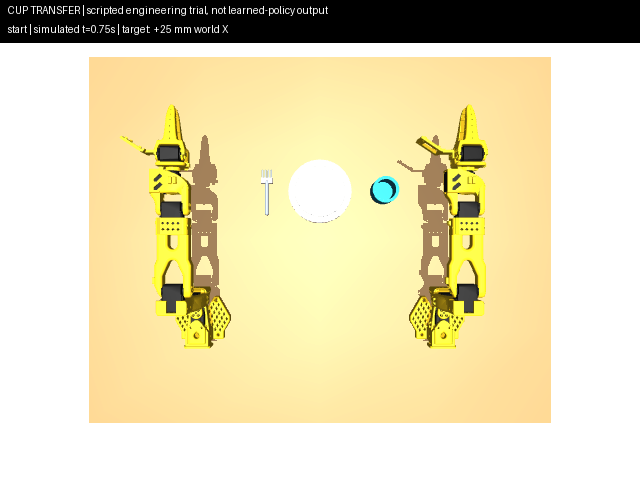


TRANSFERRED — actual recorded state


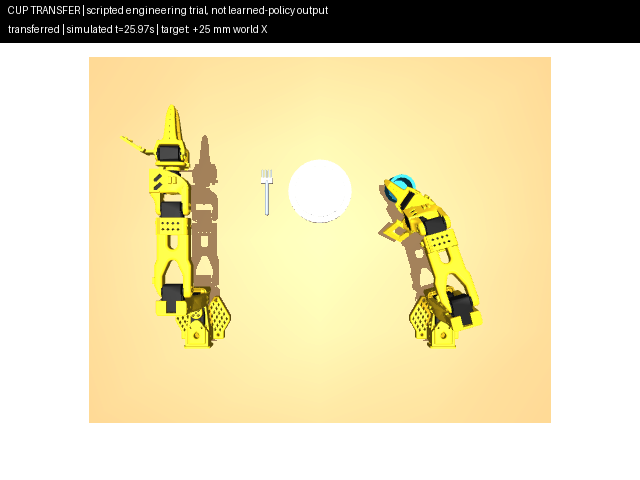


FINAL — actual recorded state


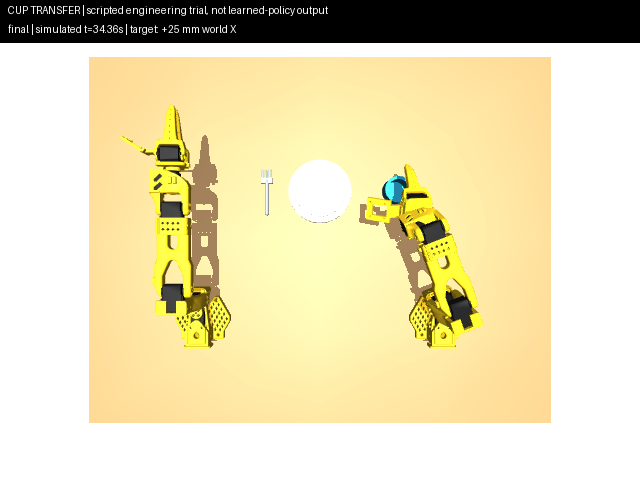


Share: C:\Users\Fiza\Downloads\TableGuard_Phase1_Python_Starter\TableGuard_Starter\artifacts\cup_transfer_07c\20260913T025459Z_3185ba\transfer_report.json
Engineering simulator-state feedback only; not camera/VLA recovery or full table-setting.


In [2]:
# First use: one fresh corrected trial. Later uses: view that saved attempt.
ROOT = Path(
    r"C:\Users\Fiza\Downloads"
    r"\TableGuard_Phase1_Python_Starter\TableGuard_Starter"
)
SOURCE_RUN_NAME = "20260912T235941Z_recording_0cd563"
MODE = "run_once_or_view"
RECORD_DATA = True
START_NEW_TRIAL = False

RESULT = run_07c(
    ROOT, SOURCE_RUN_NAME, mode=MODE,
    record_data=RECORD_DATA, start_new_trial=START_NEW_TRIAL,
)


## Outputs and interpretation
`transfer_report.json` contains the actual pass flags, `stop_diagnostics`, maximum observed cup tilt,
`tilt_by_phase`, cup-axis planning evidence, placement measurements and recording status.
`grasp_trace.csv` keeps the inherited numerical fields plus cup-up and cup/gripper-relative-change diagnostics.
Those extra fields are evaluator/engineering data, not added to camera-policy observation inputs.
`cup_pose_plan_*.json` describes predictions only. A predicted low tilt does not prove a stable physical grasp.

**The 25-degree planning ceiling is not a guarantee** between sampled configurations or under contact dynamics.
If the runtime still stops, preserve `transfer_report.json` and `grasp_trace.csv`. Do not increase the tilt
limit, relax the destination tolerance, or count partial recordings as successful demonstrations.

## Validation boundary
In this preparation environment: unchanged base 56 tests passed, original transfer 30 tests passed,
07B object-target tests 45 passed, and 32 new synthetic cup-axis tests passed. The new tests exercise
transform geometry, analytical Jacobians, preservation of execution state, predicted-tilt rejection,
contact-check propagation and inherited guard preservation. They do **not** execute SO-101 contact physics.
MuJoCo is not installed in the preparation container; an installation attempt returned no available package.
Ten workflow tests also passed, including read-only viewing, log/CSV inspection, source integrity,
and run-once behavior with an explicitly mocked robot worker. Actual physics and rendering are
checked only by your local run, not claimed here.

## Next handoff
Share `TRANSFER SUMMARY — 07C`, including `maximum_actual_cup_tilt_deg`, `transfer_measurements`,
`placement_measurements`, and `stop_diagnostics` if present. The complete task must still pass all gates.
